# Experimento final APR - Analisis exhaustivo de resultados

Notebook de exploracion y visualizacion para la base definitiva `results/experiment-aggregate-20260529T152606Z.db`. El foco no es solo contar cuantos tests pasan, sino separar la senal de validacion automatica de la correccion semantica estimada por el LLM judge.

## 1. Localizar artefactos previos y preguntas de validacion

Esta primera celda mira alrededor del repositorio antes de analizar datos: notebook de referencia, capitulo de experimentacion, README de la memoria, scripts de generacion/ejecucion y artefactos de validacion. La idea es que el analisis quede alineado con la narrativa pendiente de la memoria: comparar arquitecturas y modelos, distinguir tests de correccion semantica y documentar los casos en los que el judge aporta informacion adicional.

In [1]:
from pathlib import Path
import re

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

paths = {
    'db_final': REPO_ROOT / 'results' / 'experiment-aggregate-20260529T152606Z.db',
    'notebook_referencia': REPO_ROOT / 'notebooks' / 'quixbugs-analysis.ipynb',
    'memoria_readme': REPO_ROOT / 'memoria' / 'README.md',
    'capitulo_7': REPO_ROOT / 'memoria' / 'sections' / '07-experimentacion' / '07-experimentacion.tex',
    'script_batches': REPO_ROOT / 'scripts' / 'generate_experiment_batches.py',
    'script_ejecucion': REPO_ROOT / 'scripts' / 'run_final_experiment.py',
    'script_aggregate': REPO_ROOT / 'scripts' / 'aggregate_experiment_results.py',
    'skill_validator': REPO_ROOT / '.agents' / 'skills' / 'apr-validator' / 'SKILL.md',
    'figures_dir': REPO_ROOT / 'memoria' / 'images',
    'analysis_dir': REPO_ROOT / 'notebooks' / 'exports' / 'final-experiment-analysis',
}
for p in [paths['figures_dir'], paths['analysis_dir']]:
    p.mkdir(parents=True, exist_ok=True)

artifact_rows = []
for name, path in paths.items():
    artifact_rows.append({
        'artifacto': name,
        'ruta': str(path.relative_to(REPO_ROOT)),
        'existe': path.exists(),
        'tamano_kb': round(path.stat().st_size / 1024, 1) if path.exists() and path.is_file() else None,
    })

import pandas as pd
from IPython.display import display
artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

memoria_text = paths['memoria_readme'].read_text(errors='replace') if paths['memoria_readme'].exists() else ''
cap7_text = paths['capitulo_7'].read_text(errors='replace') if paths['capitulo_7'].exists() else ''

pending = []
for label, text in [('README memoria', memoria_text), ('Capitulo 7', cap7_text)]:
    for line in text.splitlines():
        if 'TODO' in line or re.search(r'validaci[oó]n|judge|CORRECT|PLAUSIBLE|OVERFITTING|FAIL|RQ[12]', line, flags=re.I):
            clean = line.strip()
            if clean:
                pending.append({'fuente': label, 'pista_narrativa': clean[:240]})

pending_df = pd.DataFrame(pending)
display(pending_df.head(35))
print(f'Pistas encontradas: {len(pending_df)}')

,artifacto,ruta,existe,tamano_kb
0,db_final,results/experiment-aggregate-20260529T152606Z.db,True,20676.0
1,notebook_referencia,notebooks/quixbugs-analysis.ipynb,True,1506.1
2,memoria_readme,memoria/README.md,True,12.5
3,capitulo_7,memoria/sections/07-experimentacion/07-experim...,True,46.9
4,script_batches,scripts/generate_experiment_batches.py,True,16.9
5,script_ejecucion,scripts/run_final_experiment.py,True,34.7
6,script_aggregate,scripts/aggregate_experiment_results.py,True,18.4
7,skill_validator,.agents/skills/apr-validator/SKILL.md,True,13.2
8,figures_dir,memoria/images,True,NaN
9,analysis_dir,notebooks/exports/final-experiment-analysis,True,NaN


,fuente,pista_narrativa
0,README memoria,- [x] **§7 — BLEU no es una buena métrica** (E...
1,README memoria,- [x] **§6.4 y apéndice A — Validación semánti...
2,README memoria,- **Validación: pipeline y métricas**: la tasa...
3,README memoria,- `CORRECT`: tests pasan y el fix aborda la mi...
4,README memoria,- `PLAUSIBLE`: tests pasan pero el fix no cubr...
5,README memoria,- `OVERFITTING`: tests pasan pero el agente aj...
6,README memoria,- `FAIL`: ejecución que no pasa tests. No es u...
7,README memoria,- **Para la memoria**: explicar el protocolo d...
8,README memoria,Sí existen trabajos recientes con LLMs sobre B...
9,README memoria,- 2.1.3 El problema de los parches plausibles


Pistas encontradas: 126


## 2. Configurar entorno, rutas y estilo visual

Se centraliza la configuracion visual y se dejan funciones pequenas para guardar figuras con nombres estables. El notebook funciona sin Plotly ni SciPy: si Plotly esta disponible se registra, pero las visualizaciones principales usan Matplotlib y Seaborn para mantener el entorno ligero.

In [2]:
import sqlite3
import json
import math
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 180)

try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception:
    px = None
    PLOTLY_AVAILABLE = False

DB_PATH = paths['db_final']
FIGURES_DIR = paths['figures_dir']
EXPORT_DIR = paths['analysis_dir']
assert DB_PATH.exists(), f'No existe la base de datos: {DB_PATH}'

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 140,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
    'axes.titleweight': 'bold',
})

ARCH_ORDER = ['mono_agent', 'multi_agent_orchestrator', 'planner_executor']
ARCH_LABELS = {
    'mono_agent': 'Mono-agent',
    'multi_agent_orchestrator': 'Orchestrator',
    'planner_executor': 'Planner-Executor',
}
ARCH_COLORS = {
    'mono_agent': '#4C78A8',
    'multi_agent_orchestrator': '#F58518',
    'planner_executor': '#54A24B',
}
MODEL_ORDER = ['gemma4-26b-ctx32k', 'qwen3.5-9b-ctx65k', 'gpt-5.4-mini']
MODEL_LABELS = {
    'gemma4-26b-ctx32k': 'Gemma4 26B',
    'qwen3.5-9b-ctx65k': 'Qwen3.5 9B',
    'gpt-5.4-mini': 'GPT-5.4 mini',
}
DATASET_LABELS = {'quixbugs-python': 'QuixBugs', 'bugsinpy-full': 'BugsInPy'}
SEMANTIC_VERDICT_ORDER = ['CORRECT', 'PLAUSIBLE', 'OVERFITTING']
VERDICT_ORDER = ['CORRECT', 'PLAUSIBLE', 'OVERFITTING', 'FAIL', 'SIN_VEREDICTO']
VERDICT_COLORS = {
    'CORRECT': '#2CA02C',
    'PLAUSIBLE': '#1F77B4',
    'OVERFITTING': '#FF7F0E',
    'FAIL': '#8C8C8C',
    'SIN_VEREDICTO': '#D9D9D9',
}

saved_figures = []

def savefig(name, fig=None, formats=('pdf', 'png')):
    fig = fig or plt.gcf()
    saved = []
    for fmt in formats:
        out = FIGURES_DIR / f'{name}.{fmt}'
        fig.savefig(out, dpi=180, bbox_inches='tight')
        saved.append(str(out.relative_to(REPO_ROOT)))
    saved_figures.append({'name': name, 'files': saved})
    return saved

def pct(numer, denom):
    return 100 * numer / denom if denom else np.nan

def wilson_interval(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = successes / n
    denom = 1 + z * z / n
    center = (phat + z * z / (2 * n)) / denom
    half = z * math.sqrt((phat * (1 - phat) + z * z / (4 * n)) / n) / denom
    return (100 * (center - half), 100 * (center + half))

def bootstrap_rate_ci(values, n_boot=3000, seed=7):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(arr), size=(n_boot, len(arr)))
    boots = arr[idx].mean(axis=1) * 100
    return tuple(np.percentile(boots, [2.5, 97.5]))

print(f'DB: {DB_PATH.relative_to(REPO_ROOT)} ({DB_PATH.stat().st_size / 1024 / 1024:.1f} MB)')
print(f'Plotly disponible: {PLOTLY_AVAILABLE}')
print(f'Figuras -> {FIGURES_DIR.relative_to(REPO_ROOT)}')

DB: results/experiment-aggregate-20260529T152606Z.db (20.2 MB)
Plotly disponible: False
Figuras -> memoria/images


## 3. Inspeccionar esquema de la base de datos definitiva

Antes de unir tablas se revisa el esquema real. Esto evita asumir que el modelo, la arquitectura o el veredicto estan en una columna directa cuando en realidad aparecen repartidos entre `runs`, `run_agents`, `model_configs` y `run_validations`.

In [3]:
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn, params=params or {})

with sqlite3.connect(DB_PATH) as conn:
    table_rows = conn.execute("SELECT name, type FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY type, name").fetchall()
    schema_rows = []
    for name, kind in table_rows:
        count = conn.execute(f'SELECT COUNT(*) FROM {name}').fetchone()[0] if kind == 'table' else None
        for col in conn.execute(f'PRAGMA table_info({name})').fetchall():
            schema_rows.append({'tabla': name, 'tipo': kind, 'filas': count, 'columna': col[1], 'sql_type': col[2]})

schema_df = pd.DataFrame(schema_rows)
table_sizes = schema_df[['tabla', 'tipo', 'filas']].drop_duplicates().sort_values(['tipo', 'tabla'])
display(table_sizes)
display(schema_df.groupby('tabla')['columna'].apply(list).reset_index())

preview_tables = ['runs', 'run_validations', 'iterations', 'tool_calls', 'test_executions', 'run_agents', 'model_configs']
for table in preview_tables:
    print(f'\n--- {table} ---')
    display(query(f'SELECT * FROM {table} LIMIT 3'))

,tabla,tipo,filas
0,agent_executions,table,1656
18,agent_handoffs,table,0
27,architectures,table,3
30,file_changes,table,1909
40,iterations,table,1656
57,model_configs,table,3
64,provider_call_events,table,44
78,run_agents,table,1111
86,run_validations,table,833
97,runs,table,833


,tabla,columna
0,agent_executions,"[agent_execution_id, run_id, iteration_id, run_agent_id, execution_index, started_at, finished_at, duration_seconds, status, reasoning_s..."
1,agent_handoffs,"[handoff_id, run_id, iteration_id, from_agent_name, to_agent_name, from_run_agent_id, to_run_agent_id, occurred_at, handoff_note_json]"
2,architectures,"[architecture_id, name, description]"
3,file_changes,"[file_change_id, run_id, iteration_id, agent_execution_id, tool_call_id, path, change_type, additions, deletions, detected_by]"
4,iterations,"[iteration_id, run_id, iteration_index, started_at, finished_at, duration_seconds, status, stop_reason, repo_changed, changed_files_coun..."
5,model_configs,"[model_config_id, provider, model, base_url, max_turns, tracing_disabled, extra_json]"
6,provider_call_events,"[provider_call_id, run_id, iteration_id, agent_execution_id, event_type, attempt, total_attempts, status_code, error_type, error_message..."
7,run_agents,"[run_agent_id, run_id, agent_name, agent_role, agent_order, model_config_id, instructions_hash, tool_profile]"
8,run_validations,"[validation_id, run_id, validated_at, validator_model, test_passed, infra_fail_detected, canonical_patch_available, patch_semantically_m..."
9,runs,"[run_id, architecture_id, started_at, finished_at, target_repo, target_branch, benchmark_name, problem_id, prompt_hash, run_fingerprint,..."



--- runs ---


,run_id,architecture_id,started_at,finished_at,target_repo,target_branch,benchmark_name,problem_id,prompt_hash,run_fingerprint,final_status,stop_reason,resolved,duration_seconds,total_iterations,total_input_tokens,total_output_tokens,total_tokens,files_changed_count,live_log_path,summary_path,diff_path,error_type,error_message,error_category,error_traceback,batch_id
0,run-20260524T081242Z-1cfc58d72b,arch-0ac4ac85a7e0aa58,2026-05-24T08:12:42.941912+00:00,2026-05-24T08:14:40.423912+00:00,/benchmark-workspaces/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-1/PySnooper,None,bugsinpy-full,PySnooper-1,e3b0c44298fc1c14,f74b4c2e3d8f7958,success,completed,1,117.476570,1,124279,13257,137536,1,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-1-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-1-mono_agent-gemma4-26b-ctx32k/summary.json,None,None,None,None,None,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z
1,run-20260524T081450Z-d55819028e,arch-0ac4ac85a7e0aa58,2026-05-24T08:14:50.621040+00:00,2026-05-24T08:33:59.897563+00:00,/benchmark-workspaces/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-2/PySnooper,None,bugsinpy-full,PySnooper-2,e3b0c44298fc1c14,e8b9dd9b896db82e,failed,max_iterations,0,1149.270151,3,542561,135687,678248,0,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-2-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-2-mono_agent-gemma4-26b-ctx32k/summary.json,None,None,None,None,None,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z
2,run-20260524T083411Z-fe631066ac,arch-0ac4ac85a7e0aa58,2026-05-24T08:34:11.982897+00:00,2026-05-24T08:35:12.339507+00:00,/benchmark-workspaces/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-3/PySnooper,None,bugsinpy-full,PySnooper-3,e3b0c44298fc1c14,60c76e749b347d35,success,completed,1,60.304823,1,107553,5434,112987,1,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-3-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-3-mono_agent-gemma4-26b-ctx32k/summary.json,None,None,None,None,None,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z



--- run_validations ---


...

,test_execution_id,run_id,iteration_id,agent_execution_id,tool_call_id,phase,command,duration_seconds,exit_code,timed_out,signature
0,run-20260524T081242Z-1cfc58d72b-baseline-test,run-20260524T081242Z-1cfc58d72b,NaN,NaN,None,baseline,test -x env/bin/python && test -f bugsinpy_run_test.sh && test -f bugsinpy_compile_flag || exit 2; env/bin/pip install -e . --no-deps -q...,None,4,0,0d4b931fd79d5124
1,run-20260524T081242Z-1cfc58d72b-it01-validation-test,run-20260524T081242Z-1cfc58d72b,run-20260524T081242Z-1cfc58d72b-it01,run-20260524T081242Z-1cfc58d72b-it01-agent01,None,iteration_validation,test -x env/bin/python && test -f bugsinpy_run_test.sh && test -f bugsinpy_compile_flag || exit 2; env/bin/pip install -e . --no-deps -q...,None,0,0,ac5c4ee5b05aa8ee
2,run-20260524T081450Z-d55819028e-baseline-test,run-20260524T081450Z-d55819028e,NaN,NaN,None,baseline,test -x env/bin/python && test -f bugsinpy_run_test.sh && test -f bugsinpy_compile_flag || exit 2; env/bin/pip install -e . --no-deps -q...,None,4,0,0da0b5f8b1b8b642



--- run_agents ---


,run_agent_id,run_id,agent_name,agent_role,agent_order,model_config_id,instructions_hash,tool_profile
0,ra-76815ea34edc3b1f,run-20260524T081242Z-1cfc58d72b,baseline,fixer,1,model-ab1ed5d0bb147c36,75d5dfca0022626f,full
1,ra-df7f15ed4f2e8be4,run-20260524T081450Z-d55819028e,baseline,fixer,1,model-ab1ed5d0bb147c36,75d5dfca0022626f,full
2,ra-207ea5fae9161614,run-20260524T083411Z-fe631066ac,baseline,fixer,1,model-ab1ed5d0bb147c36,75d5dfca0022626f,full



--- model_configs ---


,model_config_id,provider,model,base_url,max_turns,tracing_disabled,extra_json
0,model-ab1ed5d0bb147c36,ollama,gemma4-26b-ctx32k,http://host.docker.internal:11500/v1,30,1,{}
1,model-1992a167de2d8662,openai,gpt-5.4-mini,https://api.openai.com/v1,15,1,{}
2,model-0f5fc3b0c59ff97a,ollama,qwen3.5-9b-ctx65k,http://host.docker.internal:11500/v1,30,1,{}


## 4. Cargar resultados agregados desde SQLite

La vista principal se construye desde `runs` y se enriquece con arquitectura, modelo primario, veredicto del judge, iteraciones, herramientas, tests y cambios de ficheros. Se conserva `run_id` y `batch_id` para poder volver a los artefactos originales.

In [4]:
runs = query('''

WITH primary_model AS (

    SELECT ra.run_id, mc.provider, mc.model, mc.max_turns, mc.extra_json

    FROM run_agents ra

    JOIN model_configs mc ON mc.model_config_id = ra.model_config_id

    WHERE ra.agent_order = 1

)

SELECT

    r.*,

    a.name AS architecture,

    pm.provider,

    pm.model,

    pm.max_turns,

    pm.extra_json,

    rv.validated_at,

    rv.validator_model,

    rv.test_passed AS judge_test_passed,

    rv.canonical_patch_available,

    rv.patch_semantically_matches,

    rv.verdict,

    rv.confidence,

    rv.justification

FROM runs r

JOIN architectures a ON a.architecture_id = r.architecture_id

LEFT JOIN primary_model pm ON pm.run_id = r.run_id

LEFT JOIN run_validations rv ON rv.run_id = r.run_id

''')



db_runs_count = len(runs)

if 'synthetic_failure_added' not in runs.columns:

    runs['synthetic_failure_added'] = False



def load_summary_only_failures(repo_root):

    records = []

    for summary_path in sorted((repo_root / 'results').glob('batch-experiment-*/summary.json')):

        payload = json.loads(summary_path.read_text())

        batch_id = summary_path.parent.name

        summary_rel = '/' + str(summary_path.relative_to(repo_root)).replace('\\', '/')

        for item in payload.get('results', []):

            if item.get('status') != 'infra_failure' or item.get('run_id'):

                continue

            records.append({

                'run_id': f"synthetic-{batch_id}-{item['bug_id']}",

                'architecture_id': pd.NA,

                'started_at': pd.NaT,

                'finished_at': pd.NaT,

                'target_repo': pd.NA,

                'target_branch': pd.NA,

                'benchmark_name': payload.get('dataset_name'),

                'problem_id': item.get('bug_id'),

                'prompt_hash': pd.NA,

                'run_fingerprint': pd.NA,

                'final_status': 'failed',

                'stop_reason': 'failed',

                'resolved': 0,

                'duration_seconds': pd.NA,

                'total_iterations': pd.NA,

                'total_input_tokens': pd.NA,

                'total_output_tokens': pd.NA,

                'total_tokens': pd.NA,

                'files_changed_count': pd.NA,

                'live_log_path': pd.NA,

                'summary_path': summary_rel,

                'diff_path': pd.NA,

                'error_type': pd.NA,

                'error_message': pd.NA,

                'error_category': pd.NA,

                'error_traceback': pd.NA,

                'batch_id': batch_id,

                'architecture': payload.get('architecture'),

                'provider': payload.get('provider'),

                'model': payload.get('model'),

                'max_turns': pd.NA,

                'extra_json': pd.NA,

                'validated_at': pd.NaT,

                'validator_model': pd.NA,

                'judge_test_passed': False,

                'canonical_patch_available': pd.NA,

                'patch_semantically_matches': pd.NA,

                'verdict': pd.NA,

                'confidence': pd.NA,

                'justification': pd.NA,

                'synthetic_failure_added': True,

            })

    return pd.DataFrame.from_records(records)



summary_only_failures = load_summary_only_failures(REPO_ROOT)

synthetic_failures_added = 0

if not summary_only_failures.empty:

    key_cols = ['benchmark_name', 'problem_id', 'architecture', 'model']

    existing_keys = runs[key_cols].astype(str).drop_duplicates()

    summary_only_failures = summary_only_failures.merge(existing_keys.assign(_present=True), on=key_cols, how='left')

    summary_only_failures = summary_only_failures[summary_only_failures['_present'] != True].drop(columns=['_present'])

    if not summary_only_failures.empty:

        for col in runs.columns:

            if col not in summary_only_failures.columns:

                summary_only_failures[col] = pd.NA

        summary_only_failures = summary_only_failures[runs.columns]

        synthetic_failures_added = len(summary_only_failures)

        runs = pd.concat([runs, summary_only_failures], ignore_index=True, sort=False)



iterations = query('''

SELECT i.*, r.benchmark_name, r.problem_id, a.name AS architecture

FROM iterations i

JOIN runs r ON r.run_id = i.run_id

JOIN architectures a ON a.architecture_id = r.architecture_id

''')



tool_calls = query('''

SELECT tc.*, r.benchmark_name, r.problem_id, a.name AS architecture

FROM tool_calls tc

JOIN runs r ON r.run_id = tc.run_id

JOIN architectures a ON a.architecture_id = r.architecture_id

''')



test_executions = query('''

SELECT te.*, r.benchmark_name, r.problem_id, a.name AS architecture

FROM test_executions te

JOIN runs r ON r.run_id = te.run_id

JOIN architectures a ON a.architecture_id = r.architecture_id

''')



file_changes = query('''

SELECT fc.*, r.benchmark_name, r.problem_id, a.name AS architecture

FROM file_changes fc

JOIN runs r ON r.run_id = fc.run_id

JOIN architectures a ON a.architecture_id = r.architecture_id

''')



print(f'runs_db={db_runs_count:,}  synthetic_failures_added={synthetic_failures_added:,}  runs_total={len(runs):,}  iterations={len(iterations):,}  tool_calls={len(tool_calls):,}  tests={len(test_executions):,}  file_changes={len(file_changes):,}')

display(runs[['run_id', 'benchmark_name', 'problem_id', 'architecture', 'model', 'final_status', 'resolved', 'verdict', 'confidence', 'batch_id']].head())

runs_db=833  synthetic_failures_added=4  runs_total=837  iterations=1,656  tool_calls=21,762  tests=2,426  file_changes=1,909


,run_id,benchmark_name,problem_id,architecture,model,final_status,resolved,verdict,confidence,batch_id
0,run-20260524T081242Z-1cfc58d72b,bugsinpy-full,PySnooper-1,mono_agent,gemma4-26b-ctx32k,success,1,PLAUSIBLE,0.75,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z
1,run-20260524T081450Z-d55819028e,bugsinpy-full,PySnooper-2,mono_agent,gemma4-26b-ctx32k,failed,0,FAIL,NaN,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z
2,run-20260524T083411Z-fe631066ac,bugsinpy-full,PySnooper-3,mono_agent,gemma4-26b-ctx32k,success,1,CORRECT,0.95,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z
3,run-20260524T091442Z-46cc4e69e2,bugsinpy-full,ansible-1,mono_agent,gemma4-26b-ctx32k,failed,0,FAIL,NaN,batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z
4,run-20260524T092920Z-956043f1c1,bugsinpy-full,ansible-3,mono_agent,gemma4-26b-ctx32k,failed,0,FAIL,NaN,batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z


## 5. Normalizar columnas, tipos y etiquetas experimentales



Aqui se fijan los denominadores que se usaran en todo el notebook. La regla mas importante es no tratar `PLAUSIBLE` como `CORRECT`: los tests superados miden plausibilidad APR, mientras que `CORRECT` mide correccion semantica segun el judge. Los intentos que no pasan tests se etiquetan como `FAIL` porque el agente reparador no resolvio el problema. Para las metricas finales se usa el conjunto experimental completo y solo se dejan fuera posibles errores del proceso de validacion semantica.


In [5]:
def project_from_problem(row):

    problem = str(row['problem_id'])

    if row['benchmark_name'] == 'bugsinpy-full' and '-' in problem:

        return problem.rsplit('-', 1)[0]

    return 'QuixBugs'



def ordered_category(series, order):

    return pd.Categorical(series, categories=order, ordered=True)



NORMALIZED_FAILURE_RUN_IDS = {

    'run-20260526T203323Z-4e23c776eb',

    'run-20260526T184245Z-6b2d481824',

    'run-20260526T204907Z-0831588cb2',

    'run-20260525T161859Z-b5f981c25d',

    'run-20260526T230228Z-495d252c71',

    'run-20260525T171820Z-93c0c1cf75',

    'run-20260524T171627Z-3734a482f6',

}



if 'error_category' not in runs:

    runs['error_category'] = pd.NA

if 'verdict' not in runs:

    runs['verdict'] = pd.NA

if 'synthetic_failure_added' not in runs:

    runs['synthetic_failure_added'] = False



for col in ['started_at', 'finished_at', 'validated_at']:

    if col in runs:

        runs[col] = pd.to_datetime(runs[col], errors='coerce', utc=True)



numeric_cols = ['resolved', 'duration_seconds', 'total_iterations', 'total_input_tokens', 'total_output_tokens', 'total_tokens', 'files_changed_count', 'confidence']

for col in numeric_cols:

    runs[col] = pd.to_numeric(runs[col], errors='coerce')



# Casos puntuales ya auditados: se cuentan como fallos normales en el analisis.

normalized_failure_mask = runs['run_id'].isin(NORMALIZED_FAILURE_RUN_IDS) | runs['synthetic_failure_added'].fillna(False)

runs.loc[normalized_failure_mask, 'final_status'] = 'failed'

runs.loc[normalized_failure_mask, 'stop_reason'] = 'failed'

runs.loc[normalized_failure_mask, 'error_type'] = pd.NA

runs.loc[normalized_failure_mask, 'error_category'] = pd.NA

runs.loc[normalized_failure_mask, 'error_message'] = pd.NA

runs.loc[normalized_failure_mask, 'error_traceback'] = pd.NA



runs['dataset_label'] = runs['benchmark_name'].map(DATASET_LABELS).fillna(runs['benchmark_name'])

runs['arch_label'] = runs['architecture'].map(ARCH_LABELS).fillna(runs['architecture'])

runs['model_label'] = runs['model'].map(MODEL_LABELS).fillna(runs['model'])

runs['project'] = runs.apply(project_from_problem, axis=1)

runs['config'] = runs['model_label'] + ' / ' + runs['arch_label']

runs['tests_pass'] = runs['resolved'].fillna(0).astype(int).eq(1)

runs['has_judge_verdict'] = runs['verdict'].notna()

runs['verdict_clean'] = runs['verdict'].fillna('SIN_VEREDICTO')

runs.loc[~runs['tests_pass'], 'verdict_clean'] = 'FAIL'

runs['judge_correct'] = runs['verdict_clean'].eq('CORRECT') & runs['tests_pass']

runs['judge_plausible'] = runs['verdict_clean'].eq('PLAUSIBLE') & runs['tests_pass']

runs['judge_overfitting'] = runs['verdict_clean'].eq('OVERFITTING') & runs['tests_pass']

runs['repair_failed'] = runs['verdict_clean'].eq('FAIL')

runs['judge_accepted_semantic'] = runs['verdict_clean'].isin(['CORRECT', 'PLAUSIBLE']) & runs['tests_pass']

runs['valid_semantic_verdict'] = runs['verdict_clean'].isin(SEMANTIC_VERDICT_ORDER) & runs['tests_pass']

legacy_semantic_validation_errors = {'VALIDATION_' + 'ERROR', 'INFRA_' + 'FAIL'}

runs['semantic_validation_process_error'] = (

    runs['verdict'].astype(str).isin(legacy_semantic_validation_errors)

    | (runs['tests_pass'] & ~runs['verdict_clean'].astype(str).isin(SEMANTIC_VERDICT_ORDER))

)

runs['analysis_scope'] = ~runs['semantic_validation_process_error']

runs['semantic_gap'] = runs['tests_pass'].astype(int) - runs['judge_correct'].astype(int)

runs['tokens_k'] = runs['total_tokens'] / 1000

runs['input_tokens_k'] = runs['total_input_tokens'] / 1000

runs['output_tokens_k'] = runs['total_output_tokens'] / 1000

runs['duration_min'] = runs['duration_seconds'] / 60

runs['architecture'] = ordered_category(runs['architecture'], ARCH_ORDER)

runs['model'] = ordered_category(runs['model'], MODEL_ORDER)

runs['verdict_clean'] = ordered_category(runs['verdict_clean'], VERDICT_ORDER)



analysis_runs = runs[runs['analysis_scope']].copy()

verdict_consistency = pd.crosstab(analysis_runs['tests_pass'].map({False: 'tests_fail', True: 'tests_pass'}), analysis_runs['verdict_clean'].astype(str))

scope_summary = runs.groupby(['analysis_scope', 'semantic_validation_process_error'], dropna=False).size().reset_index(name='runs')



for frame in [iterations, tool_calls, test_executions, file_changes]:

    if 'benchmark_name' in frame:

        frame['dataset_label'] = frame['benchmark_name'].map(DATASET_LABELS).fillna(frame['benchmark_name'])

    if 'architecture' in frame:

        frame['arch_label'] = frame['architecture'].map(ARCH_LABELS).fillna(frame['architecture'])



print('Datasets:', analysis_runs['dataset_label'].value_counts().to_dict())

print('Modelos:', analysis_runs['model_label'].value_counts().to_dict())

print('Arquitecturas:', analysis_runs['arch_label'].value_counts().to_dict())

print('Veredictos normalizados en el analisis:', analysis_runs['verdict_clean'].astype(str).value_counts().to_dict())

print(f'Runs en DB agregada: {db_runs_count:,}; runs sinteticos añadidos desde summaries: {synthetic_failures_added:,}')

print(f'Runs considerados en el analisis: {len(analysis_runs):,}')

display(scope_summary)

display(verdict_consistency)

Datasets: {'BugsInPy': 477, 'QuixBugs': 360}
Modelos: {'Gemma4 26B': 279, 'GPT-5.4 mini': 279, 'Qwen3.5 9B': 279}
Arquitecturas: {'Mono-agent': 279, 'Orchestrator': 279, 'Planner-Executor': 279}
Veredictos normalizados en el analisis: {'CORRECT': 360, 'FAIL': 287, 'PLAUSIBLE': 179, 'OVERFITTING': 11}
Runs en DB agregada: 833; runs sinteticos añadidos desde summaries: 4
Runs considerados en el analisis: 837


,analysis_scope,semantic_validation_process_error,runs
0,True,False,837


verdict_clean,CORRECT,FAIL,OVERFITTING,PLAUSIBLE
tests_pass,,,,
tests_fail,0,287,0,0
tests_pass,360,0,11,179


## 6. Auditar calidad, completitud y duplicados



La base final se audita antes de calcular metricas. Esta seccion no borra datos: marca el subconjunto usado en las figuras y deja fuera solo incidencias del proceso de validacion semantica.


Duplicados exactos por unidad experimental: 0
Celdas esperadas: 837; observadas: 837; ausentes: 0


,dataset_label,problem_id,model_label,arch_label


,dataset_label,tests_pass,has_judge_verdict,runs
0,BugsInPy,False,False,4
1,BugsInPy,False,True,263
2,BugsInPy,True,True,210
3,QuixBugs,False,True,20
4,QuixBugs,True,True,340


,columna,pct_null
0,target_branch,100.0
1,diff_path,99.6
2,error_traceback,99.6
3,error_type,97.1
4,error_message,97.1
5,error_category,97.1
6,patch_semantically_matches,38.8
7,confidence,34.3
8,canonical_patch_available,26.9
9,duration_seconds,0.5


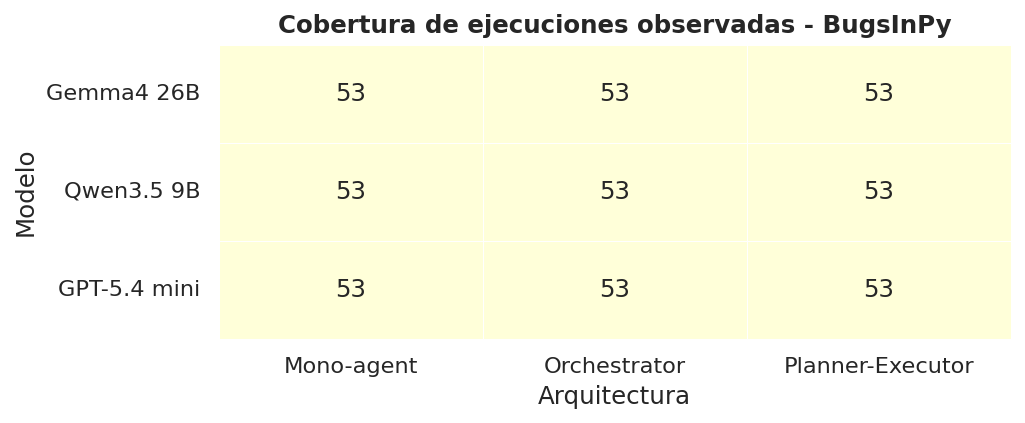

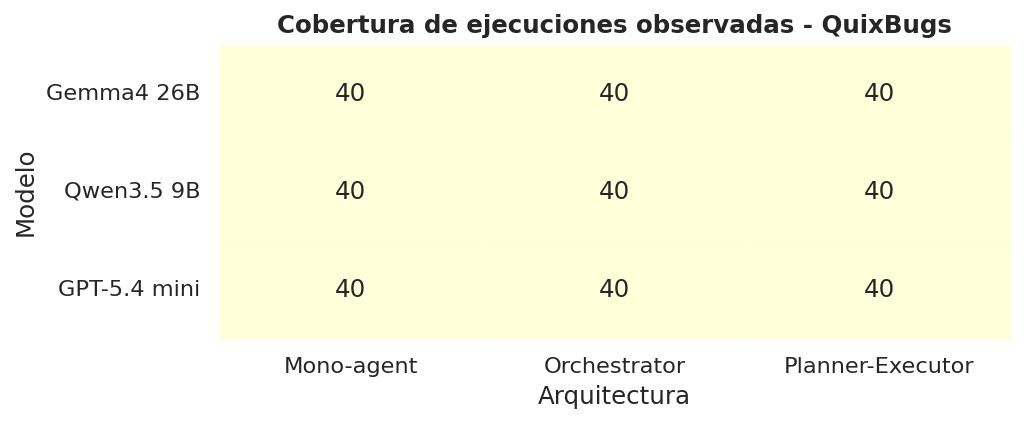

In [6]:
duplicate_cols = ['benchmark_name', 'problem_id', 'architecture', 'model']
duplicates = runs[runs.duplicated(duplicate_cols, keep=False)].sort_values(duplicate_cols)

observed = runs[duplicate_cols].drop_duplicates()
problems = runs[['benchmark_name', 'problem_id']].drop_duplicates()
combos = runs[['architecture', 'model']].drop_duplicates()
expected = problems.merge(combos, how='cross')
coverage = expected.merge(observed.assign(observed=1), on=duplicate_cols, how='left')
coverage['observed'] = coverage['observed'].fillna(0).astype(int)
missing_cells = coverage[coverage['observed'].eq(0)].copy()
missing_cells['dataset_label'] = missing_cells['benchmark_name'].map(DATASET_LABELS)
missing_cells['arch_label'] = missing_cells['architecture'].astype(str).map(ARCH_LABELS)
missing_cells['model_label'] = missing_cells['model'].astype(str).map(MODEL_LABELS)

null_summary = runs.isna().mean().sort_values(ascending=False).head(20).mul(100).round(1).reset_index()
null_summary.columns = ['columna', 'pct_null']

validation_scope = runs.groupby(['dataset_label', 'tests_pass', 'has_judge_verdict'], observed=True).size().reset_index(name='runs')
print(f'Duplicados exactos por unidad experimental: {len(duplicates)}')
print(f'Celdas esperadas: {len(expected):,}; observadas: {coverage["observed"].sum():,}; ausentes: {len(missing_cells)}')
display(missing_cells[['dataset_label', 'problem_id', 'model_label', 'arch_label']])
display(validation_scope)
display(null_summary)

coverage_matrix = runs.groupby(['dataset_label', 'model_label', 'arch_label'], observed=True).size().reset_index(name='runs')
for dataset, group in coverage_matrix.groupby('dataset_label'):
    pivot = group.pivot(index='model_label', columns='arch_label', values='runs').reindex(index=[MODEL_LABELS[m] for m in MODEL_ORDER], columns=[ARCH_LABELS[a] for a in ARCH_ORDER])
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, cbar=False, ax=ax)
    ax.set_title(f'Cobertura de ejecuciones observadas - {dataset}')
    ax.set_xlabel('Arquitectura')
    ax.set_ylabel('Modelo')
    plt.tight_layout()
    savefig(f'final_coverage_{dataset.lower()}')
    plt.show()

## 7. Reconstruir el flujo experimental desde batches y ejecucion

Esta vista conecta la base agregada con el plan experimental. Sirve para explicar en la memoria que los datos no salen de una tabla manual, sino de YAMLs generados, ejecuciones por batch, validacion formal y agregacion SQLite.

In [7]:
batch_summary = (
    analysis_runs.groupby(['batch_id', 'dataset_label', 'model_label', 'arch_label'], dropna=False, observed=True)
    .agg(
        runs=('run_id', 'count'),
        problems=('problem_id', 'nunique'),
        tests_passed=('tests_pass', 'sum'),
        correct=('judge_correct', 'sum'),
        started_min=('started_at', 'min'),
        finished_max=('finished_at', 'max'),
        tokens_k=('tokens_k', 'sum'),
    )
    .reset_index()
)
batch_summary['pass_rate'] = batch_summary.apply(lambda r: pct(r['tests_passed'], r['runs']), axis=1)
batch_summary['correct_rate'] = batch_summary.apply(lambda r: pct(r['correct'], r['runs']), axis=1)

script_notes = []
for key in ['script_batches', 'script_ejecucion', 'script_aggregate']:
    text = paths[key].read_text(errors='replace')
    first_doc = re.search(r'"""(.*?)"""', text, flags=re.S)
    script_notes.append({'script': paths[key].name, 'descripcion': (first_doc.group(1).strip().splitlines()[0] if first_doc else '')})

display(pd.DataFrame(script_notes))
display(batch_summary.sort_values(['dataset_label', 'model_label', 'arch_label']).head(20))
print('Batches agregados:', batch_summary['batch_id'].nunique())
print('Rango temporal:', runs['started_at'].min(), '->', runs['finished_at'].max())

,script,descripcion
0,generate_experiment_batches.py,Generate experiment batch YAMLs from the BugsInPy sampling strategy
1,run_final_experiment.py,run_final_experiment.py — Script definitivo de experimento + validación TFM.
2,aggregate_experiment_results.py,aggregate_experiment_results.py — Merge all experiment batch DBs into one.


,batch_id,dataset_label,model_label,arch_label,runs,problems,tests_passed,correct,started_min,finished_max,tokens_k,pass_rate,correct_rate
11,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-PySnooper-20260526T182432Z,BugsInPy,GPT-5.4 mini,Mono-agent,3,3,2,0,2026-05-26 18:24:51.031725+00:00,2026-05-26 18:30:35.610738+00:00,675.174,66.666667,0.000000
12,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-ansible-20260526T183038Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,4,0,2026-05-26 18:31:49.776733+00:00,2026-05-26 18:41:36.397479+00:00,1068.932,80.000000,0.000000
13,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-black-20260526T184139Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,0,0,2026-05-26 18:42:45.478445+00:00,2026-05-26 18:58:11.798376+00:00,1802.180,0.000000,0.000000
14,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-fastapi-20260526T185814Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,2,0,2026-05-26 18:59:30.990762+00:00,2026-05-26 19:18:40.397723+00:00,2060.794,40.000000,0.000000
15,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-httpie-20260526T191843Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,2,1,2026-05-26 19:19:09.749796+00:00,2026-05-26 19:27:57.357035+00:00,1463.206,40.000000,20.000000
16,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-luigi-20260526T192800Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,3,0,2026-05-26 19:29:44.794112+00:00,2026-05-26 19:42:25.655465+00:00,1497.097,60.000000,0.000000
17,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-scrapy-20260526T194228Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,0,0,2026-05-26 19:43:34.817052+00:00,2026-05-26 19:58:45.838483+00:00,2044.666,0.000000,0.000000
18,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-thefuck-20260526T195849Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,5,1,2026-05-26 19:59:31.380347+00:00,2026-05-26 20:07:50.641047+00:00,1099.663,100.000000,20.000000
19,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-tornado-20260526T200753Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,2,2,2026-05-26 20:08:23.058260+00:00,2026-05-26 20:17:17.533477+00:00,1351.675,40.000000,40.000000
20,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-tqdm-20260526T201719Z,BugsInPy,GPT-5.4 mini,Mono-agent,5,5,3,1,2026-05-26 20:17:50.797113+00:00,2026-05-26 20:24:25.407844+00:00,980.889,60.000000,20.000000


Batches agregados: 288
Rango temporal: 2026-05-24 08:12:42.941912+00:00 -> 2026-05-28 22:38:13.956501+00:00


## 8. Definir metricas principales de validacion

Las metricas se definen de forma explicita sobre el subconjunto limpio: `test_pass_rate` equivale a plausible rate clasica de APR, `correct_rate` cuenta solo `CORRECT` sobre todos los intentos validos y `semantic_precision_on_pass` mide que parte de los parches que pasan tests son semanticamente correctos.


In [8]:
def summarize(group_cols):
    df = (
        analysis_runs.groupby(group_cols, dropna=False, observed=True)
        .agg(
            runs=('run_id', 'count'),
            tests_passed=('tests_pass', 'sum'),
            judge_verdicts=('has_judge_verdict', 'sum'),
            correct=('judge_correct', 'sum'),
            plausible=('judge_plausible', 'sum'),
            overfitting=('judge_overfitting', 'sum'),
            failed_repairs=('repair_failed', 'sum'),
            valid_semantic=('valid_semantic_verdict', 'sum'),
            avg_tokens_k=('tokens_k', 'mean'),
            median_tokens_k=('tokens_k', 'median'),
            avg_seconds=('duration_seconds', 'mean'),
            avg_iterations=('total_iterations', 'mean'),
            avg_confidence=('confidence', 'mean'),
        )
        .reset_index()
    )
    df['test_pass_rate'] = df.apply(lambda r: pct(r['tests_passed'], r['runs']), axis=1)
    df['correct_rate'] = df.apply(lambda r: pct(r['correct'], r['runs']), axis=1)
    df['judge_accept_rate'] = df.apply(lambda r: pct(r['correct'] + r['plausible'], r['runs']), axis=1)
    df['overfit_rate'] = df.apply(lambda r: pct(r['overfitting'], r['runs']), axis=1)
    df['repair_failure_rate'] = df.apply(lambda r: pct(r['failed_repairs'], r['runs']), axis=1)
    df['semantic_precision_on_pass'] = df.apply(lambda r: pct(r['correct'], r['valid_semantic']), axis=1)
    df['semantic_gap_points'] = df['test_pass_rate'] - df['correct_rate']
    df['correct_per_million_tokens'] = df.apply(lambda r: r['correct'] / (r['avg_tokens_k'] * r['runs'] / 1000) if r['avg_tokens_k'] and r['runs'] else np.nan, axis=1)
    ci = df.apply(lambda r: wilson_interval(int(r['correct']), int(r['runs'])), axis=1)
    df['correct_ci_low'] = [x[0] for x in ci]
    df['correct_ci_high'] = [x[1] for x in ci]
    return df

summary_cfg = summarize(['dataset_label', 'benchmark_name', 'model_label', 'arch_label', 'model', 'architecture'])
summary_dataset = summarize(['dataset_label'])
summary_model = summarize(['dataset_label', 'model_label'])
summary_arch = summarize(['dataset_label', 'arch_label'])

display(summary_cfg.sort_values(['dataset_label', 'correct_rate'], ascending=[True, False]).round(2))

,dataset_label,benchmark_name,model_label,arch_label,model,architecture,runs,tests_passed,judge_verdicts,correct,plausible,overfitting,failed_repairs,valid_semantic,avg_tokens_k,median_tokens_k,avg_seconds,avg_iterations,avg_confidence,test_pass_rate,correct_rate,judge_accept_rate,overfit_rate,repair_failure_rate,semantic_precision_on_pass,semantic_gap_points,correct_per_million_tokens,correct_ci_low,correct_ci_high
1,BugsInPy,bugsinpy-full,GPT-5.4 mini,Orchestrator,gpt-5.4-mini,multi_agent_orchestrator,53,33,53,12,20,1,20,33,225.79,233.04,96.33,2.08,0.79,62.26,22.64,60.38,1.89,37.74,36.36,39.62,1.00,13.45,35.53
4,BugsInPy,bugsinpy-full,Gemma4 26B,Orchestrator,gemma4-26b-ctx32k,multi_agent_orchestrator,53,21,52,12,8,1,32,21,195.25,150.06,572.82,1.77,0.84,39.62,22.64,37.74,1.89,60.38,57.14,16.98,1.16,13.45,35.53
7,BugsInPy,bugsinpy-full,Qwen3.5 9B,Orchestrator,qwen3.5-9b-ctx65k,multi_agent_orchestrator,53,24,52,11,13,0,29,24,676.65,691.68,452.20,2.04,0.78,45.28,20.75,45.28,0.00,54.72,45.83,24.53,0.31,12.00,33.46
5,BugsInPy,bugsinpy-full,Gemma4 26B,Planner-Executor,gemma4-26b-ctx32k,planner_executor,53,21,52,10,10,1,32,21,270.20,208.10,459.29,2.42,0.82,39.62,18.87,37.74,1.89,60.38,47.62,20.75,0.70,10.59,31.36
6,BugsInPy,bugsinpy-full,Qwen3.5 9B,Mono-agent,qwen3.5-9b-ctx65k,mono_agent,53,29,53,8,21,0,24,29,686.17,588.51,334.92,1.98,0.75,54.72,15.09,54.72,0.00,45.28,27.59,39.62,0.22,7.85,27.05
3,BugsInPy,bugsinpy-full,Gemma4 26B,Mono-agent,gemma4-26b-ctx32k,mono_agent,53,18,53,6,11,1,35,18,196.21,148.82,554.36,2.11,0.81,33.96,11.32,32.08,1.89,66.04,33.33,22.64,0.58,5.29,22.58
8,BugsInPy,bugsinpy-full,Qwen3.5 9B,Planner-Executor,qwen3.5-9b-ctx65k,planner_executor,53,18,53,6,11,1,35,18,706.93,678.21,497.59,2.53,0.78,33.96,11.32,32.08,1.89,66.04,33.33,22.64,0.16,5.29,22.58
0,BugsInPy,bugsinpy-full,GPT-5.4 mini,Mono-agent,gpt-5.4-mini,mono_agent,53,26,52,5,20,1,27,26,289.97,287.42,92.48,2.10,0.76,49.06,9.43,47.17,1.89,50.94,19.23,39.62,0.33,4.10,20.25
2,BugsInPy,bugsinpy-full,GPT-5.4 mini,Planner-Executor,gpt-5.4-mini,planner_executor,53,20,53,4,11,5,33,20,215.72,199.49,84.57,2.66,0.79,37.74,7.55,28.30,9.43,62.26,20.00,30.19,0.35,2.97,17.86
10,QuixBugs,quixbugs-python,GPT-5.4 mini,Orchestrator,gpt-5.4-mini,multi_agent_orchestrator,40,40,40,40,0,0,0,40,25.70,24.64,30.51,1.00,0.93,100.00,100.00,100.00,0.00,0.00,100.00,0.00,38.91,91.24,100.00


## 9. Crear vista analitica por intento, problema y configuracion

`analysis_df` es la tabla maestra del notebook. Cada fila representa un intento experimental dentro del subconjunto limpio y contiene las columnas necesarias para graficas, tablas de casos y exportacion reproducible.


In [9]:
analysis_cols = [
    'run_id', 'batch_id', 'dataset_label', 'benchmark_name', 'project', 'problem_id',
    'model_label', 'arch_label', 'config', 'final_status', 'stop_reason', 'tests_pass',
    'verdict_clean', 'judge_correct', 'judge_plausible', 'judge_overfitting', 'repair_failed', 'judge_accepted_semantic',
    'valid_semantic_verdict', 'confidence', 'patch_semantically_matches', 'duration_seconds',
    'duration_min', 'tokens_k', 'input_tokens_k', 'output_tokens_k', 'total_iterations',
    'files_changed_count', 'error_type', 'error_category', 'error_message', 'live_log_path',
    'summary_path', 'diff_path', 'justification',
]
analysis_df = analysis_runs[analysis_cols].copy()
analysis_df['outlier_duration_p99'] = analysis_df['duration_seconds'] > analysis_df['duration_seconds'].quantile(0.99)
analysis_df['outlier_tokens_p99'] = analysis_df['tokens_k'] > analysis_df['tokens_k'].quantile(0.99)
analysis_df['main_metric_scope'] = ~analysis_df['outlier_duration_p99'] & ~analysis_df['outlier_tokens_p99']

print(analysis_df.shape)
display(analysis_df.head(10))

(837, 38)


,run_id,batch_id,dataset_label,benchmark_name,project,problem_id,model_label,arch_label,config,final_status,stop_reason,tests_pass,verdict_clean,judge_correct,judge_plausible,judge_overfitting,repair_failed,judge_accepted_semantic,valid_semantic_verdict,confidence,patch_semantically_matches,duration_seconds,duration_min,tokens_k,input_tokens_k,output_tokens_k,total_iterations,files_changed_count,error_type,error_category,error_message,live_log_path,summary_path,diff_path,justification,outlier_duration_p99,outlier_tokens_p99,main_metric_scope
0,run-20260524T081242Z-1cfc58d72b,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z,BugsInPy,bugsinpy-full,PySnooper,PySnooper-1,Gemma4 26B,Mono-agent,Gemma4 26B / Mono-agent,success,completed,True,PLAUSIBLE,False,True,False,False,True,True,0.75,0.0,117.476570,1.957943,137.536,124.279,13.257,1.0,1.0,NaN,NaN,NaN,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-1-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-1-mono_agent-gemma4-26b-ctx32k/summary.json,NaN,"The agent fixed a real deprecation warning (collections → collections.abc) with proper Python 2/3 fallback logic, but this is not the bu...",False,False,True
1,run-20260524T081450Z-d55819028e,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z,BugsInPy,bugsinpy-full,PySnooper,PySnooper-2,Gemma4 26B,Mono-agent,Gemma4 26B / Mono-agent,failed,max_iterations,False,FAIL,False,False,False,True,False,False,NaN,NaN,1149.270151,19.154503,678.248,542.561,135.687,3.0,0.0,NaN,NaN,NaN,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-2-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-2-mono_agent-gemma4-26b-ctx32k/summary.json,NaN,Run did not pass tests; semantic validation is not applicable.,True,False,False
2,run-20260524T083411Z-fe631066ac,batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z,BugsInPy,bugsinpy-full,PySnooper,PySnooper-3,Gemma4 26B,Mono-agent,Gemma4 26B / Mono-agent,success,completed,True,CORRECT,True,False,False,False,True,True,0.95,1.0,60.304823,1.005080,112.987,107.553,5.434,1.0,1.0,NaN,NaN,NaN,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-3-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-PySnooper-20260524T081232Z/PySnooper-3-mono_agent-gemma4-26b-ctx32k/summary.json,NaN,"The generated patch exactly matches the canonical fix. Both change 'output_path' to 'output' on line 26 of pysnooper/pysnooper.py, corre...",False,False,True
3,run-20260524T091442Z-46cc4e69e2,batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z,BugsInPy,bugsinpy-full,ansible,ansible-1,Gemma4 26B,Mono-agent,Gemma4 26B / Mono-agent,failed,max_iterations,False,FAIL,False,False,False,True,False,False,NaN,NaN,831.668924,13.861149,113.400,88.122,25.278,3.0,1.0,NaN,NaN,NaN,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z/ansible-1-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z/ansible-1-mono_agent-gemma4-26b-ctx32k/summary.json,NaN,Run did not pass tests; semantic validation is not applicable.,False,False,True
4,run-20260524T092920Z-956043f1c1,batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z,BugsInPy,bugsinpy-full,ansible,ansible-3,Gemma4 26B,Mono-agent,Gemma4 26B / Mono-agent,failed,max_iterations,False,FAIL,False,False,False,True,False,False,NaN,NaN,973.761514,16.229359,407.749,295.855,111.894,3.0,0.0,NaN,NaN,NaN,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-20260524T091357Z/ansible-3-mono_agent-gemma4-26b-ctx32k/live.md,/results/batch-experiment-bugsinpy-mono-agent-gemma4-26b-ansible-202605

## 10. Analizar resultados globales de correccion

Los KPIs globales muestran la historia en tres niveles: intentos ejecutados, parches que pasan tests y parches semanticamente correctos. La diferencia entre la segunda y la tercera cifra es la aportacion central del LLM judge.

,dataset_label,runs,tests_passed,test_pass_rate,correct,correct_rate,semantic_gap_points,avg_tokens_k,avg_seconds
0,BugsInPy,477,210,44.03,74,15.51,28.51,384.99,349.02
1,QuixBugs,360,340,94.44,286,79.44,15.00,67.19,102.73


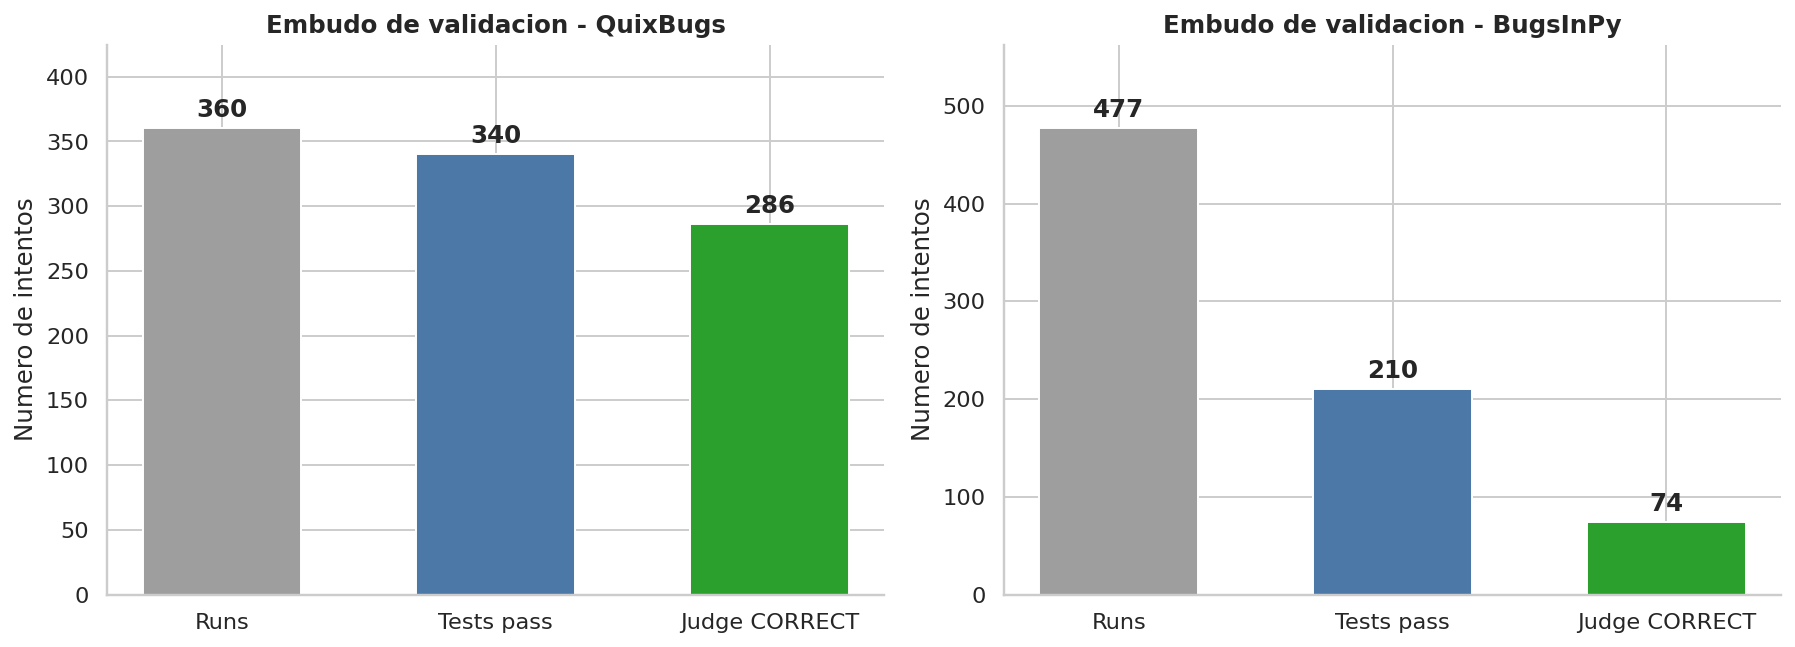

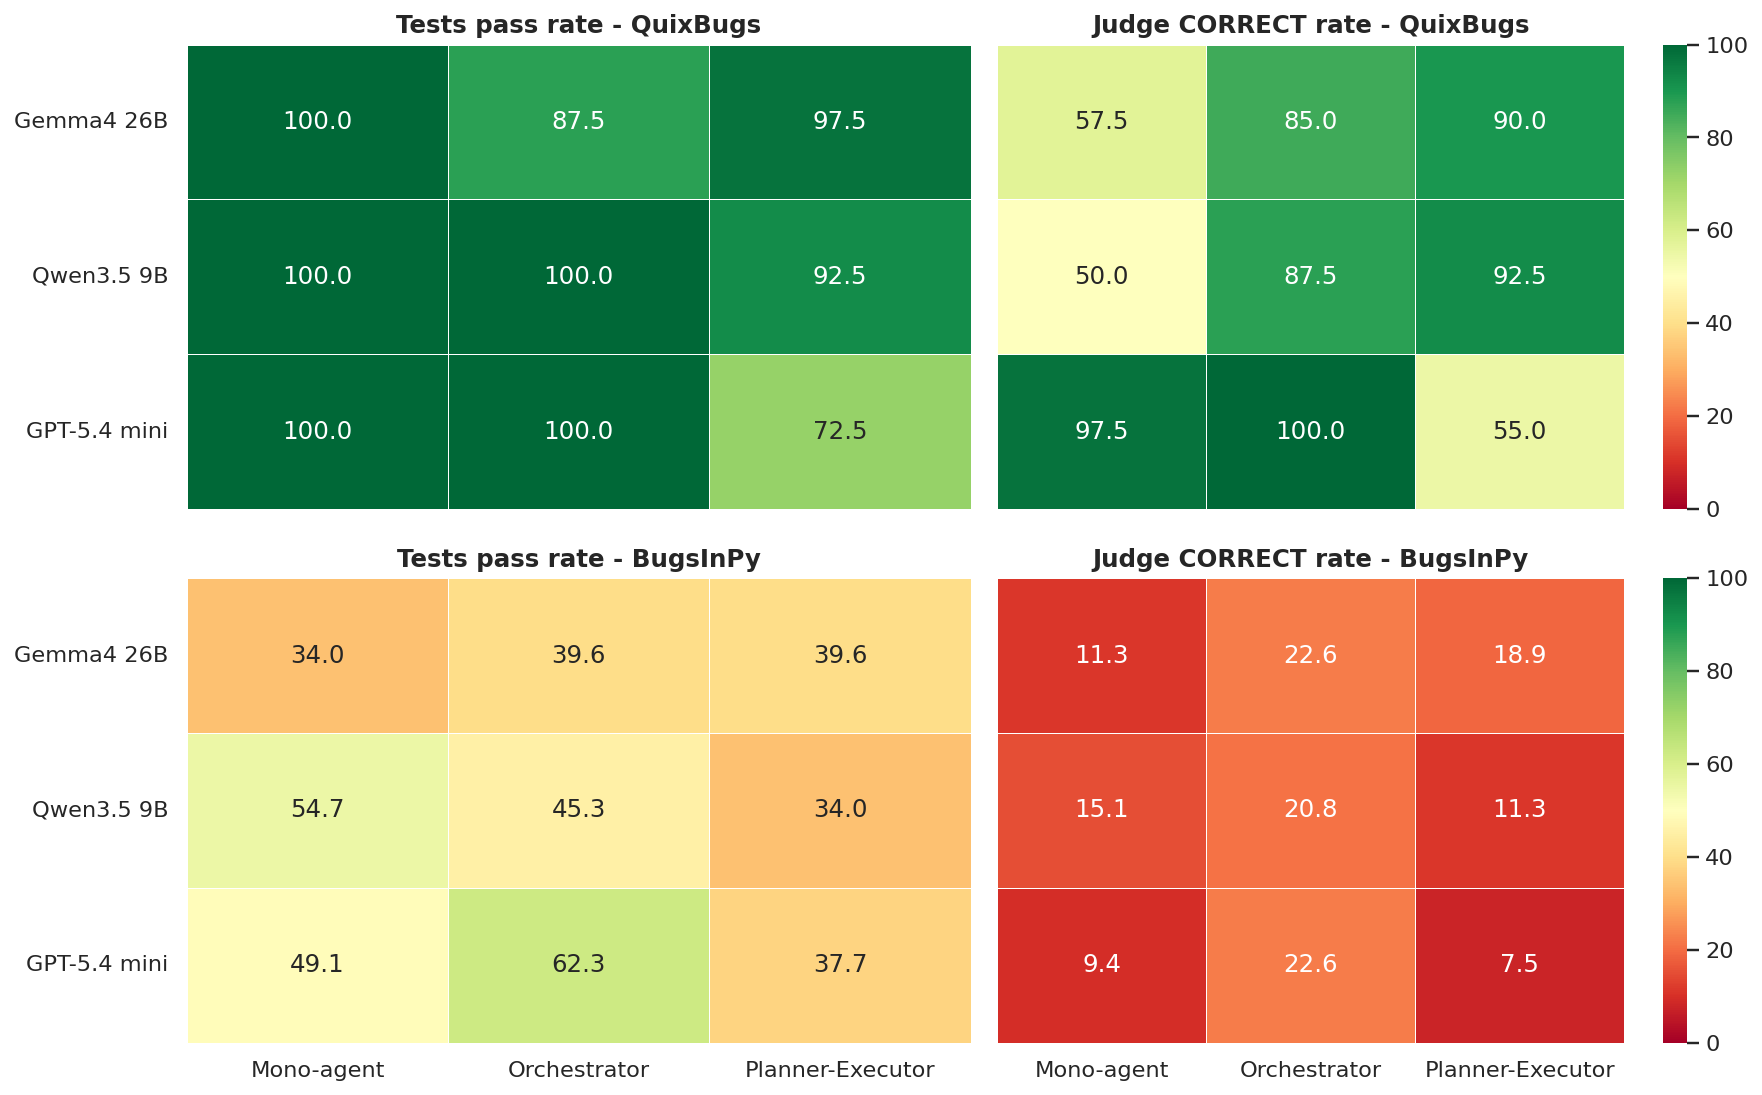

In [10]:
global_kpis = summary_dataset.copy()
global_kpis['tests_failed'] = global_kpis['runs'] - global_kpis['tests_passed']
global_kpis['non_correct_passing'] = global_kpis['tests_passed'] - global_kpis['correct']
display(global_kpis[['dataset_label', 'runs', 'tests_passed', 'test_pass_rate', 'correct', 'correct_rate', 'semantic_gap_points', 'avg_tokens_k', 'avg_seconds']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    row = global_kpis[global_kpis['dataset_label'].eq(dataset)].iloc[0]
    labels = ['Runs', 'Tests pass', 'Judge CORRECT']
    values = [row['runs'], row['tests_passed'], row['correct']]
    colors = ['#9E9E9E', '#4C78A8', '#2CA02C']
    bars = ax.bar(labels, values, color=colors, width=0.58, edgecolor='white')
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + max(values) * 0.025, f'{int(value)}', ha='center', fontweight='bold')
    ax.set_title(f'Embudo de validacion - {dataset}')
    ax.set_ylabel('Numero de intentos')
    ax.set_ylim(0, max(values) * 1.18)
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_global_validation_funnel')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
metrics = [('test_pass_rate', 'Tests pass rate'), ('correct_rate', 'Judge CORRECT rate')]
for row_idx, dataset in enumerate(['QuixBugs', 'BugsInPy']):
    for col_idx, (metric, title) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        data = summary_cfg[summary_cfg['dataset_label'].eq(dataset)]
        pivot = data.pivot(index='model_label', columns='arch_label', values=metric).reindex(index=[MODEL_LABELS[m] for m in MODEL_ORDER], columns=[ARCH_LABELS[a] for a in ARCH_ORDER])
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100, linewidths=0.5, ax=ax, cbar=col_idx == 1)
        ax.set_title(f'{title} - {dataset}')
        ax.set_xlabel('')
        ax.set_ylabel('')
plt.tight_layout()
savefig('final_test_vs_correct_heatmaps')
plt.show()

## 11. Comparar tests automaticos frente a LLM judge

La matriz no pretende convertir al judge en oraculo absoluto. Sirve para medir hasta que punto el resultado de tests sobreestima la correccion real y para localizar clases de desacuerdo utiles en la memoria.

,dataset,runs,agreement_pct,kappa_tests_vs_correct,tests_true_judge_false,tests_false_judge_true
0,BugsInPy,477,71.488,0.379,136,0
1,QuixBugs,360,85.000,0.370,54,0


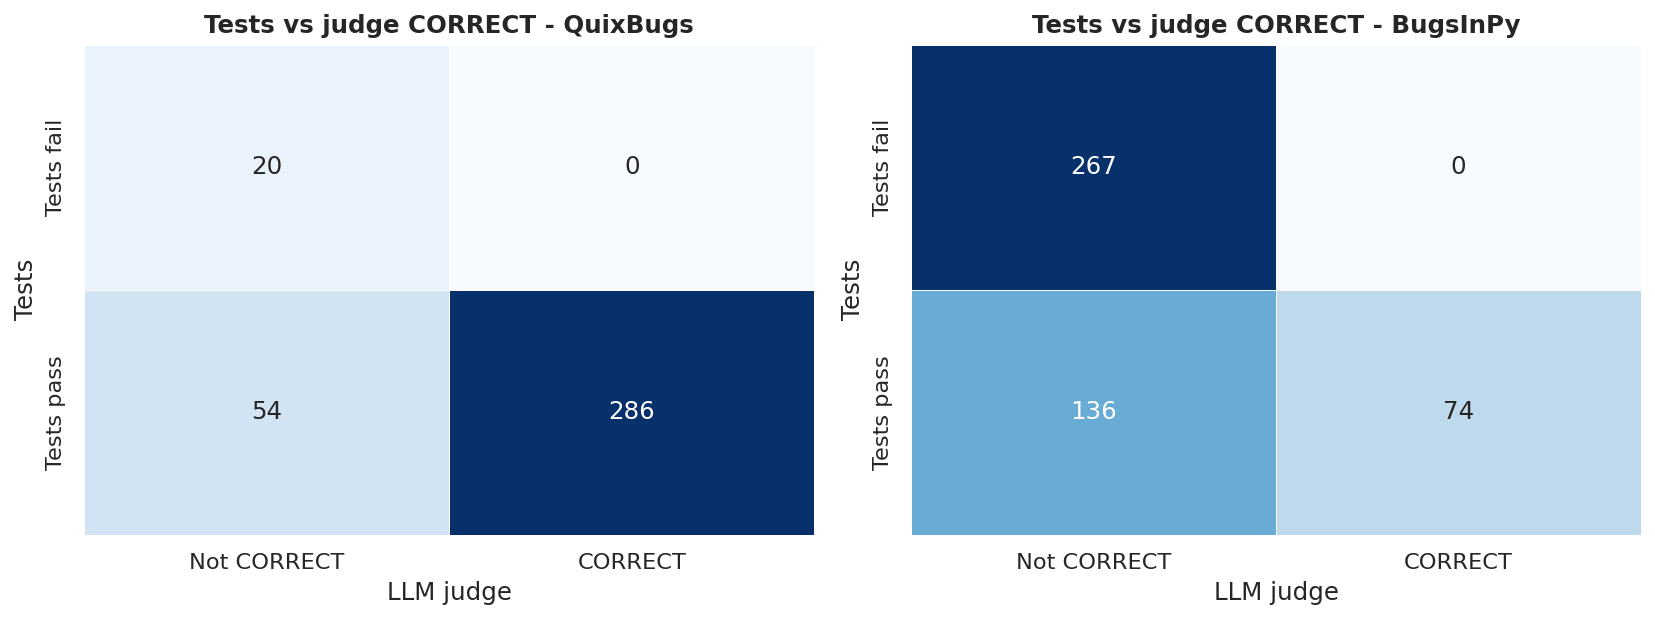

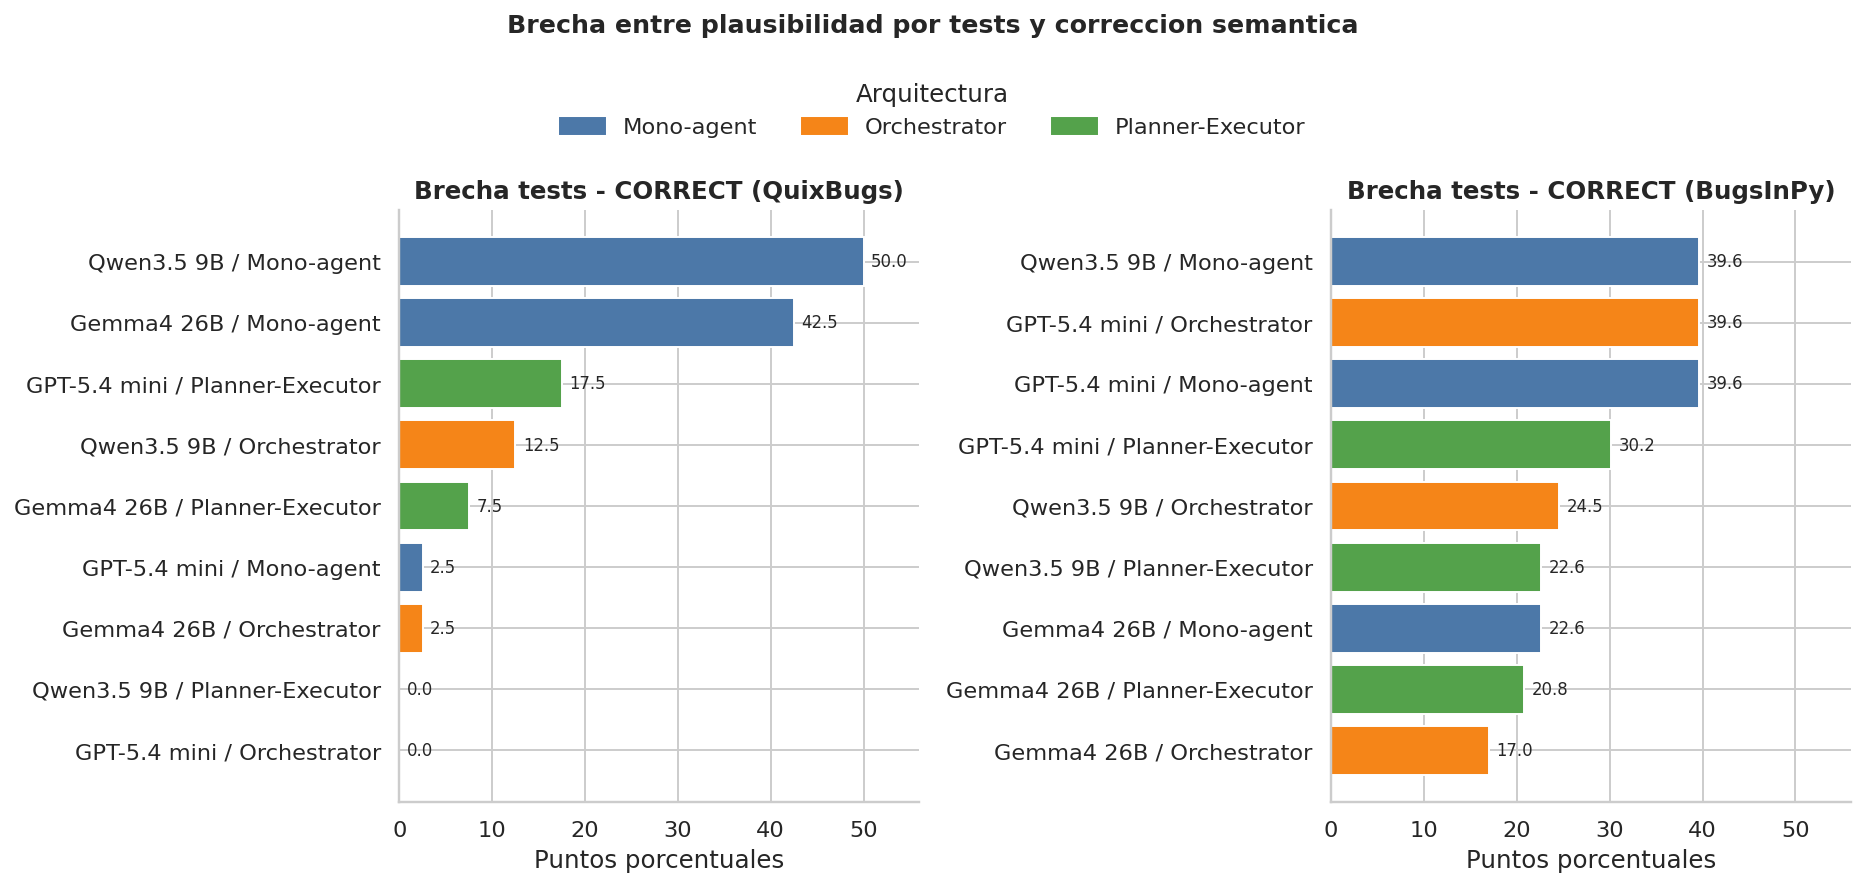

In [11]:
def cohen_kappa_binary(a, b):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)
    if len(a) == 0:
        return np.nan
    po = (a == b).mean()
    pa = a.mean()
    pb = b.mean()
    pe = pa * pb + (1 - pa) * (1 - pb)
    return (po - pe) / (1 - pe) if (1 - pe) else np.nan

judge_binary = analysis_runs.copy()
judge_binary['judge_binary'] = judge_binary['judge_correct']
judge_binary['test_binary'] = judge_binary['tests_pass']

agreement_rows = []
for dataset, group in judge_binary.groupby('dataset_label', observed=True):
    agreement_rows.append({
        'dataset': dataset,
        'runs': len(group),
        'agreement_pct': (group['test_binary'].eq(group['judge_binary']).mean() * 100),
        'kappa_tests_vs_correct': cohen_kappa_binary(group['test_binary'], group['judge_binary']),
        'tests_true_judge_false': int((group['test_binary'] & ~group['judge_binary']).sum()),
        'tests_false_judge_true': int((~group['test_binary'] & group['judge_binary']).sum()),
    })
agreement_df = pd.DataFrame(agreement_rows)
display(agreement_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    g = judge_binary[judge_binary['dataset_label'].eq(dataset)]
    cm = pd.crosstab(g['test_binary'].map({False: 'Tests fail', True: 'Tests pass'}), g['judge_binary'].map({False: 'Not CORRECT', True: 'CORRECT'}))
    cm = cm.reindex(index=['Tests fail', 'Tests pass'], columns=['Not CORRECT', 'CORRECT'], fill_value=0)
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, cbar=False, ax=ax)
    ax.set_title(f'Tests vs judge CORRECT - {dataset}')
    ax.set_xlabel('LLM judge')
    ax.set_ylabel('Tests')
plt.tight_layout()
savefig('final_tests_vs_judge_confusion')
plt.show()

gap_df = summary_cfg.copy()
gap_df['semantic_gap_points'] = gap_df['test_pass_rate'] - gap_df['correct_rate']
gap_df['config_short'] = gap_df['model_label'] + ' / ' + gap_df['arch_label']
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8), sharex=True)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = gap_df[gap_df['dataset_label'].eq(dataset)].sort_values('semantic_gap_points')
    colors = [ARCH_COLORS.get(str(row['architecture']), '#777777') for _, row in data.iterrows()]
    bars = ax.barh(data['config_short'], data['semantic_gap_points'], color=colors, edgecolor='white')
    for bar, value in zip(bars, data['semantic_gap_points']):
        ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f'{value:.1f}', va='center', fontsize=8.5)
    ax.set_title(f'Brecha tests - CORRECT ({dataset})')
    ax.set_xlabel('Puntos porcentuales')
    ax.set_xlim(0, max(55, gap_df['semantic_gap_points'].max() + 6))
    ax.axvline(0, color='#555555', linewidth=0.9)
    sns.despine(ax=ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in ARCH_ORDER]
labels = [ARCH_LABELS[a] for a in ARCH_ORDER]
fig.legend(handles, labels, title='Arquitectura', ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.suptitle('Brecha entre plausibilidad por tests y correccion semantica', y=1.09, fontsize=13, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.98))
savefig('final_semantic_gap_scatter')
savefig('final_semantic_gap_by_config')
plt.show()

## 12. Estudiar correccion semantica validada por el judge

Esta seccion mira los veredictos en los runs que pasan tests. Es donde aparece la diferencia entre `CORRECT`, `PLAUSIBLE` y `OVERFITTING`, que es justo la pieza que el notebook antiguo de QuixBugs no podia explotar. `FAIL` queda fuera de esta composicion porque representa intentos que no pasaron tests.

,dataset_label,model_label,arch_label,verdict_clean,runs,pct_within_config
0,BugsInPy,GPT-5.4 mini,Mono-agent,CORRECT,5,19.230769
1,BugsInPy,GPT-5.4 mini,Mono-agent,PLAUSIBLE,20,76.923077
2,BugsInPy,GPT-5.4 mini,Mono-agent,OVERFITTING,1,3.846154
3,BugsInPy,GPT-5.4 mini,Orchestrator,CORRECT,12,36.363636
4,BugsInPy,GPT-5.4 mini,Orchestrator,PLAUSIBLE,20,60.606061
5,BugsInPy,GPT-5.4 mini,Orchestrator,OVERFITTING,1,3.030303
6,BugsInPy,GPT-5.4 mini,Planner-Executor,CORRECT,4,20.000000
7,BugsInPy,GPT-5.4 mini,Planner-Executor,PLAUSIBLE,11,55.000000
8,BugsInPy,GPT-5.4 mini,Planner-Executor,OVERFITTING,5,25.000000
9,BugsInPy,Gemma4 26B,Mono-agent,CORRECT,6,33.333333


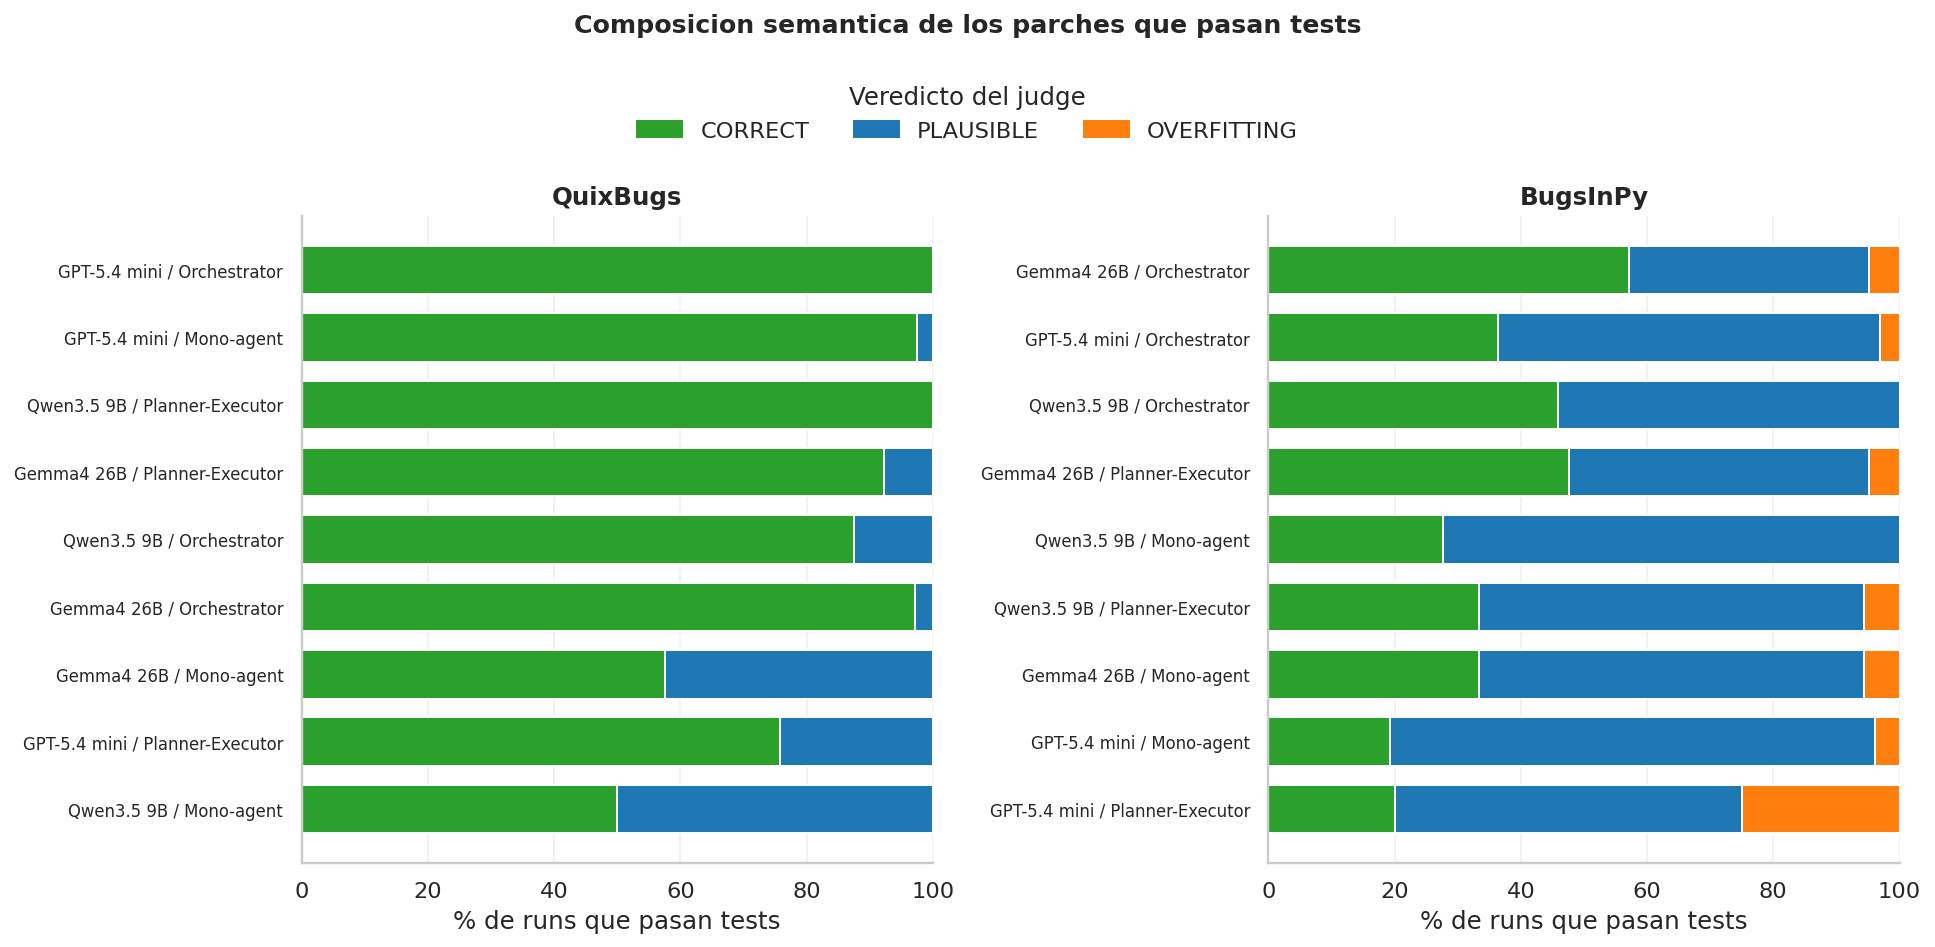

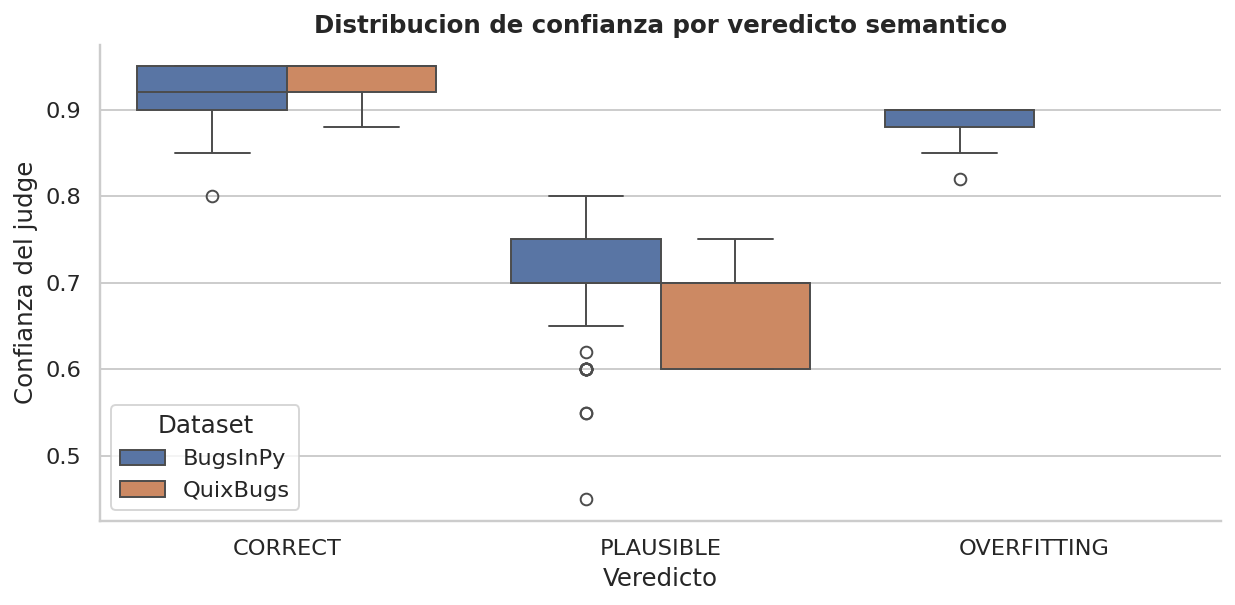

In [12]:
passing = analysis_runs[analysis_runs['tests_pass']].copy()
verdict_counts = (
    passing.groupby(['dataset_label', 'model_label', 'arch_label', 'verdict_clean'], observed=True)
    .size().reset_index(name='runs')
)
verdict_counts = verdict_counts[verdict_counts['verdict_clean'].astype(str).isin(SEMANTIC_VERDICT_ORDER)].copy()
verdict_counts['pct_within_config'] = verdict_counts.groupby(['dataset_label', 'model_label', 'arch_label'], observed=True)['runs'].transform(lambda s: 100 * s / s.sum())

display(verdict_counts.sort_values(['dataset_label', 'model_label', 'arch_label', 'verdict_clean']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), sharex=True)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = verdict_counts[verdict_counts['dataset_label'].eq(dataset)].copy()
    data['config'] = data['model_label'] + ' / ' + data['arch_label']
    cfg_df = summary_cfg[summary_cfg['dataset_label'].eq(dataset)].copy()
    cfg_df['config'] = cfg_df['model_label'] + ' / ' + cfg_df['arch_label']
    configs = cfg_df.sort_values('correct_rate', ascending=True)['config'].tolist()
    bottom = np.zeros(len(configs))
    y_pos = np.arange(len(configs))
    for verdict in SEMANTIC_VERDICT_ORDER:
        vals = []
        for cfg in configs:
            row = data[(data['config'].eq(cfg)) & (data['verdict_clean'].astype(str).eq(verdict))]
            vals.append(float(row['pct_within_config'].iloc[0]) if not row.empty else 0)
        ax.barh(y_pos, vals, left=bottom, label=verdict, color=VERDICT_COLORS[verdict], edgecolor='white', height=0.72)
        bottom += np.array(vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(configs, fontsize=8.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel('% de runs que pasan tests')
    ax.set_title(dataset)
    ax.grid(axis='x', alpha=0.25)
    sns.despine(ax=ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=VERDICT_COLORS[v]) for v in SEMANTIC_VERDICT_ORDER]
labels = SEMANTIC_VERDICT_ORDER
fig.legend(handles, labels, title='Veredicto del judge', ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.suptitle('Composicion semantica de los parches que pasan tests', y=1.09, fontsize=13, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.98))
savefig('final_verdict_composition_on_passing')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
conf_data = analysis_runs[analysis_runs['confidence'].notna() & analysis_runs['verdict_clean'].astype(str).isin(SEMANTIC_VERDICT_ORDER)].copy()
sns.boxplot(data=conf_data, x='verdict_clean', y='confidence', hue='dataset_label', order=SEMANTIC_VERDICT_ORDER, ax=ax)
ax.set_xlabel('Veredicto')
ax.set_ylabel('Confianza del judge')
ax.set_title('Distribucion de confianza por veredicto semantico')
ax.legend(title='Dataset')
sns.despine(ax=ax)
plt.tight_layout()
savefig('final_judge_confidence_by_verdict')
plt.show()

## 13. Detectar desacuerdos entre senales de validacion

Los desacuerdos son candidatos naturales para el storytelling de la memoria: muestran por que no basta con mirar `resolved=1` y donde aparecen parches plausibles, sobreajustes o intentos en los que el agente reparador no consiguio resolver el problema.


,dataset_label,disagreement_type,runs
1,BugsInPy,reparacion_no_resuelta,267
3,BugsInPy,tests_pass_judge_plausible,125
0,BugsInPy,acuerdo_correcto,74
2,BugsInPy,tests_pass_judge_overfitting,11
4,QuixBugs,acuerdo_correcto,286
6,QuixBugs,tests_pass_judge_plausible,54
5,QuixBugs,reparacion_no_resuelta,20


,dataset_label,problem_id,project,model_label,arch_label,tests_pass,verdict_clean,confidence,duration_min,tokens_k,stop_reason,batch_id,justification
18,BugsInPy,httpie-1,httpie,Gemma4 26B,Mono-agent,True,OVERFITTING,0.90,12.812205,221.733,completed,batch-experiment-bugsinpy-mono-agent-gemma4-26b-httpie-20260524T175935Z,Agent created get_filename_max_length() to satisfy test mocks but with hardcoded 255 instead of os.pathconf syscall. Implementation has ...
53,BugsInPy,PySnooper-1,PySnooper,GPT-5.4 mini,Mono-agent,True,OVERFITTING,0.90,0.627694,95.640,completed,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-PySnooper-20260526T182432Z,Agent created stub modules for missing test dependency 'python_toolbox' rather than fixing the actual source code bug (encoding issues i...
204,BugsInPy,tqdm-9,tqdm,Gemma4 26B,Orchestrator,True,OVERFITTING,0.90,11.886909,72.881,completed,batch-experiment-bugsinpy-multi-agent-orchestrator-gemma4-26b-tqdm-20260525T060202Z,"The __len__ fix is correct, but the SI formatting fix hardcodes a string check 'if res == ""10.00"": res = ""10.0""' to pass the specific te..."
243,BugsInPy,thefuck-15,thefuck,GPT-5.4 mini,Orchestrator,True,OVERFITTING,0.90,1.780017,233.040,completed,batch-experiment-bugsinpy-multi-agent-orchestrator-gpt-5.4-mini-thefuck-20260526T220731Z,Agent worked around missing dependencies with try/except fallbacks rather than fixing the actual git_add.py bug. The generated patch inv...
413,BugsInPy,tqdm-8,tqdm,GPT-5.4 mini,Planner-Executor,True,OVERFITTING,0.90,0.689771,93.592,completed,batch-experiment-bugsinpy-planner-executor-gpt-5.4-mini-tqdm-20260527T002820Z,"Agent added conditional special case for exact format string '|{n_fmt}/{total_fmt}' from test, rather than fixing the universal typo (l_..."
450,BugsInPy,scrapy-18,scrapy,Qwen3.5 9B,Planner-Executor,True,OVERFITTING,0.90,5.760916,745.466,completed,batch-experiment-bugsinpy-planner-executor-qwen3.5-9b-scrapy-20260526T183742Z,"Tests pass but fix doesn't address root cause. Canonical patch adds encoding='latin-1', errors='replace' to to_native_str() call to hand..."
349,BugsInPy,thefuck-18,thefuck,Gemma4 26B,Planner-Executor,True,OVERFITTING,0.88,2.507460,404.309,completed,batch-experiment-bugsinpy-planner-executor-gemma4-26b-thefuck-20260525T021625Z,Agent made tests pass by installing missing dependency (psutil) rather than fixing the actual bug. The generated patch only adds whitesp...
400,BugsInPy,thefuck-15,thefuck,GPT-5.4 mini,Planner-Executor,True,OVERFITTING,0.88,1.704130,245.329,completed,batch-experiment-bugsinpy-planner-executor-gpt-5.4-mini-thefuck-20260527T000859Z,"The git_add.py change addresses a related issue but differs from the canonical fix. More critically, the patch includes multiple files (..."
414,BugsInPy,tqdm-9,tqdm,GPT-5.4 mini,Planner-Executor,True,OVERFITTING,0.88,1.210978,213.162,completed,batch-experiment-bugsinpy-planner-executor-gpt-5.4-mini-tqdm-20260527T002820Z,"While __len__ fix and format_sizeof boundaries match canonical semantics, agent added hardcoded string replacements ('10.00K' → '10.0K',..."
402,BugsInPy,thefuck-18,thefuck,GPT-5.4 mini,Planner-Executor,True,OVERFITTING,0.85,1.522660,241.699,completed,batch-experiment-bugsinpy-planner-executor-gpt-5.4-mini-thefuck-20260527T000859Z,"While the sudo.py fix is semantically correct, the patch includes multiple files (git.py, utils.py, shells.py) that add fallbacks for mi..."


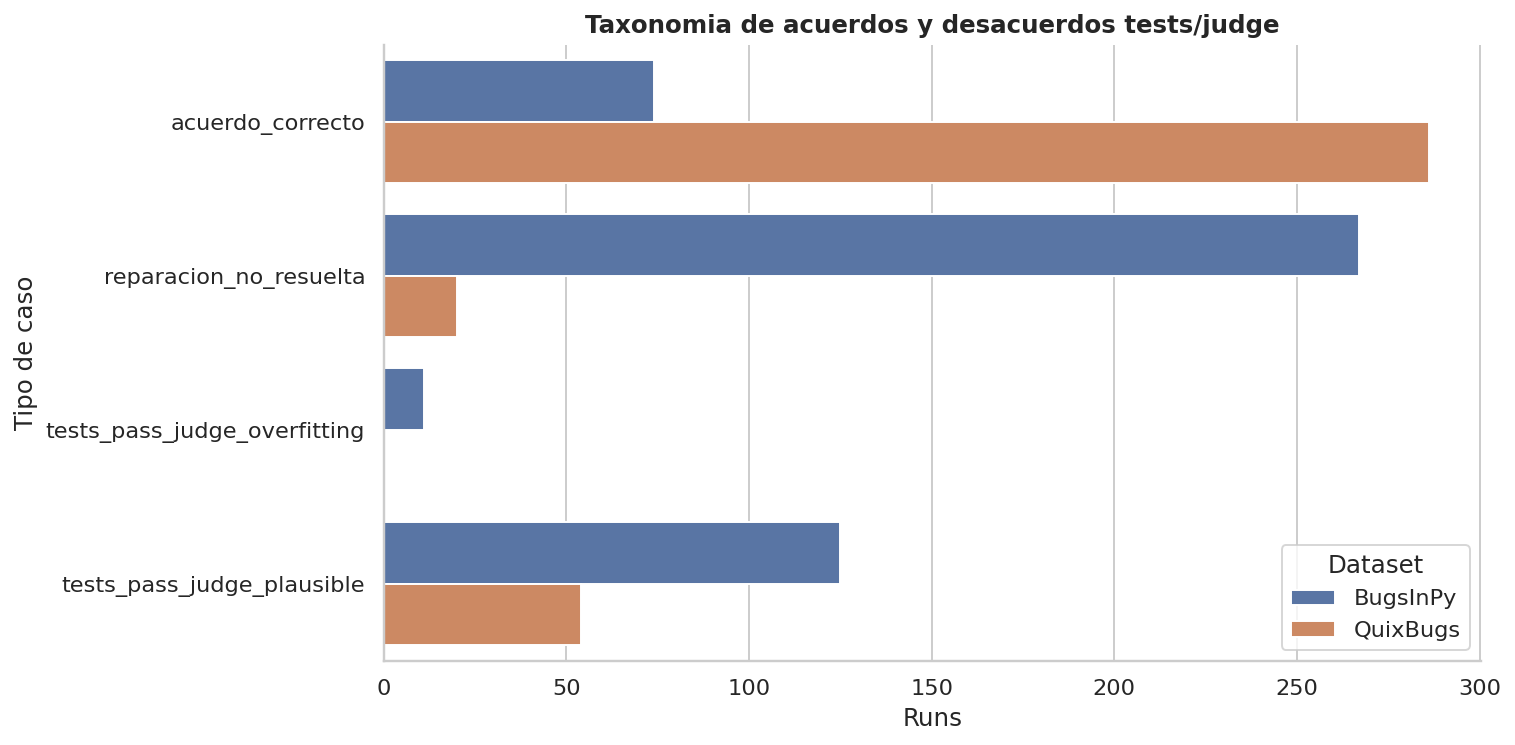

In [13]:
def disagreement_type(row):
    if row['tests_pass'] and row['verdict_clean'] == 'CORRECT':
        return 'acuerdo_correcto'
    if row['tests_pass'] and row['verdict_clean'] == 'PLAUSIBLE':
        return 'tests_pass_judge_plausible'
    if row['tests_pass'] and row['verdict_clean'] == 'OVERFITTING':
        return 'tests_pass_judge_overfitting'
    if row['tests_pass']:
        return 'tests_pass_sin_veredicto_semantico'
    if row['verdict_clean'] == 'FAIL':
        return 'reparacion_no_resuelta'
    return 'tests_fail_veredicto_inconsistente'

analysis_df['disagreement_type'] = analysis_df.apply(disagreement_type, axis=1)
disagreement_summary = analysis_df.groupby(['dataset_label', 'disagreement_type']).size().reset_index(name='runs')
display(disagreement_summary.sort_values(['dataset_label', 'runs'], ascending=[True, False]))

interesting_disagreements = analysis_df[analysis_df['disagreement_type'].isin([
    'tests_pass_judge_plausible', 'tests_pass_judge_overfitting', 'tests_pass_sin_veredicto_semantico', 'tests_fail_veredicto_inconsistente'
])].copy()
interesting_disagreements = interesting_disagreements.sort_values(['dataset_label', 'disagreement_type', 'confidence'], ascending=[True, True, False])
case_cols = ['dataset_label', 'problem_id', 'project', 'model_label', 'arch_label', 'tests_pass', 'verdict_clean', 'confidence', 'duration_min', 'tokens_k', 'stop_reason', 'batch_id', 'justification']
display(interesting_disagreements[case_cols].head(40))

fig, ax = plt.subplots(figsize=(11, 5.5))
plot = disagreement_summary.copy()
sns.barplot(data=plot, y='disagreement_type', x='runs', hue='dataset_label', ax=ax)
ax.set_xlabel('Runs')
ax.set_ylabel('Tipo de caso')
ax.set_title('Taxonomia de acuerdos y desacuerdos tests/judge')
ax.legend(title='Dataset')
sns.despine(ax=ax)
plt.tight_layout()
savefig('final_disagreement_taxonomy')
plt.show()

## 14. Analizar rendimiento por problema o benchmark case

Aqui se ordenan los bugs por dificultad observada. Para BugsInPy se agregan tambien por proyecto, porque la codebase pesa mucho mas que el bug aislado. Para QuixBugs se usa el consenso entre configuraciones.

,dataset_label,project,problem_id,attempts,tests_passed,correct,plausible,overfitting,avg_tokens_k,avg_seconds,pass_rate,correct_rate,difficulty_score
8,BugsInPy,black,black-10,9,0,0,0,0,497.92,482.30,0.00,0.00,100.00
9,BugsInPy,black,black-13,9,0,0,0,0,418.27,732.98,0.00,0.00,100.00
11,BugsInPy,black,black-2,9,0,0,0,0,416.35,417.52,0.00,0.00,100.00
13,BugsInPy,fastapi,fastapi-10,9,0,0,0,0,741.64,528.59,0.00,0.00,100.00
27,BugsInPy,luigi,luigi-5,9,0,0,0,0,531.37,328.10,0.00,0.00,100.00
28,BugsInPy,scrapy,scrapy-16,9,0,0,0,0,671.19,475.64,0.00,0.00,100.00
31,BugsInPy,scrapy,scrapy-25,9,0,0,0,0,542.99,330.77,0.00,0.00,100.00
1,BugsInPy,PySnooper,PySnooper-2,9,1,0,1,0,478.25,443.86,11.11,0.00,100.00
10,BugsInPy,black,black-19,9,1,0,1,0,468.43,465.99,11.11,0.00,100.00
17,BugsInPy,fastapi,fastapi-5,9,1,0,1,0,553.04,447.21,11.11,0.00,100.00


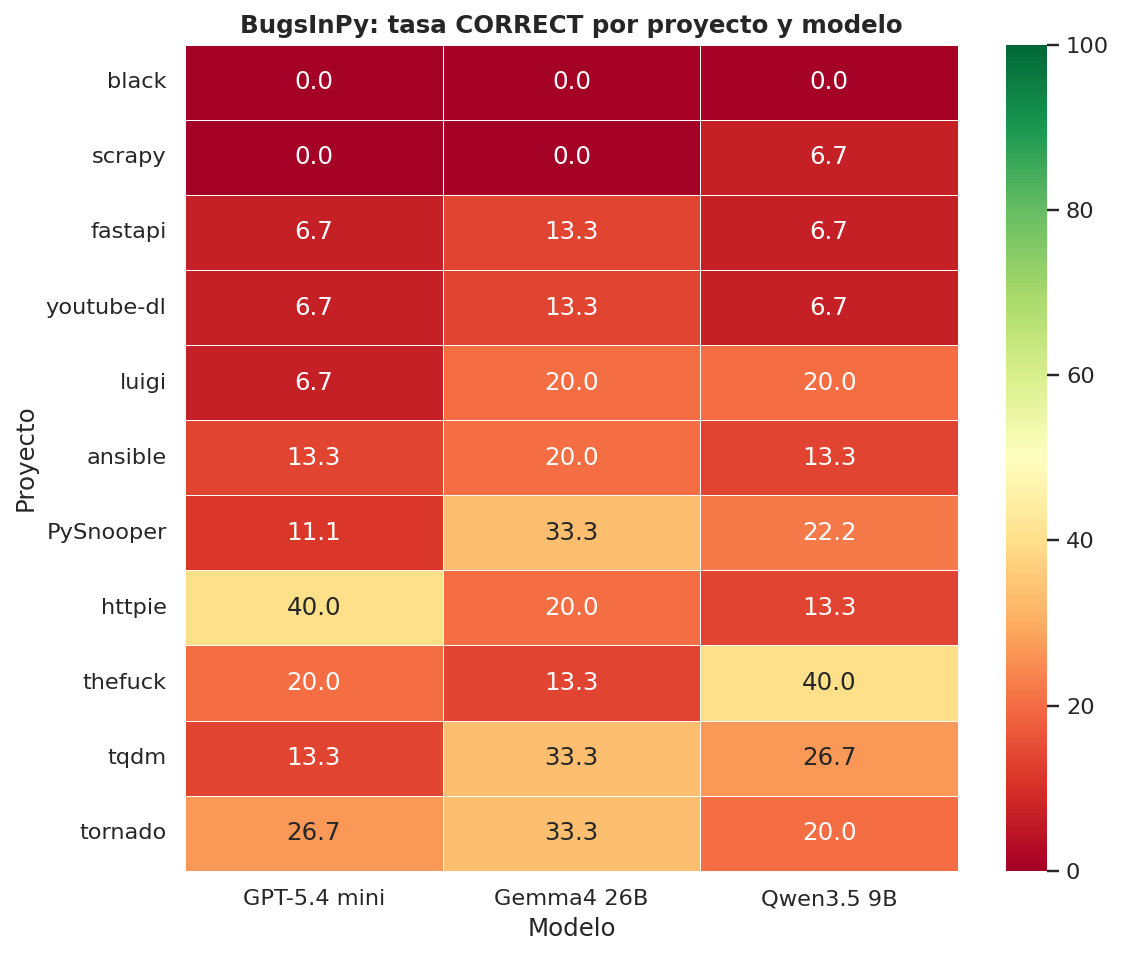

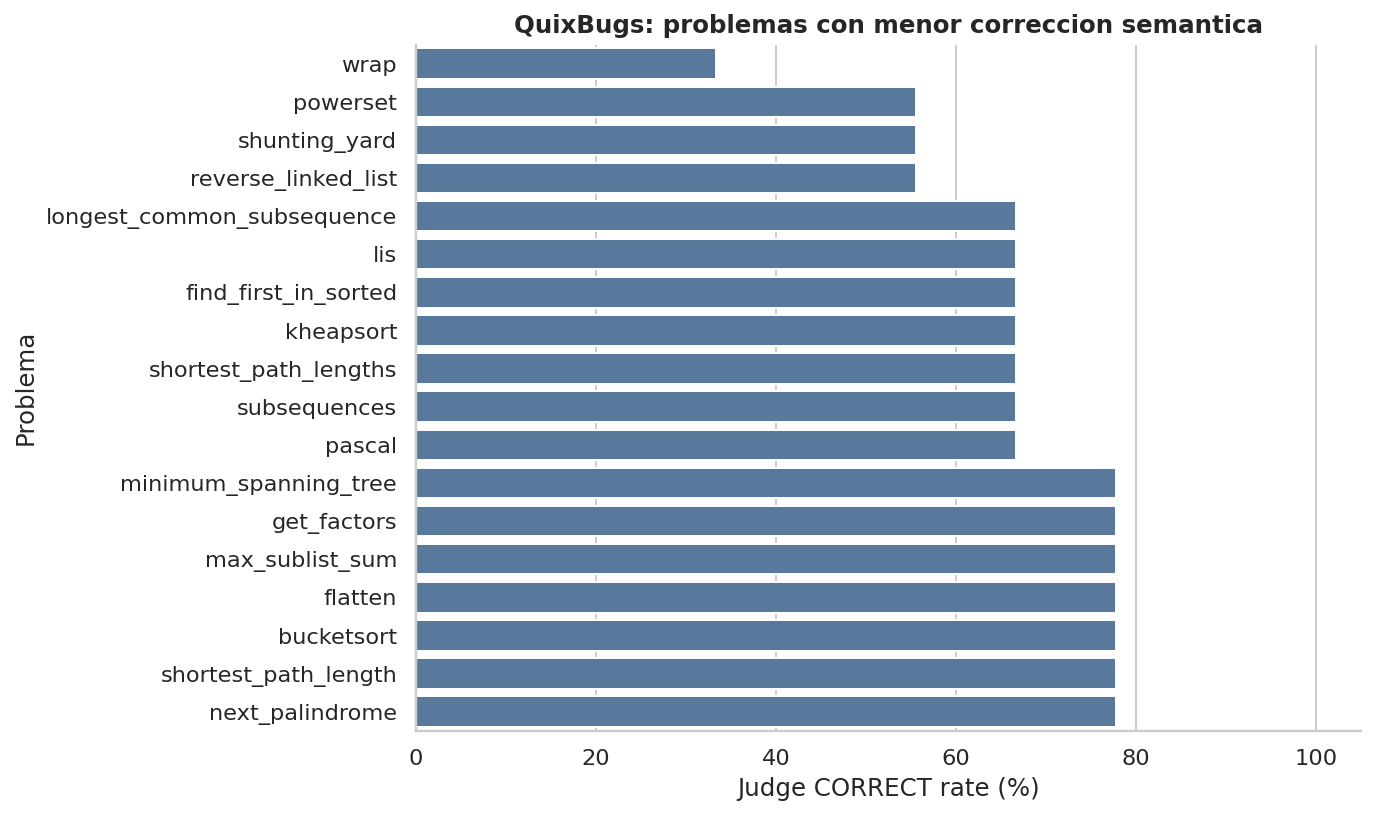

In [14]:
problem_summary = (
    analysis_runs.groupby(['dataset_label', 'project', 'problem_id'], observed=True)
    .agg(
        attempts=('run_id', 'count'),
        tests_passed=('tests_pass', 'sum'),
        correct=('judge_correct', 'sum'),
        plausible=('judge_plausible', 'sum'),
        overfitting=('judge_overfitting', 'sum'),
        avg_tokens_k=('tokens_k', 'mean'),
        avg_seconds=('duration_seconds', 'mean'),
    )
    .reset_index()
)
problem_summary['pass_rate'] = problem_summary.apply(lambda r: pct(r['tests_passed'], r['attempts']), axis=1)
problem_summary['correct_rate'] = problem_summary.apply(lambda r: pct(r['correct'], r['attempts']), axis=1)
problem_summary['difficulty_score'] = 100 - problem_summary['correct_rate']

display(problem_summary.sort_values(['dataset_label', 'correct_rate', 'pass_rate']).head(30).round(2))

project_summary = (
    analysis_runs[analysis_runs['dataset_label'].eq('BugsInPy')]
    .groupby('project', observed=True)
    .agg(attempts=('run_id', 'count'), tests_passed=('tests_pass', 'sum'), correct=('judge_correct', 'sum'), avg_tokens_k=('tokens_k', 'mean'))
    .reset_index()
)
project_summary['pass_rate'] = project_summary.apply(lambda r: pct(r['tests_passed'], r['attempts']), axis=1)
project_summary['correct_rate'] = project_summary.apply(lambda r: pct(r['correct'], r['attempts']), axis=1)
project_summary = project_summary.sort_values('correct_rate')

data = analysis_runs[analysis_runs['dataset_label'].eq('BugsInPy')]
project_model = data.groupby(['project', 'model_label'], observed=True)['judge_correct'].mean().mul(100).reset_index()
pivot = project_model.pivot(index='project', columns='model_label', values='judge_correct').reindex(project_summary['project'])
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title('BugsInPy: tasa CORRECT por proyecto y modelo')
ax.set_xlabel('Modelo')
ax.set_ylabel('Proyecto')
plt.tight_layout()
savefig('final_bugsinpy_project_model_correct_heatmap')
plt.show()

qb = problem_summary[problem_summary['dataset_label'].eq('QuixBugs')].sort_values('correct_rate').head(18)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=qb, y='problem_id', x='correct_rate', color='#4C78A8', ax=ax)
ax.set_xlim(0, 105)
ax.set_xlabel('Judge CORRECT rate (%)')
ax.set_ylabel('Problema')
ax.set_title('QuixBugs: problemas con menor correccion semantica')
sns.despine(ax=ax)
plt.tight_layout()
savefig('final_quixbugs_hardest_problems')
plt.show()

## 15. Analizar rendimiento por modelo, estrategia o configuracion

Esta seccion responde directamente a RQ1 y RQ2: que cambia al variar arquitectura y modelo. Las barras usan intervalos Wilson para no presentar diferencias pequenas como si fueran certezas absolutas.

,dataset_label,model_label,arch_label,runs,test_pass_rate,correct_rate,semantic_precision_on_pass,avg_tokens_k,correct_per_million_tokens
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,62.26,22.64,36.36,225.79,1.00
4,BugsInPy,Gemma4 26B,Orchestrator,53,39.62,22.64,57.14,195.25,1.16
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,45.28,20.75,45.83,676.65,0.31
5,BugsInPy,Gemma4 26B,Planner-Executor,53,39.62,18.87,47.62,270.20,0.70
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,54.72,15.09,27.59,686.17,0.22
3,BugsInPy,Gemma4 26B,Mono-agent,53,33.96,11.32,33.33,196.21,0.58
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,33.96,11.32,33.33,706.93,0.16
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,49.06,9.43,19.23,289.97,0.33
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,37.74,7.55,20.00,215.72,0.35
10,QuixBugs,GPT-5.4 mini,Orchestrator,40,100.00,100.00,100.00,25.70,38.91


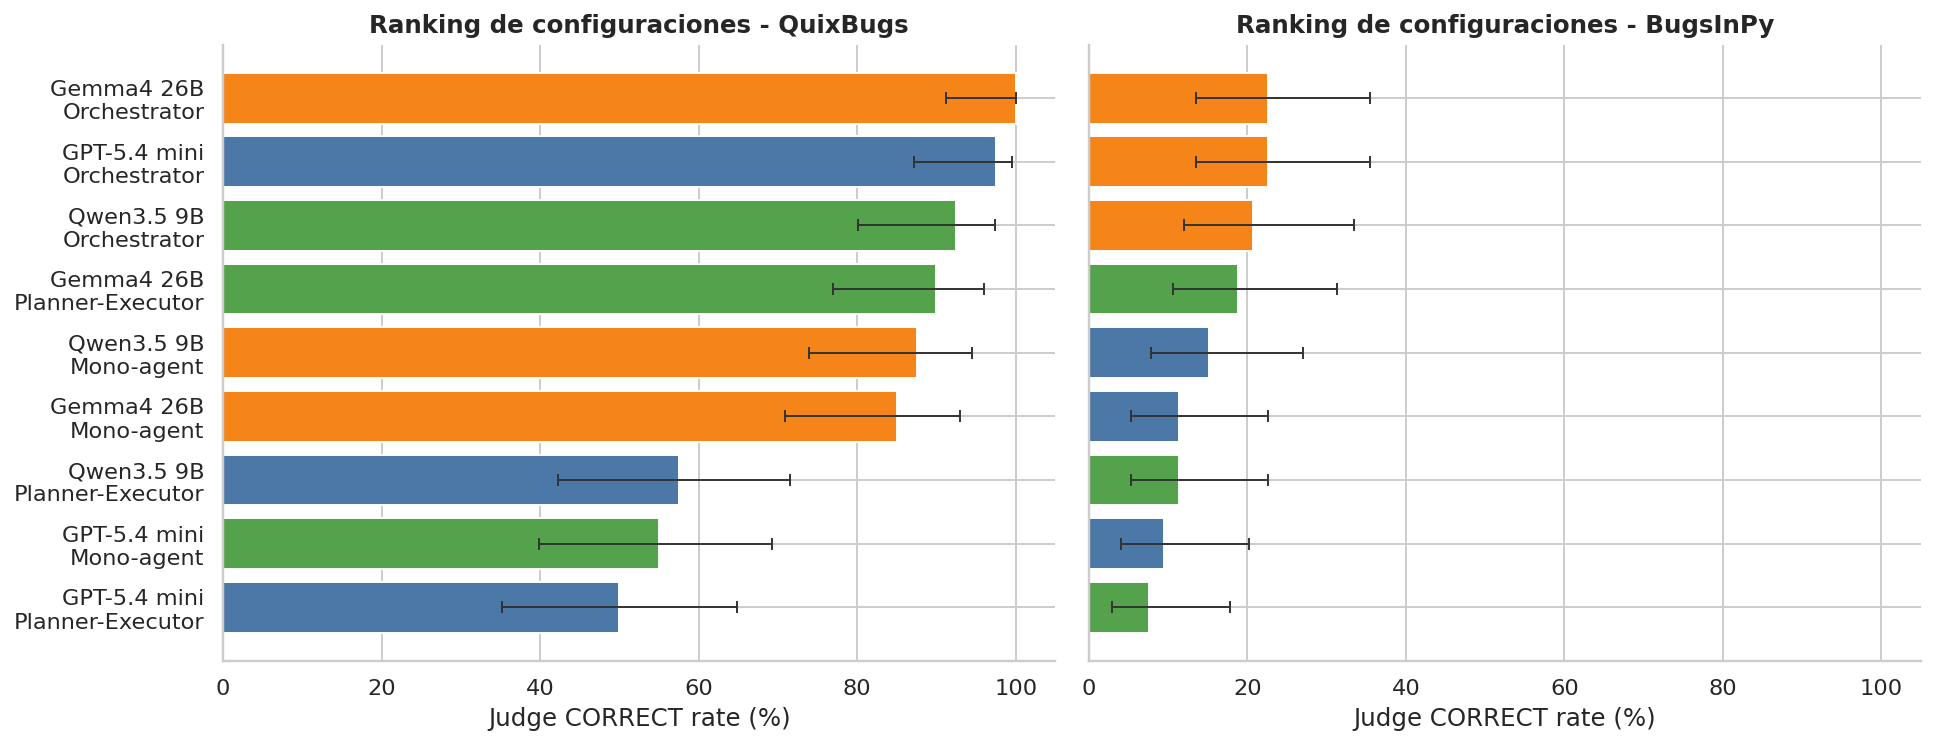

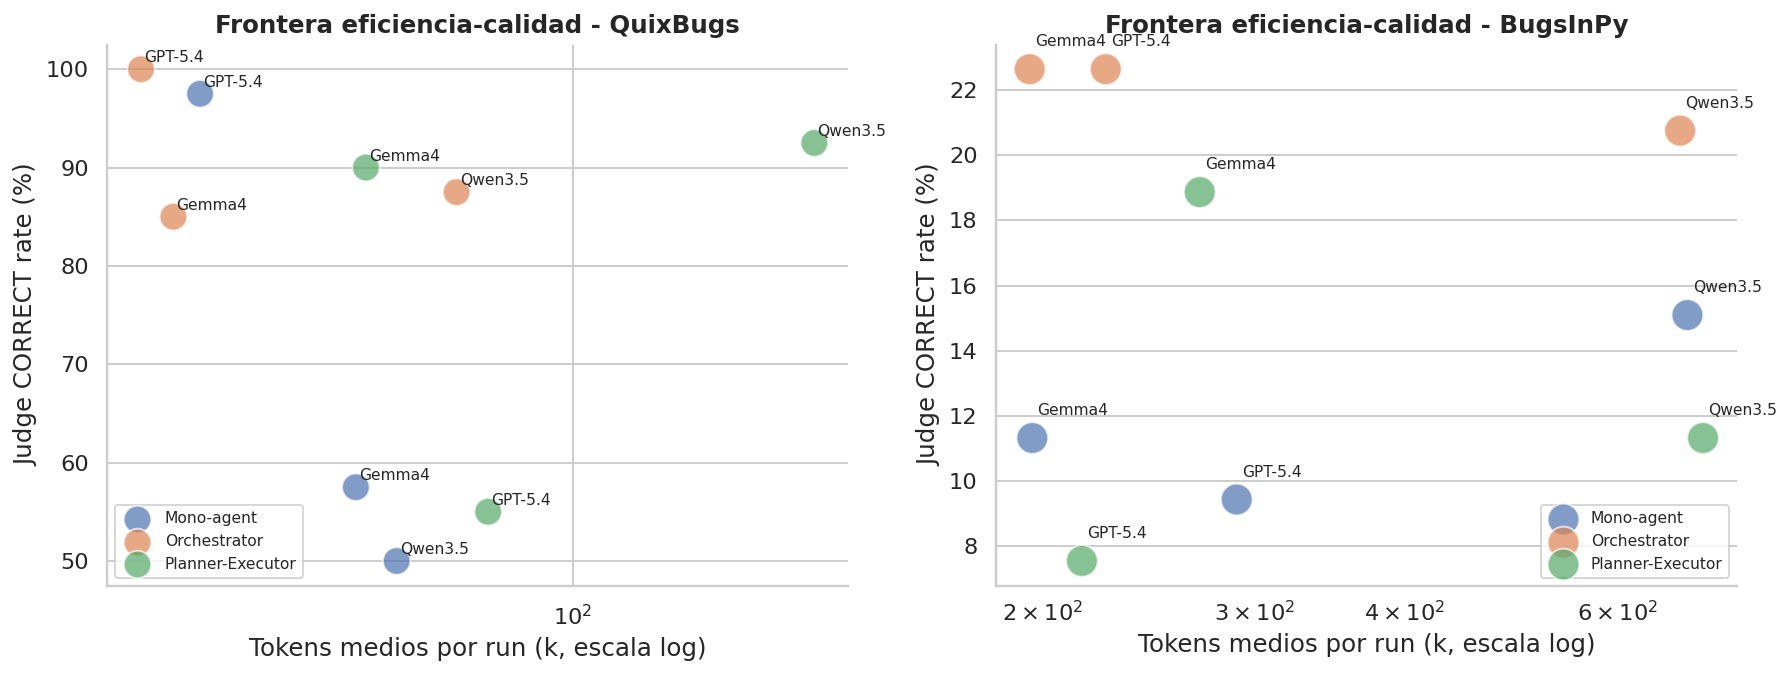

In [15]:
rank_cfg = summary_cfg.sort_values(['dataset_label', 'correct_rate', 'test_pass_rate'], ascending=[True, False, False]).copy()
rank_cfg['label'] = rank_cfg['model_label'] + '\n' + rank_cfg['arch_label']

display(rank_cfg[['dataset_label', 'model_label', 'arch_label', 'runs', 'test_pass_rate', 'correct_rate', 'semantic_precision_on_pass', 'avg_tokens_k', 'correct_per_million_tokens']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = rank_cfg[rank_cfg['dataset_label'].eq(dataset)].sort_values('correct_rate')
    y = np.arange(len(data))
    x = data['correct_rate'].to_numpy()
    low = x - data['correct_ci_low'].to_numpy()
    high = data['correct_ci_high'].to_numpy() - x
    ax.barh(y, x, color=[ARCH_COLORS.get(str(a), '#777') for a in data['architecture']], edgecolor='white')
    ax.errorbar(x, y, xerr=[low, high], fmt='none', ecolor='#333333', capsize=3, linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(data['label'])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Judge CORRECT rate (%)')
    ax.set_title(f'Ranking de configuraciones - {dataset}')
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_configuration_correct_ranking')
plt.show()

frontier = rank_cfg.copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = frontier[frontier['dataset_label'].eq(dataset)]
    for arch in [ARCH_LABELS[a] for a in ARCH_ORDER]:
        sub = data[data['arch_label'].eq(arch)]
        ax.scatter(sub['avg_tokens_k'], sub['correct_rate'], s=sub['runs'] * 5, alpha=0.7, label=arch, edgecolor='white')
        for _, row in sub.iterrows():
            ax.text(row['avg_tokens_k'] * 1.01, row['correct_rate'] + 0.7, row['model_label'].split()[0], fontsize=8)
    ax.set_xscale('log')
    ax.set_xlabel('Tokens medios por run (k, escala log)')
    ax.set_ylabel('Judge CORRECT rate (%)')
    ax.set_title(f'Frontera eficiencia-calidad - {dataset}')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_efficiency_quality_frontier')
plt.show()

## 15.1 Analizar uso de herramientas por configuracion

El uso de herramientas permite medir eficiencia procedimental: cuanta exploracion, edicion y validacion necesita cada arquitectura para producir sus resultados. Esta lectura complementa tokens y duracion porque distingue patrones de sobreexploracion, edicion tardia o validacion intensiva.

,dataset_label,model_label,arch_label,runs,correct,correct_rate,avg_tool_calls,avg_exploration_calls,avg_edit_calls,avg_test_command_calls,avg_exploration_share,correct_per_100_tool_calls
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,6,11.32,62.92,39.53,6.60,16.09,0.62,0.18
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,11,20.75,51.30,35.42,9.47,6.42,0.67,0.40
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,8,15.09,50.53,28.47,7.40,13.11,0.53,0.30
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,5,9.43,32.96,20.62,5.96,4.77,0.61,0.29
5,BugsInPy,Gemma4 26B,Planner-Executor,53,10,18.87,32.70,21.77,4.04,6.68,0.67,0.58
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,4,7.55,29.00,17.68,3.30,7.96,0.61,0.26
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,12,22.64,26.53,17.57,5.02,3.94,0.66,0.85
3,BugsInPy,Gemma4 26B,Mono-agent,53,6,11.32,25.06,18.02,2.72,4.11,0.76,0.45
4,BugsInPy,Gemma4 26B,Orchestrator,53,12,22.64,23.85,17.81,2.87,3.17,0.76,0.95
17,QuixBugs,Qwen3.5 9B,Planner-Executor,40,37,92.50,31.50,12.48,3.75,14.42,0.43,2.94


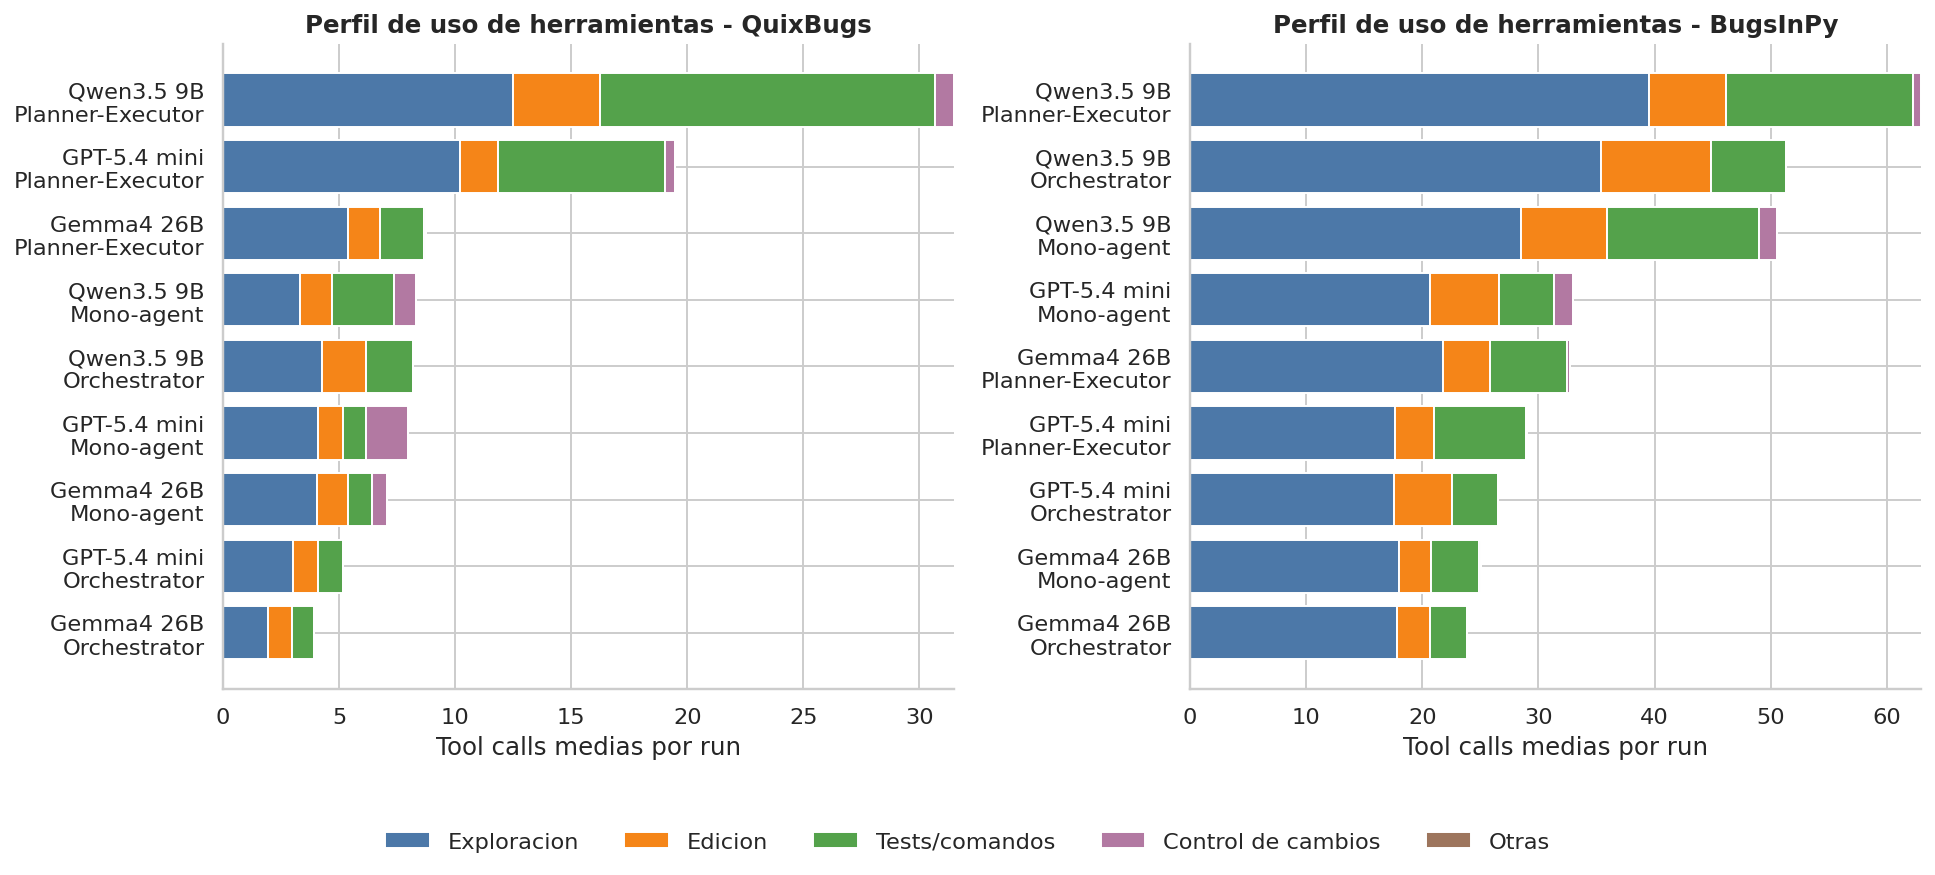

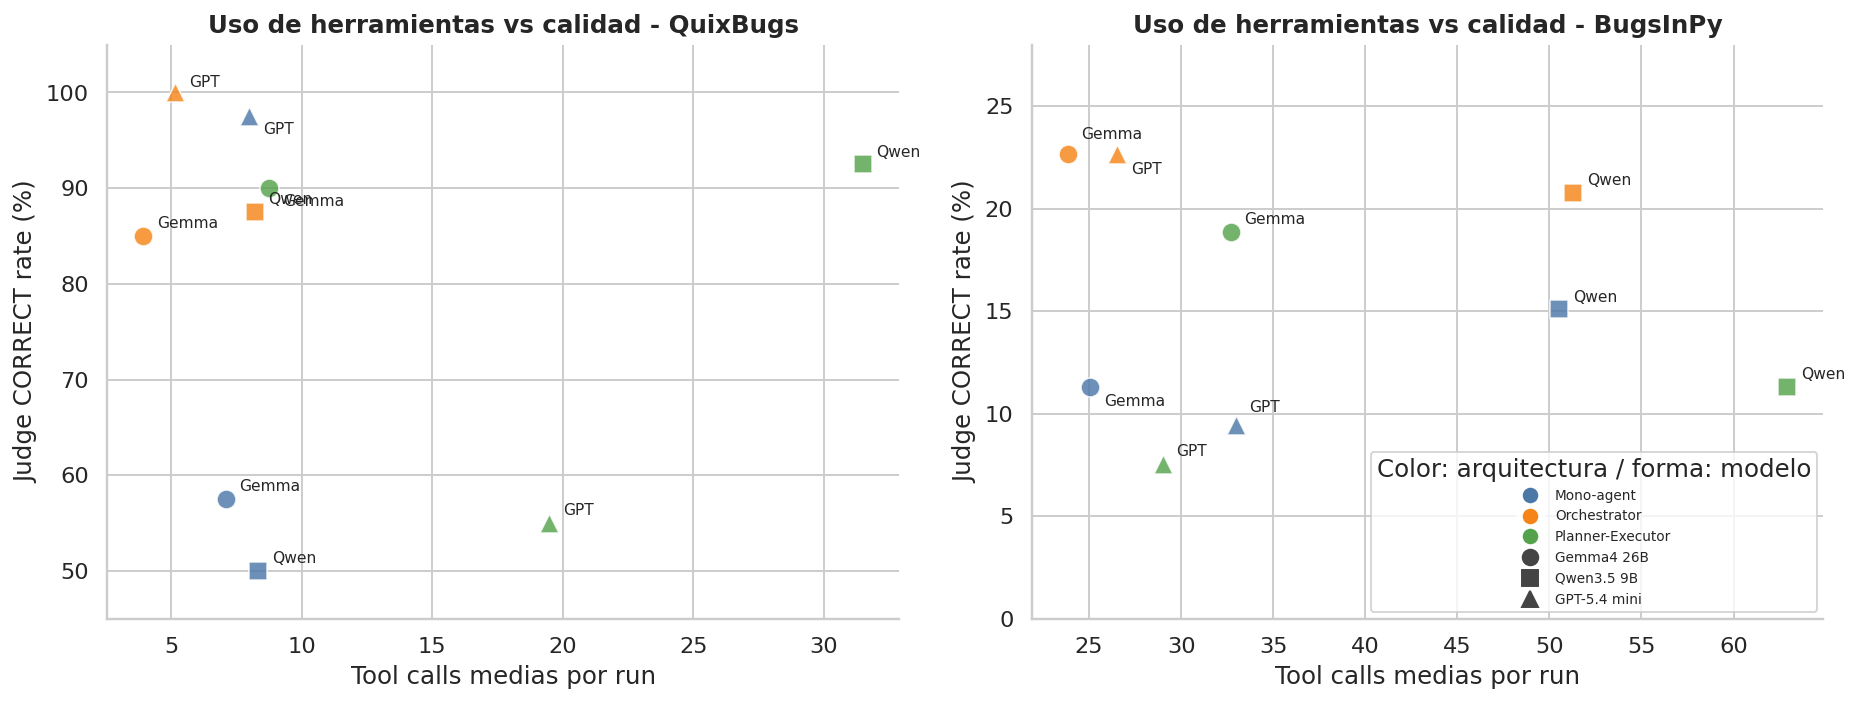

In [16]:
TOOL_CATEGORY_ORDER = ['Exploracion', 'Edicion', 'Tests/comandos', 'Control de cambios', 'Otras']
TOOL_CATEGORY_COLORS = {
    'Exploracion': '#4C78A8',
    'Edicion': '#F58518',
    'Tests/comandos': '#54A24B',
    'Control de cambios': '#B279A2',
    'Otras': '#9D755D',
}
TOOL_CATEGORY_BY_NAME = {
    'read_file': 'Exploracion',
    'search_files': 'Exploracion',
    'list_files': 'Exploracion',
    'get_workspace_info': 'Exploracion',
    'explore_code': 'Exploracion',
    'replace_in_file': 'Edicion',
    'replace_lines': 'Edicion',
    'write_file': 'Edicion',
    'apply_unified_diff': 'Edicion',
    'run_test_target': 'Tests/comandos',
    'run_tests': 'Tests/comandos',
    'execute_command': 'Tests/comandos',
    'git_diff_summary': 'Control de cambios',
    'git_status_summary': 'Control de cambios',
}
ARCH_COLOR_BY_LABEL = {ARCH_LABELS[key]: ARCH_COLORS[key] for key in ARCH_ORDER}
MODEL_ABBREV = {
    'Gemma4 26B': 'Gemma',
    'Qwen3.5 9B': 'Qwen',
    'GPT-5.4 mini': 'GPT',
}
MODEL_MARKERS = {
    'Gemma4 26B': 'o',
    'Qwen3.5 9B': 's',
    'GPT-5.4 mini': '^',
}
LABEL_OFFSETS = {
    ('BugsInPy', 'Gemma4 26B', 'Orchestrator'): (7, 8),
    ('BugsInPy', 'GPT-5.4 mini', 'Orchestrator'): (7, -10),
    ('BugsInPy', 'Gemma4 26B', 'Mono-agent'): (7, -10),
    ('BugsInPy', 'GPT-5.4 mini', 'Mono-agent'): (7, 7),
    ('QuixBugs', 'GPT-5.4 mini', 'Orchestrator'): (7, 3),
    ('QuixBugs', 'GPT-5.4 mini', 'Mono-agent'): (7, -9),
    ('QuixBugs', 'Gemma4 26B', 'Planner-Executor'): (7, -9),
}

tool_usage = tool_calls.copy()
tool_usage['tool_category'] = tool_usage['tool_name'].map(TOOL_CATEGORY_BY_NAME).fillna('Otras')

tool_usage_by_run = (
    tool_usage.groupby(['run_id', 'tool_category'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for category in TOOL_CATEGORY_ORDER:
    if category not in tool_usage_by_run:
        tool_usage_by_run[category] = 0

tool_run_cols = [
    'run_id', 'dataset_label', 'model_label', 'arch_label', 'architecture', 'config',
    'tests_pass', 'judge_correct', 'tokens_k', 'duration_min'
]
run_tool_usage = analysis_runs[tool_run_cols].merge(tool_usage_by_run[['run_id'] + TOOL_CATEGORY_ORDER], on='run_id', how='left')
run_tool_usage[TOOL_CATEGORY_ORDER] = run_tool_usage[TOOL_CATEGORY_ORDER].fillna(0)
run_tool_usage['tool_calls_total'] = run_tool_usage[TOOL_CATEGORY_ORDER].sum(axis=1)
run_tool_usage['exploration_share'] = np.where(
    run_tool_usage['tool_calls_total'].gt(0),
    run_tool_usage['Exploracion'] / run_tool_usage['tool_calls_total'],
    np.nan,
)

tool_usage_by_config = (
    run_tool_usage.groupby(['dataset_label', 'model_label', 'arch_label', 'architecture', 'config'], observed=True)
    .agg(
        runs=('run_id', 'count'),
        tests_passed=('tests_pass', 'sum'),
        correct=('judge_correct', 'sum'),
        avg_tool_calls=('tool_calls_total', 'mean'),
        median_tool_calls=('tool_calls_total', 'median'),
        avg_exploration_calls=('Exploracion', 'mean'),
        avg_edit_calls=('Edicion', 'mean'),
        avg_test_command_calls=('Tests/comandos', 'mean'),
        avg_change_control_calls=('Control de cambios', 'mean'),
        avg_other_calls=('Otras', 'mean'),
        avg_exploration_share=('exploration_share', 'mean'),
        avg_tokens_k=('tokens_k', 'mean'),
        avg_duration_min=('duration_min', 'mean'),
    )
    .reset_index()
)
tool_usage_by_config['test_pass_rate'] = tool_usage_by_config.apply(lambda r: pct(r['tests_passed'], r['runs']), axis=1)
tool_usage_by_config['correct_rate'] = tool_usage_by_config.apply(lambda r: pct(r['correct'], r['runs']), axis=1)
tool_usage_by_config['correct_per_100_tool_calls'] = np.where(
    tool_usage_by_config['avg_tool_calls'].gt(0),
    100 * tool_usage_by_config['correct'] / (tool_usage_by_config['avg_tool_calls'] * tool_usage_by_config['runs']),
    np.nan,
)

display(
    tool_usage_by_config[
        [
            'dataset_label', 'model_label', 'arch_label', 'runs', 'correct', 'correct_rate',
            'avg_tool_calls', 'avg_exploration_calls', 'avg_edit_calls', 'avg_test_command_calls',
            'avg_exploration_share', 'correct_per_100_tool_calls'
        ]
    ]
    .sort_values(['dataset_label', 'avg_tool_calls'], ascending=[True, False])
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), sharey=False)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = tool_usage_by_config[tool_usage_by_config['dataset_label'].eq(dataset)].sort_values('avg_tool_calls')
    labels = data['model_label'] + '\n' + data['arch_label']
    y = np.arange(len(data))
    left = np.zeros(len(data))
    category_to_column = {
        'Exploracion': 'avg_exploration_calls',
        'Edicion': 'avg_edit_calls',
        'Tests/comandos': 'avg_test_command_calls',
        'Control de cambios': 'avg_change_control_calls',
        'Otras': 'avg_other_calls',
    }
    for category in TOOL_CATEGORY_ORDER:
        values = data[category_to_column[category]].to_numpy()
        ax.barh(y, values, left=left, color=TOOL_CATEGORY_COLORS[category], edgecolor='white', label=category)
        left += values
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Tool calls medias por run')
    ax.set_title(f'Perfil de uso de herramientas - {dataset}')
    sns.despine(ax=ax)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.08, 1, 1))
savefig('final_tool_usage_profile_by_config')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=False)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = tool_usage_by_config[tool_usage_by_config['dataset_label'].eq(dataset)]
    for _, row in data.iterrows():
        ax.scatter(
            row['avg_tool_calls'],
            row['correct_rate'],
            s=95,
            color=ARCH_COLOR_BY_LABEL.get(row['arch_label'], '#777777'),
            marker=MODEL_MARKERS.get(row['model_label'], 'o'),
            alpha=0.82,
            edgecolor='white',
            linewidth=0.8,
        )
        offset = LABEL_OFFSETS.get((dataset, row['model_label'], row['arch_label']), (7, 4))
        ax.annotate(
            MODEL_ABBREV.get(row['model_label'], row['model_label']),
            xy=(row['avg_tool_calls'], row['correct_rate']),
            xytext=offset,
            textcoords='offset points',
            fontsize=8,
        )
    ax.set_xlabel('Tool calls medias por run')
    ax.set_ylabel('Judge CORRECT rate (%)')
    ax.set_title(f'Uso de herramientas vs calidad - {dataset}')
    if dataset == 'QuixBugs':
        ax.set_ylim(45, 105)
    else:
        ax.set_ylim(0, 28)
    sns.despine(ax=ax)

from matplotlib.lines import Line2D
arch_handles = [
    Line2D([0], [0], marker='o', color='w', label=ARCH_LABELS[key], markerfacecolor=ARCH_COLORS[key], markersize=9)
    for key in ARCH_ORDER
]
model_handles = [
    Line2D([0], [0], marker=marker, color='#444444', label=model, linestyle='None', markersize=8)
    for model, marker in MODEL_MARKERS.items()
]
axes[1].legend(handles=arch_handles + model_handles, title='Color: arquitectura / forma: modelo', fontsize=7, loc='lower right')
plt.tight_layout()
savefig('final_tool_usage_vs_correct_rate')
plt.show()

## 16. Visualizar distribucion de scores, veredictos y confianza del judge

La confianza no sustituye al veredicto, pero ayuda a detectar casos ambiguos. Si los `PLAUSIBLE` aparecen con confianza mas baja que los `CORRECT`, el judge esta separando dos clases de parches de forma informativa.

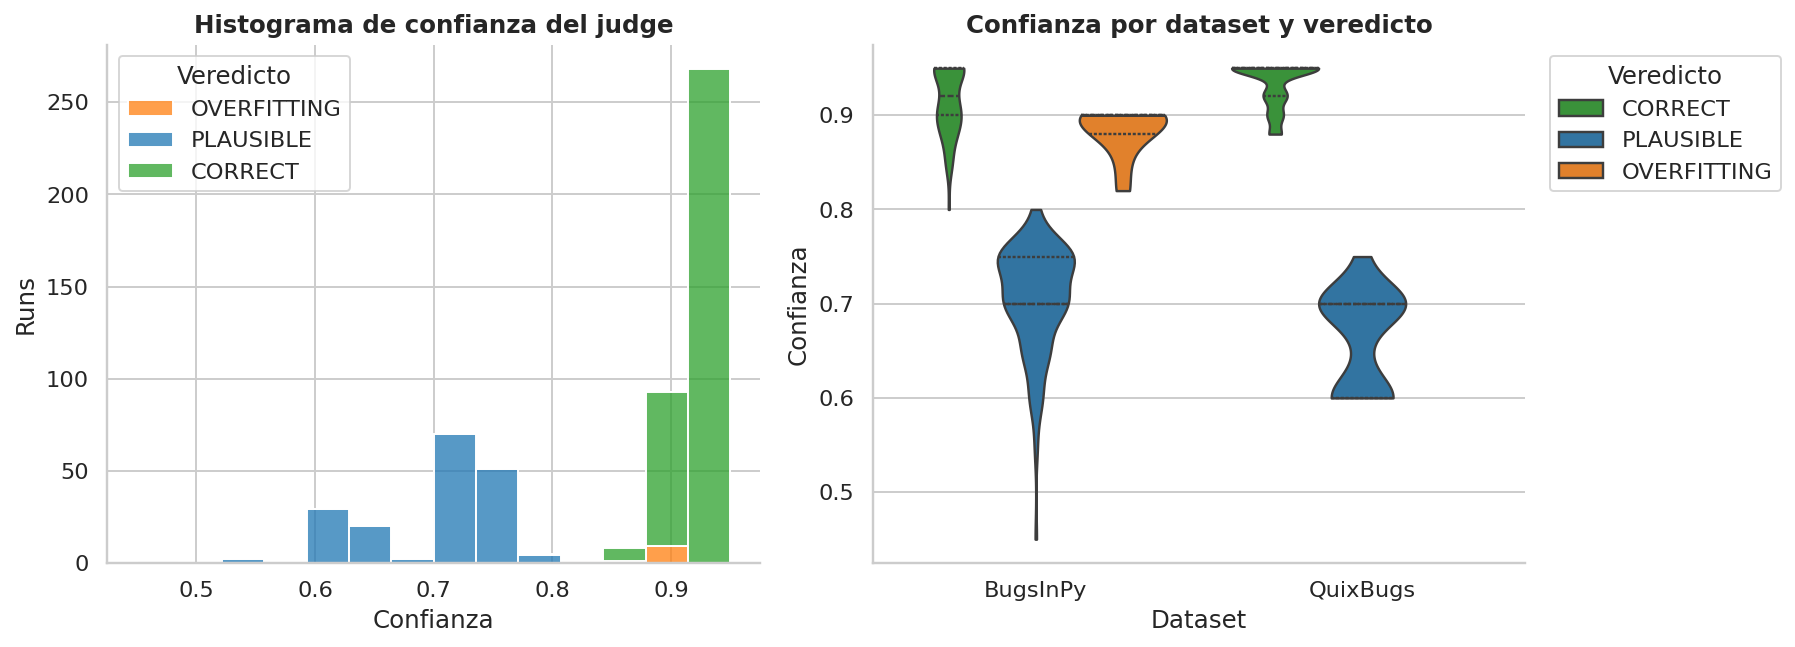

Casos de menor confianza del judge entre veredictos semanticos:


,dataset_label,problem_id,project,model_label,arch_label,tests_pass,verdict_clean,confidence,duration_min,tokens_k,stop_reason,batch_id,justification
296,BugsInPy,thefuck-15,thefuck,Qwen3.5 9B,Orchestrator,True,PLAUSIBLE,0.45,7.103207,631.466,completed,batch-experiment-bugsinpy-multi-agent-orchestrator-qwen3.5-9b-thefuck-20260526T193747Z,"Agent fixed missing psutil dependency AND modified git_add.py match logic (removed second condition check). While tests pass, the canoni..."
140,BugsInPy,thefuck-18,thefuck,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.55,3.424294,443.997,completed,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-thefuck-20260526T191756Z,The generated patch only fixes whitespace/line continuation formatting. The canonical patch adds critical logic to prevent the sudo rule...
463,BugsInPy,tqdm-1,tqdm,Qwen3.5 9B,Planner-Executor,True,PLAUSIBLE,0.55,9.750929,812.766,completed,batch-experiment-bugsinpy-planner-executor-qwen3.5-9b-tqdm-20260526T225300Z,"Generated patch attempts to fix the start parameter issue but uses overly complex logic with bugs (uses desc=start incorrectly, has trun..."
561,QuixBugs,kheapsort,QuixBugs,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,0.593284,44.700,completed,batch-experiment-quixbugs-mono-agent-qwen3.5-9b-extra20-20260528T202703Z,"Tests pass with exit_code=0. Agent fixed kheapsort heap logic. Cannot verify semantic equivalence to canonical patch (workspace cleaned,..."
560,QuixBugs,get_factors,QuixBugs,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,0.560577,55.633,completed,batch-experiment-quixbugs-mono-agent-qwen3.5-9b-extra20-20260528T202703Z,Tests pass with exit_code=0. Agent fixed get_factors termination logic. Cannot verify semantic equivalence to canonical patch (workspace...
559,QuixBugs,flatten,QuixBugs,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,0.344362,39.618,completed,batch-experiment-quixbugs-mono-agent-qwen3.5-9b-extra20-20260528T202703Z,Tests pass with exit_code=0. Agent fixed flatten generator recursion. Cannot verify semantic equivalence to canonical patch (workspace c...
558,QuixBugs,find_first_in_sorted,QuixBugs,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,3.315049,50.083,completed,batch-experiment-quixbugs-mono-agent-qwen3.5-9b-extra20-20260528T202703Z,Tests pass with exit_code=0. Agent used replace_in_file for surgical fix in find_first_in_sorted.py. Cannot verify semantic equivalence ...
99,BugsInPy,tqdm-9,tqdm,GPT-5.4 mini,Mono-agent,True,PLAUSIBLE,0.60,0.696591,185.931,completed,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-tqdm-20260526T201719Z,"The agent addressed two issues: format_sizeof precision and __len__ handling None iterable. For format_sizeof, the canonical fix adjusts..."
117,BugsInPy,black-19,black,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,5.987122,499.210,completed,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-black-20260525T153125Z,"Agent modified is_decorator to treat STANDALONE_COMMENT as decorator, making test pass. Canonical fix adds spacing logic in EmptyLineTra..."
570,QuixBugs,reverse_linked_list,QuixBugs,Qwen3.5 9B,Mono-agent,True,PLAUSIBLE,0.60,0.379497,36.661,completed,batch-experiment-quixbugs-mono-agent-qwen3.5-9b-extra20-20260528T202703Z,Tests pass with exit_code=0. Agent fixed reverse_linked_list pointer manipulation. Cannot verify semantic equivalence to canonical patch...


In [17]:
conf = analysis_runs[analysis_runs['confidence'].notna() & analysis_runs['verdict_clean'].astype(str).isin(SEMANTIC_VERDICT_ORDER)].copy()
conf['veredicto'] = conf['verdict_clean'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(
    data=conf,
    x='confidence',
    hue='veredicto',
    hue_order=SEMANTIC_VERDICT_ORDER,
    bins=14,
    multiple='stack',
    palette=VERDICT_COLORS,
    ax=axes[0],
)
axes[0].set_title('Histograma de confianza del judge')
axes[0].set_xlabel('Confianza')
axes[0].set_ylabel('Runs')
axes[0].legend(title='Veredicto', labels=list(reversed(SEMANTIC_VERDICT_ORDER)))

sns.violinplot(
    data=conf,
    x='dataset_label',
    y='confidence',
    hue='veredicto',
    hue_order=SEMANTIC_VERDICT_ORDER,
    palette=VERDICT_COLORS,
    cut=0,
    inner='quartile',
    ax=axes[1],
)
axes[1].set_title('Confianza por dataset y veredicto')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Confianza')
axes[1].legend(title='Veredicto', bbox_to_anchor=(1.02, 1), loc='upper left')
for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_judge_confidence_distribution')
plt.show()

low_conf = conf.sort_values('confidence').head(25)[case_cols]
print('Casos de menor confianza del judge entre veredictos semanticos:')
display(low_conf)

## 17. Analizar fallos de ejecucion del agente

No todos los fallos de ejecucion significan lo mismo. Un `max_iterations` apunta a no convergencia del agente, un `timed_out` mide coste o bloqueo durante la reparacion, y un `validation_failure` se interpreta aqui como fallo de ejecucion porque el sistema detecto un parche producido por el agente que no debia aceptar. Esta seccion se limita a fallos observados durante la reparacion.


,dataset_label,model_label,arch_label,final_status,stop_reason,runs
7,BugsInPy,GPT-5.4 mini,Planner-Executor,failed,max_iterations,24
1,BugsInPy,GPT-5.4 mini,Mono-agent,failed,max_iterations,22
30,BugsInPy,Qwen3.5 9B,Planner-Executor,failed,max_iterations,21
26,BugsInPy,Qwen3.5 9B,Orchestrator,failed,max_iterations,18
16,BugsInPy,Gemma4 26B,Orchestrator,timed_out,timed_out,17
21,BugsInPy,Qwen3.5 9B,Mono-agent,failed,max_iterations,17
4,BugsInPy,GPT-5.4 mini,Orchestrator,failed,max_iterations,16
9,BugsInPy,Gemma4 26B,Mono-agent,failed,max_iterations,16
18,BugsInPy,Gemma4 26B,Planner-Executor,failed,max_iterations,16
12,BugsInPy,Gemma4 26B,Mono-agent,timed_out,timed_out,14


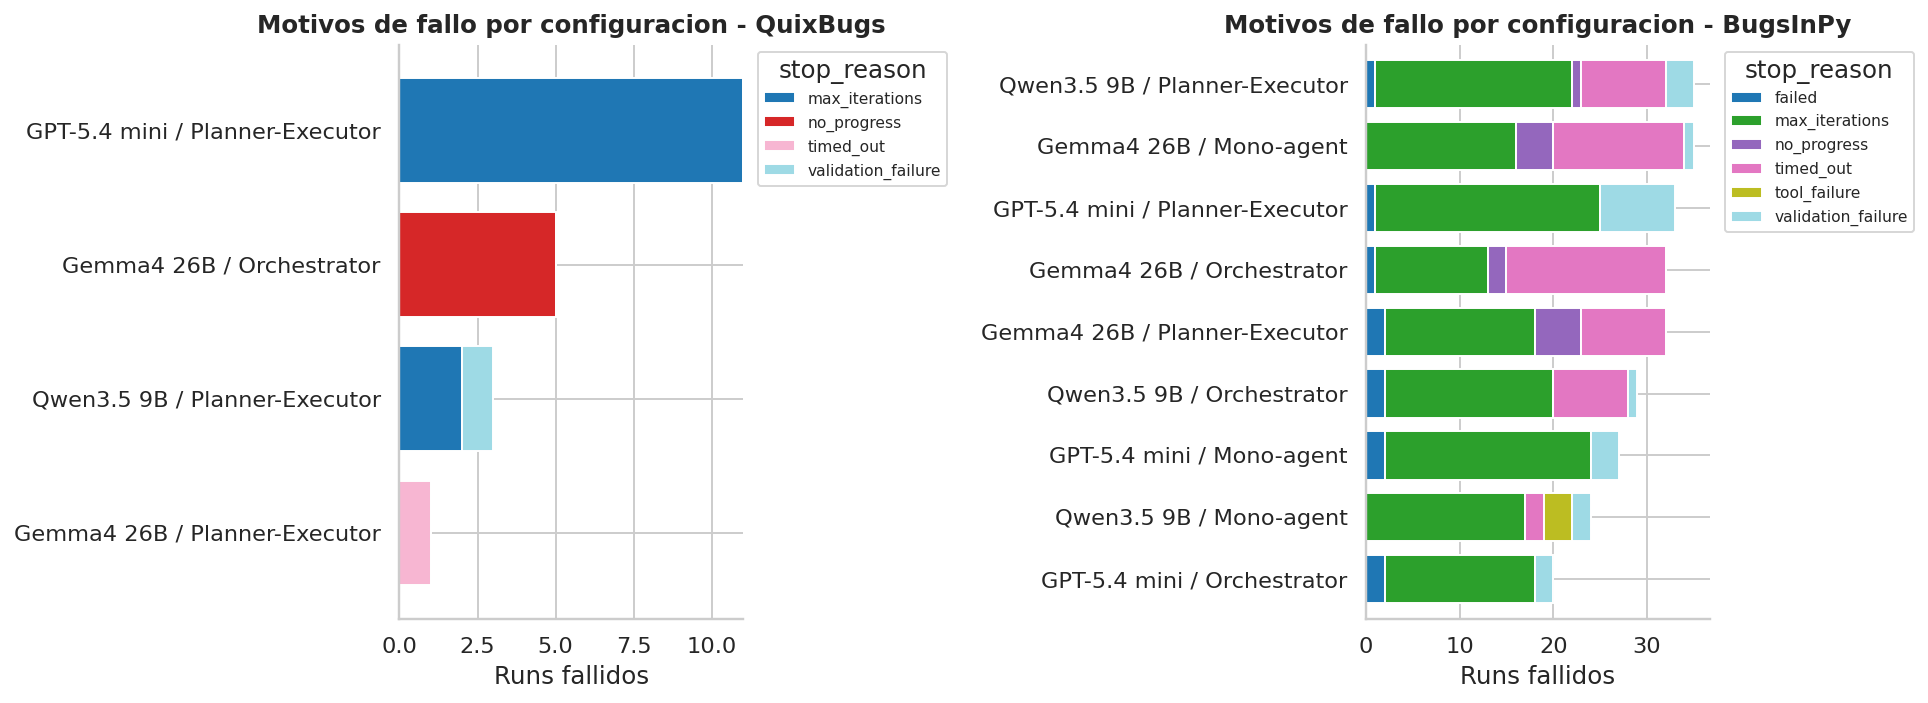

Runs con error registrado: 24


,dataset_label,problem_id,model_label,arch_label,final_status,stop_reason,error_type,error_category,error_message
12,BugsInPy,black-19,Gemma4 26B,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
76,BugsInPy,luigi-11,GPT-5.4 mini,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
84,BugsInPy,scrapy-25,GPT-5.4 mini,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
96,BugsInPy,tqdm-2,GPT-5.4 mini,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
105,BugsInPy,PySnooper-1,Qwen3.5 9B,Mono-agent,failed,tool_failure,ProviderExecutionError,model,ProviderExecutionError: provider execution failed: provider call failed after 6 attempt(s): retryable=True status_code=500 error=Interna...
106,BugsInPy,PySnooper-2,Qwen3.5 9B,Mono-agent,failed,tool_failure,ProviderExecutionError,model,ProviderExecutionError: provider execution failed: provider call failed after 6 attempt(s): retryable=True status_code=500 error=Interna...
107,BugsInPy,PySnooper-3,Qwen3.5 9B,Mono-agent,failed,tool_failure,ProviderExecutionError,model,ProviderExecutionError: provider execution failed: provider call failed after 6 attempt(s): retryable=True status_code=500 error=Interna...
116,BugsInPy,black-13,Qwen3.5 9B,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
149,BugsInPy,tqdm-2,Qwen3.5 9B,Mono-agent,failed,validation_failure,Unknown,validation,Diff integrity validation failed
220,BugsInPy,black-10,GPT-5.4 mini,Orchestrator,failed,validation_failure,Unknown,validation,Diff integrity validation failed


In [18]:
failure_df = analysis_runs[~analysis_runs['tests_pass']].copy()
failure_summary = (
    failure_df.groupby(['dataset_label', 'model_label', 'arch_label', 'final_status', 'stop_reason'], observed=True)
    .size().reset_index(name='runs')
)
display(failure_summary.sort_values(['dataset_label', 'runs'], ascending=[True, False]).head(40))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=False)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = failure_df[failure_df['dataset_label'].eq(dataset)].copy()
    if data.empty:
        ax.set_title(f'Sin fallos - {dataset}')
        continue
    tab = pd.crosstab(data['config'], data['stop_reason']).loc[lambda x: x.sum(axis=1).sort_values(ascending=True).index]
    tab.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.78)
    ax.set_title(f'Motivos de fallo por configuracion - {dataset}')
    ax.set_xlabel('Runs fallidos')
    ax.set_ylabel('')
    ax.legend(title='stop_reason', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_failure_modes_by_config')
plt.show()

error_table = analysis_runs[(analysis_runs['error_type'].notna()) | (analysis_runs['error_category'].notna())][['dataset_label', 'problem_id', 'model_label', 'arch_label', 'final_status', 'stop_reason', 'error_type', 'error_category', 'error_message']]
print(f'Runs con error registrado: {len(error_table)}')
display(error_table.head(30))

## 18. Detectar outliers y decidir exclusiones justificadas

Los outliers se etiquetan, no se eliminan. El criterio por defecto marca el percentil 99 de duracion y tokens, y permite ver si las conclusiones cambian al excluir casos extremos o ejecuciones incompletas.

P99 tokens=1371.6k; P99 duracion=903.6s; outliers marcados=18


,dataset_label,problem_id,project,model_label,arch_label,final_status,stop_reason,tests_pass,verdict_clean,tokens_k,duration_seconds,total_iterations,batch_id
143,BugsInPy,tornado-2,tornado,Qwen3.5 9B,Mono-agent,failed,max_iterations,False,FAIL,1627.65,742.70,3.0,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-tornado-20260526T203329Z
118,BugsInPy,fastapi-3,fastapi,Qwen3.5 9B,Mono-agent,failed,max_iterations,False,FAIL,1576.16,707.06,3.0,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-fastapi-20260525T181953Z
115,BugsInPy,black-10,black,Qwen3.5 9B,Mono-agent,failed,max_iterations,False,FAIL,1551.10,644.36,3.0,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-black-20260525T153125Z
460,BugsInPy,tornado-7,tornado,Qwen3.5 9B,Planner-Executor,failed,max_iterations,False,FAIL,1531.72,635.86,3.0,batch-experiment-bugsinpy-planner-executor-qwen3.5-9b-tornado-20260526T212231Z
280,BugsInPy,fastapi-14,fastapi,Qwen3.5 9B,Orchestrator,failed,max_iterations,False,FAIL,1528.34,681.60,3.0,batch-experiment-bugsinpy-multi-agent-orchestrator-qwen3.5-9b-fastapi-20260526T105626Z
424,BugsInPy,ansible-3,ansible,Qwen3.5 9B,Planner-Executor,failed,max_iterations,False,FAIL,1503.55,659.01,3.0,batch-experiment-bugsinpy-planner-executor-qwen3.5-9b-ansible-20260525T140921Z
425,BugsInPy,ansible-9,ansible,Qwen3.5 9B,Planner-Executor,success,completed,True,PLAUSIBLE,1450.50,555.88,3.0,batch-experiment-bugsinpy-planner-executor-qwen3.5-9b-ansible-20260525T140921Z
267,BugsInPy,ansible-3,ansible,Qwen3.5 9B,Orchestrator,failed,max_iterations,False,FAIL,1430.84,547.75,3.0,batch-experiment-bugsinpy-multi-agent-orchestrator-qwen3.5-9b-ansible-20260525T131540Z
120,BugsInPy,fastapi-5,fastapi,Qwen3.5 9B,Mono-agent,failed,max_iterations,False,FAIL,1373.09,513.34,3.0,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-fastapi-20260525T181953Z
161,BugsInPy,ansible-1,ansible,Gemma4 26B,Orchestrator,failed,max_iterations,False,FAIL,753.29,1240.47,3.0,batch-experiment-bugsinpy-multi-agent-orchestrator-gemma4-26b-ansible-20260524T095555Z


,dataset_label,model_label,arch_label,runs,runs_clean,correct_rate,correct_rate_clean,delta_correct_rate,avg_tokens_k,avg_tokens_k_clean
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,53,9.43,9.43,0.00,289.97,289.97
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,53,22.64,22.64,0.00,225.79,225.79
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,53,7.55,7.55,0.00,215.72,215.72
3,BugsInPy,Gemma4 26B,Mono-agent,53,50,11.32,12.00,0.68,196.21,186.26
4,BugsInPy,Gemma4 26B,Orchestrator,53,49,22.64,24.49,1.85,195.25,176.82
5,BugsInPy,Gemma4 26B,Planner-Executor,53,51,18.87,19.61,0.74,270.20,264.68
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,49,15.09,16.33,1.23,686.17,617.13
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,51,20.75,21.57,0.81,676.65,644.53
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,50,11.32,12.00,0.68,706.93,659.63
9,QuixBugs,GPT-5.4 mini,Mono-agent,40,40,97.50,97.50,0.00,30.95,30.95


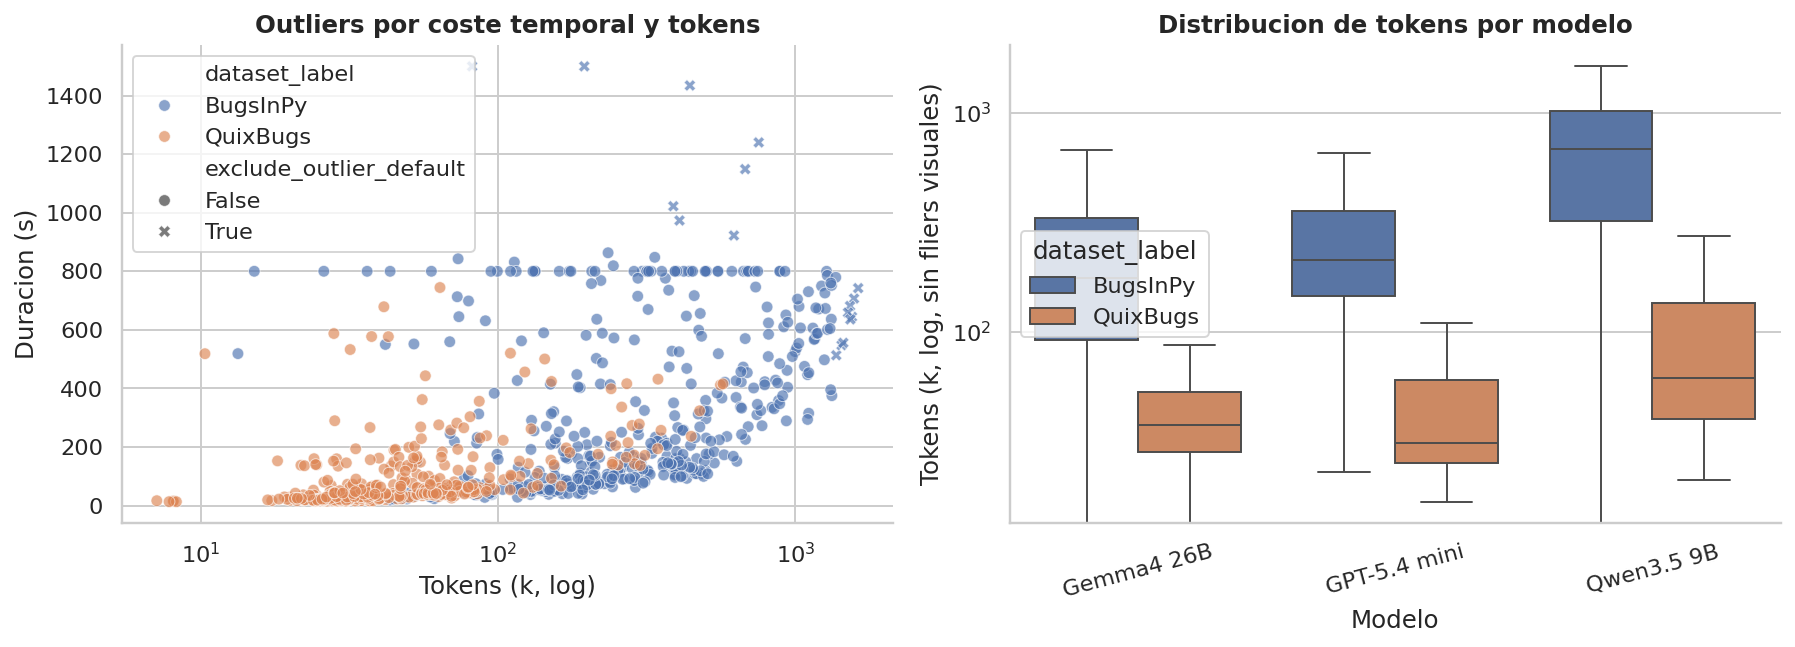

In [19]:
token_p99 = analysis_runs['tokens_k'].quantile(0.99)
duration_p99 = analysis_runs['duration_seconds'].quantile(0.99)
analysis_runs['exclude_outlier_default'] = (analysis_runs['tokens_k'] > token_p99) | (analysis_runs['duration_seconds'] > duration_p99)

outliers = analysis_runs[analysis_runs['exclude_outlier_default']].sort_values(['tokens_k', 'duration_seconds'], ascending=False)
outlier_cols = ['dataset_label', 'problem_id', 'project', 'model_label', 'arch_label', 'final_status', 'stop_reason', 'tests_pass', 'verdict_clean', 'tokens_k', 'duration_seconds', 'total_iterations', 'batch_id']
print(f'P99 tokens={token_p99:.1f}k; P99 duracion={duration_p99:.1f}s; outliers marcados={len(outliers)}')
display(outliers[outlier_cols].round(2))

clean_runs = analysis_runs[~analysis_runs['exclude_outlier_default']].copy()
summary_clean = (
    clean_runs.groupby(['dataset_label', 'model_label', 'arch_label'], observed=True)
    .agg(runs=('run_id', 'count'), tests_passed=('tests_pass', 'sum'), correct=('judge_correct', 'sum'), avg_tokens_k=('tokens_k', 'mean'), avg_seconds=('duration_seconds', 'mean'))
    .reset_index()
)
summary_clean['test_pass_rate_clean'] = summary_clean.apply(lambda r: pct(r['tests_passed'], r['runs']), axis=1)
summary_clean['correct_rate_clean'] = summary_clean.apply(lambda r: pct(r['correct'], r['runs']), axis=1)
compare_outlier = summary_cfg.merge(summary_clean, on=['dataset_label', 'model_label', 'arch_label'], suffixes=('', '_clean'))
compare_outlier['delta_correct_rate'] = compare_outlier['correct_rate_clean'] - compare_outlier['correct_rate']
display(compare_outlier[['dataset_label', 'model_label', 'arch_label', 'runs', 'runs_clean', 'correct_rate', 'correct_rate_clean', 'delta_correct_rate', 'avg_tokens_k', 'avg_tokens_k_clean']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(data=analysis_runs, x='tokens_k', y='duration_seconds', hue='dataset_label', style='exclude_outlier_default', alpha=0.65, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_xlabel('Tokens (k, log)')
axes[0].set_ylabel('Duracion (s)')
axes[0].set_title('Outliers por coste temporal y tokens')
sns.boxplot(data=analysis_runs, x='model_label', y='tokens_k', hue='dataset_label', showfliers=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Tokens (k, log, sin fliers visuales)')
axes[1].set_title('Distribucion de tokens por modelo')
axes[1].tick_params(axis='x', rotation=15)
for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_outlier_diagnostics')
plt.show()

## 19. Analizar coste temporal y eficiencia experimental

Ademas de saber que configuracion repara mas, interesa saber cuanto cuesta llegar a cada fix correcto. En modelos locales el tiempo pesa mas; en modelos de API el consumo de tokens y el coste economico potencial pesan mas.

,dataset_label,model_label,arch_label,runs,test_pass_rate,correct_rate,semantic_precision_on_pass,avg_tokens_k,correct_per_million_tokens
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,62.26,22.64,36.36,225.79,1.00
4,BugsInPy,Gemma4 26B,Orchestrator,53,39.62,22.64,57.14,195.25,1.16
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,45.28,20.75,45.83,676.65,0.31
5,BugsInPy,Gemma4 26B,Planner-Executor,53,39.62,18.87,47.62,270.20,0.70
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,54.72,15.09,27.59,686.17,0.22
3,BugsInPy,Gemma4 26B,Mono-agent,53,33.96,11.32,33.33,196.21,0.58
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,33.96,11.32,33.33,706.93,0.16
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,49.06,9.43,19.23,289.97,0.33
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,37.74,7.55,20.00,215.72,0.35
10,QuixBugs,GPT-5.4 mini,Orchestrator,40,100.00,100.00,100.00,25.70,38.91


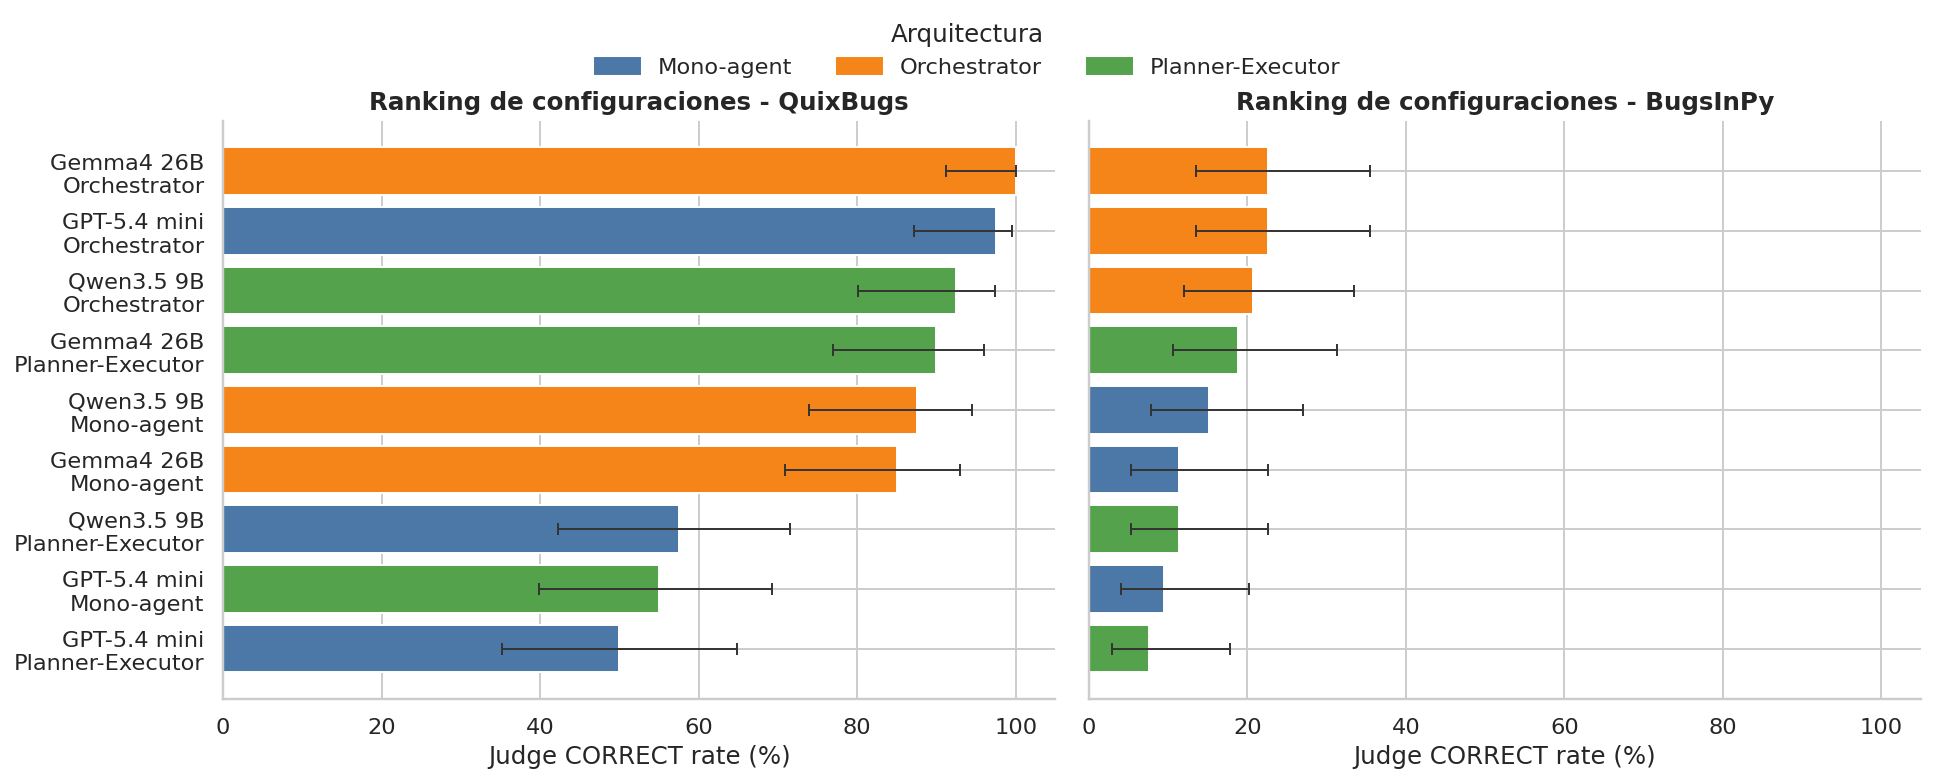

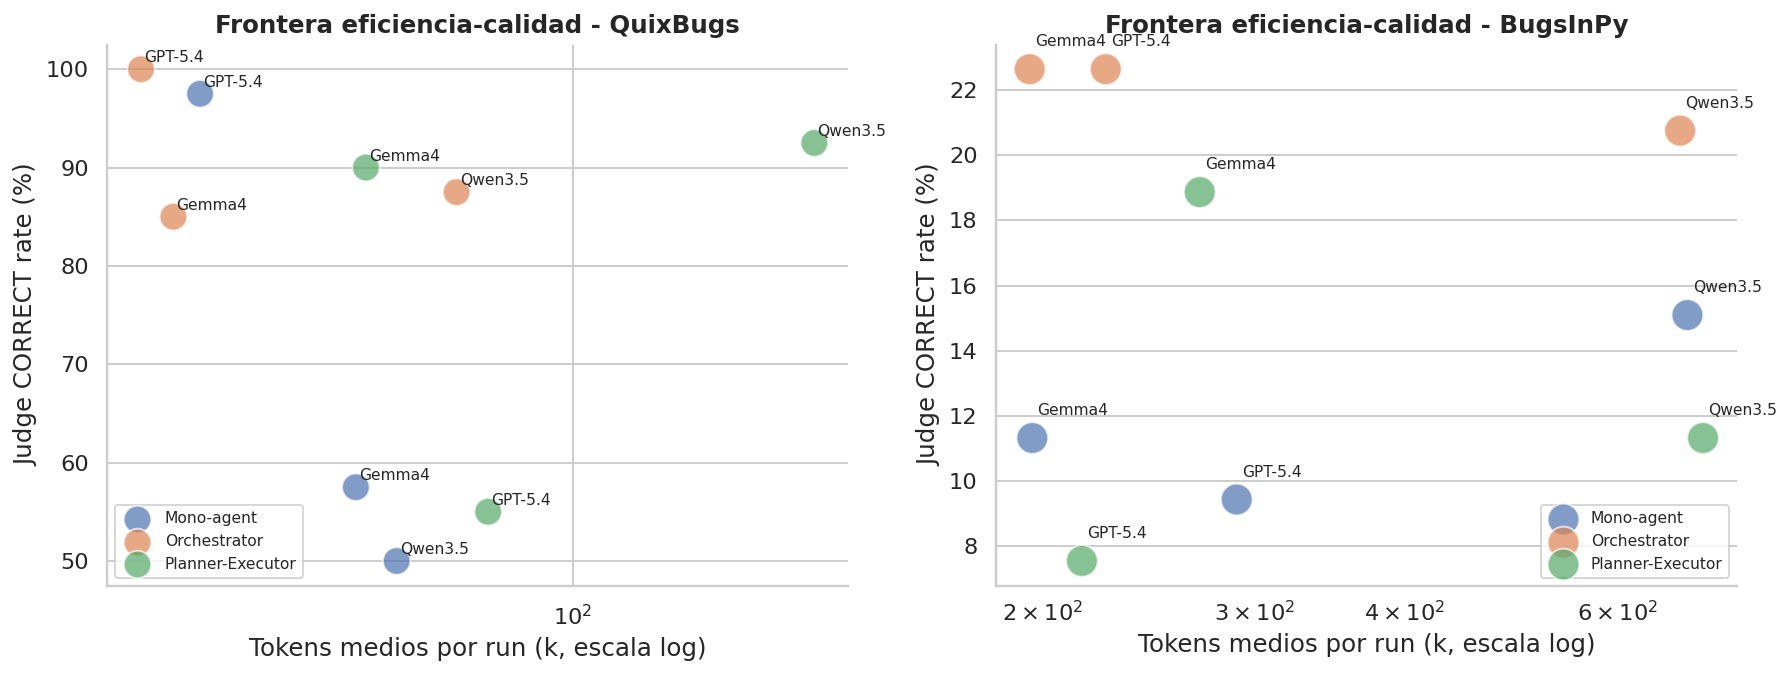

In [20]:
rank_cfg = summary_cfg.sort_values(['dataset_label', 'correct_rate', 'test_pass_rate'], ascending=[True, False, False]).copy()
rank_cfg['label'] = rank_cfg['model_label'] + '\n' + rank_cfg['arch_label']

display(rank_cfg[['dataset_label', 'model_label', 'arch_label', 'runs', 'test_pass_rate', 'correct_rate', 'semantic_precision_on_pass', 'avg_tokens_k', 'correct_per_million_tokens']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = rank_cfg[rank_cfg['dataset_label'].eq(dataset)].sort_values('correct_rate')
    y = np.arange(len(data))
    x = data['correct_rate'].to_numpy()
    low = x - data['correct_ci_low'].to_numpy()
    high = data['correct_ci_high'].to_numpy() - x
    ax.barh(y, x, color=[ARCH_COLORS.get(str(a), '#777') for a in data['architecture']], edgecolor='white')
    ax.errorbar(x, y, xerr=[low, high], fmt='none', ecolor='#333333', capsize=3, linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(data['label'])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Judge CORRECT rate (%)')
    ax.set_title(f'Ranking de configuraciones - {dataset}')
    sns.despine(ax=ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in ARCH_ORDER]
labels = [ARCH_LABELS[a] for a in ARCH_ORDER]
fig.legend(handles, labels, title='Arquitectura', ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.95))
savefig('final_configuration_correct_ranking')
plt.show()

frontier = rank_cfg.copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = frontier[frontier['dataset_label'].eq(dataset)]
    for arch in [ARCH_LABELS[a] for a in ARCH_ORDER]:
        sub = data[data['arch_label'].eq(arch)]
        ax.scatter(sub['avg_tokens_k'], sub['correct_rate'], s=sub['runs'] * 5, alpha=0.7, label=arch, edgecolor='white')
        for _, row in sub.iterrows():
            ax.text(row['avg_tokens_k'] * 1.01, row['correct_rate'] + 0.7, row['model_label'].split()[0], fontsize=8)
    ax.set_xscale('log')
    ax.set_xlabel('Tokens medios por run (k, escala log)')
    ax.set_ylabel('Judge CORRECT rate (%)')
    ax.set_title(f'Frontera eficiencia-calidad - {dataset}')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_efficiency_quality_frontier')
plt.show()

## 20. Explorar estabilidad, varianza e incertidumbre

No hay repeticiones identicas masivas por configuracion y bug, asi que la incertidumbre se estima sobre el conjunto de bugs observados mediante bootstrap. Esto da una lectura prudente de diferencias entre modelos y arquitecturas.

,dataset_label,model_label,arch_label,runs,test_pass_rate,test_pass_ci_low,test_pass_ci_high,correct_rate,correct_ci_low_boot,correct_ci_high_boot,std_tokens_k,std_duration_s
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,49.06,35.85,62.26,9.43,1.89,18.87,167.44,58.61
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,62.26,49.06,75.47,22.64,11.32,33.96,139.01,56.09
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,37.74,24.53,50.94,7.55,1.89,15.09,84.63,33.47
3,BugsInPy,Gemma4 26B,Mono-agent,53,33.96,20.75,47.17,11.32,3.77,20.75,163.08,296.38
4,BugsInPy,Gemma4 26B,Orchestrator,53,39.62,26.42,52.83,22.64,11.32,33.96,175.09,343.95
5,BugsInPy,Gemma4 26B,Planner-Executor,53,39.62,26.42,52.83,18.87,9.43,30.19,178.15,300.89
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,54.72,41.51,67.92,15.09,5.66,24.53,480.75,224.90
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,45.28,32.08,58.49,20.75,11.32,32.08,418.48,261.83
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,33.96,22.64,47.17,11.32,3.77,20.75,387.18,224.75
9,QuixBugs,GPT-5.4 mini,Mono-agent,40,100.00,100.00,100.00,97.50,92.50,100.00,6.10,31.94


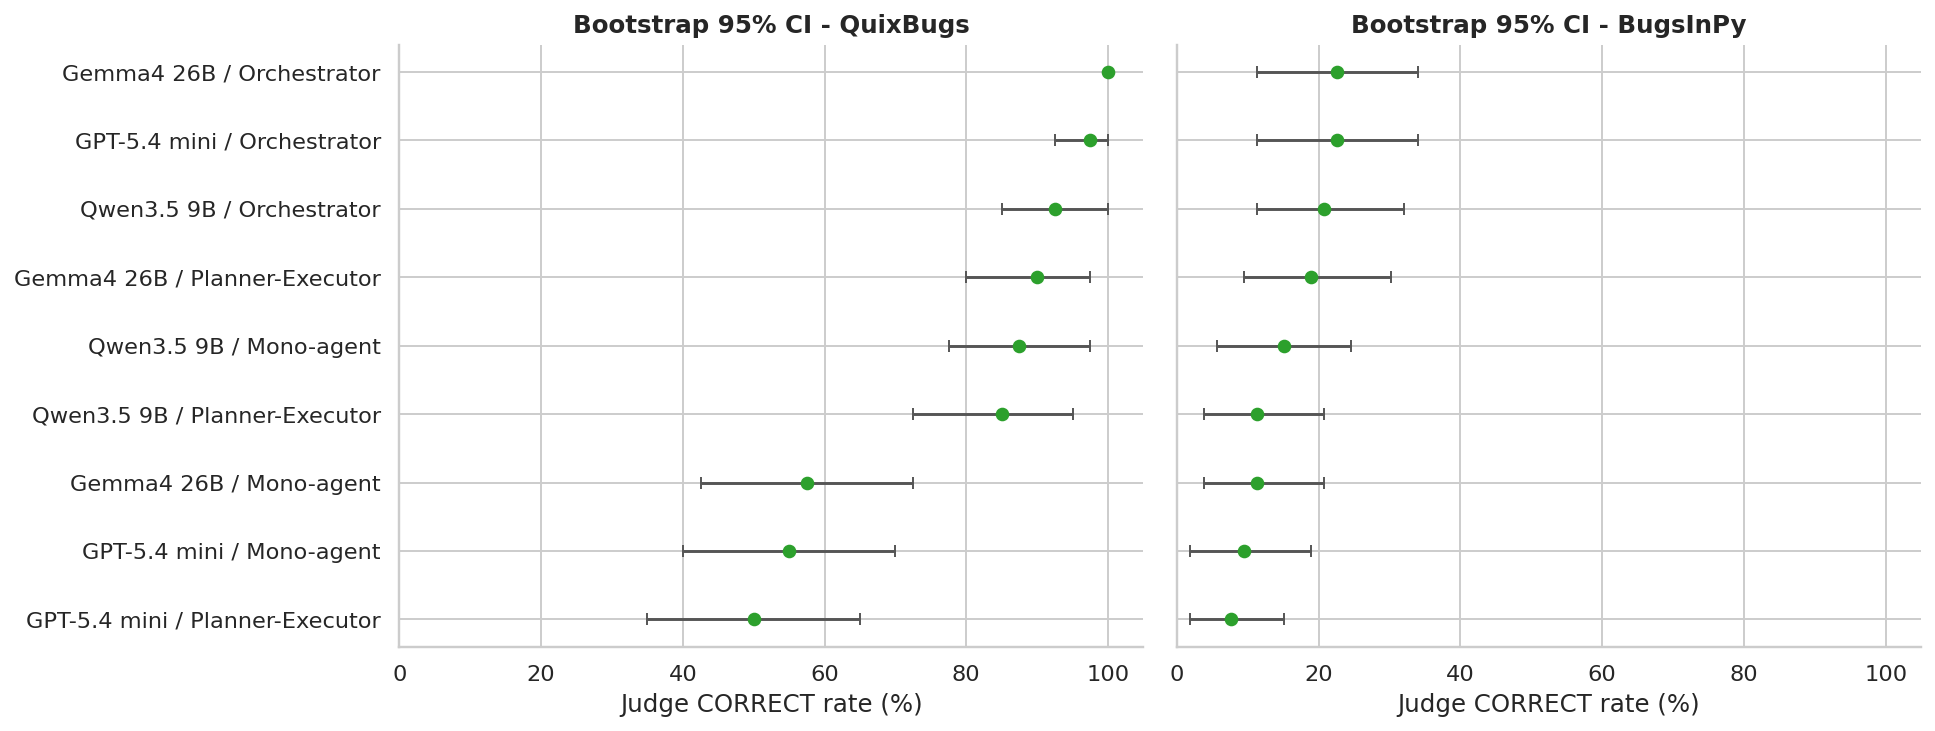

In [21]:
uncertainty_rows = []
for keys, group in analysis_runs.groupby(['dataset_label', 'model_label', 'arch_label'], observed=True):
    pass_low, pass_high = bootstrap_rate_ci(group['tests_pass'].astype(int).values)
    corr_low, corr_high = bootstrap_rate_ci(group['judge_correct'].astype(int).values)
    uncertainty_rows.append({
        'dataset_label': keys[0],
        'model_label': keys[1],
        'arch_label': keys[2],
        'runs': len(group),
        'test_pass_rate': group['tests_pass'].mean() * 100,
        'test_pass_ci_low': pass_low,
        'test_pass_ci_high': pass_high,
        'correct_rate': group['judge_correct'].mean() * 100,
        'correct_ci_low_boot': corr_low,
        'correct_ci_high_boot': corr_high,
        'std_tokens_k': group['tokens_k'].std(),
        'std_duration_s': group['duration_seconds'].std(),
    })
uncertainty = pd.DataFrame(uncertainty_rows)
display(uncertainty.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)
for ax, dataset in zip(axes, ['QuixBugs', 'BugsInPy']):
    data = uncertainty[uncertainty['dataset_label'].eq(dataset)].sort_values('correct_rate')
    y = np.arange(len(data))
    x = data['correct_rate'].to_numpy()
    low = x - data['correct_ci_low_boot'].to_numpy()
    high = data['correct_ci_high_boot'].to_numpy() - x
    ax.errorbar(x, y, xerr=[low, high], fmt='o', color='#2CA02C', ecolor='#555555', capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(data['model_label'] + ' / ' + data['arch_label'])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Judge CORRECT rate (%)')
    ax.set_title(f'Bootstrap 95% CI - {dataset}')
    sns.despine(ax=ax)
plt.tight_layout()
savefig('final_correct_rate_bootstrap_ci')
plt.show()

## 21. Construir rankings y tablas comparativas

Las tablas siguientes son candidatas directas para la memoria: resumen por configuracion, resumen por dataset y ranking de eficiencia. Se generan en formato tabular simple para poder copiarlas a LaTeX o transformarlas despues.

,dataset_label,model_label,arch_label,runs,tests_passed,test_pass_rate,correct,correct_rate,plausible,overfitting,semantic_precision_on_pass,avg_tokens_k,avg_seconds,correct_per_million_tokens,config
1,BugsInPy,GPT-5.4 mini,Orchestrator,53,33,62.26,12,22.64,20,1,36.36,225.79,96.33,1.00,GPT-5.4 mini / Orchestrator
4,BugsInPy,Gemma4 26B,Orchestrator,53,21,39.62,12,22.64,8,1,57.14,195.25,572.82,1.16,Gemma4 26B / Orchestrator
7,BugsInPy,Qwen3.5 9B,Orchestrator,53,24,45.28,11,20.75,13,0,45.83,676.65,452.20,0.31,Qwen3.5 9B / Orchestrator
5,BugsInPy,Gemma4 26B,Planner-Executor,53,21,39.62,10,18.87,10,1,47.62,270.20,459.29,0.70,Gemma4 26B / Planner-Executor
6,BugsInPy,Qwen3.5 9B,Mono-agent,53,29,54.72,8,15.09,21,0,27.59,686.17,334.92,0.22,Qwen3.5 9B / Mono-agent
3,BugsInPy,Gemma4 26B,Mono-agent,53,18,33.96,6,11.32,11,1,33.33,196.21,554.36,0.58,Gemma4 26B / Mono-agent
8,BugsInPy,Qwen3.5 9B,Planner-Executor,53,18,33.96,6,11.32,11,1,33.33,706.93,497.59,0.16,Qwen3.5 9B / Planner-Executor
0,BugsInPy,GPT-5.4 mini,Mono-agent,53,26,49.06,5,9.43,20,1,19.23,289.97,92.48,0.33,GPT-5.4 mini / Mono-agent
2,BugsInPy,GPT-5.4 mini,Planner-Executor,53,20,37.74,4,7.55,11,5,20.00,215.72,84.57,0.35,GPT-5.4 mini / Planner-Executor
10,QuixBugs,GPT-5.4 mini,Orchestrator,40,40,100.00,40,100.00,0,0,100.00,25.70,30.51,38.91,GPT-5.4 mini / Orchestrator


,criterio,dataset_label,model_label,arch_label,test_pass_rate,correct_rate,correct_per_million_tokens,avg_tokens_k,avg_seconds
0,max_correct_rate,BugsInPy,GPT-5.4 mini,Orchestrator,62.26,22.64,1.00,225.79,96.33
1,max_correct_rate,QuixBugs,GPT-5.4 mini,Orchestrator,100.00,100.00,38.91,25.70,30.51
2,max_correct_per_million_tokens,BugsInPy,Gemma4 26B,Orchestrator,39.62,22.64,1.16,195.25,572.82
3,max_correct_per_million_tokens,QuixBugs,GPT-5.4 mini,Orchestrator,100.00,100.00,38.91,25.70,30.51


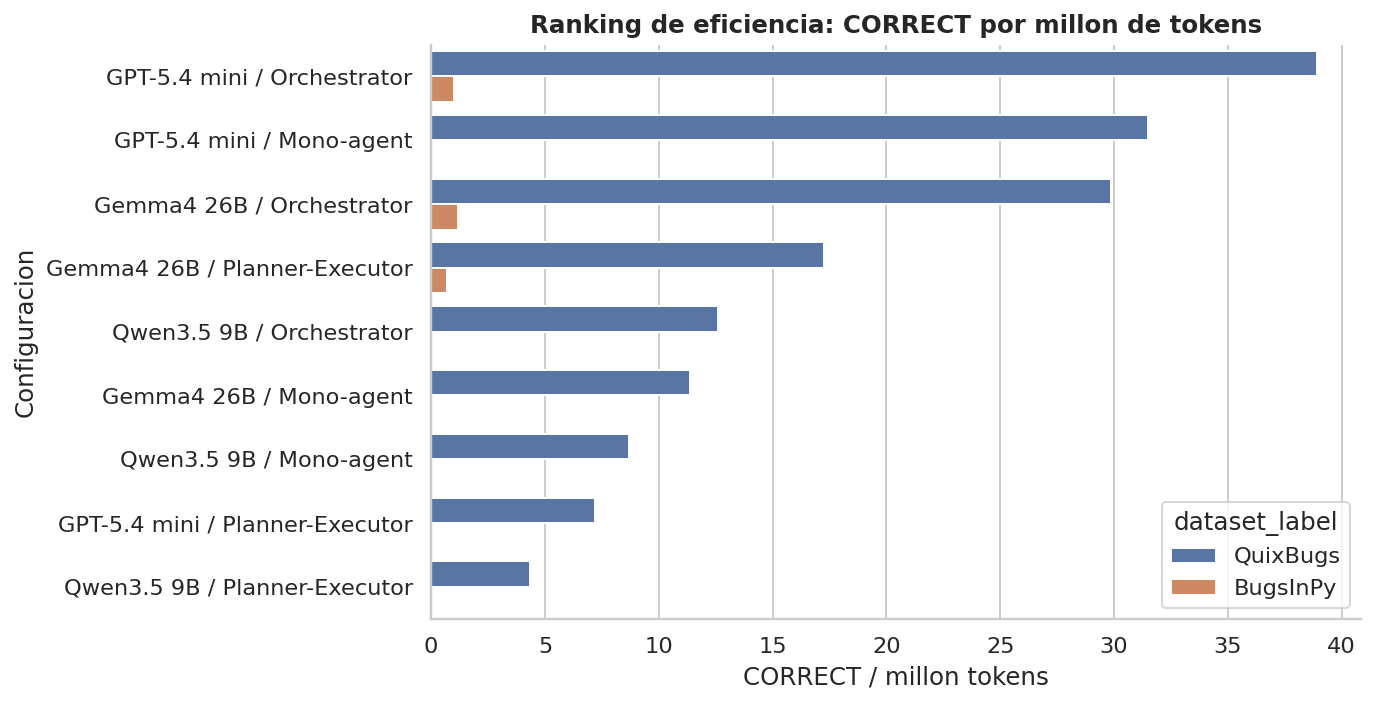

In [22]:
memo_table = rank_cfg[[
    'dataset_label', 'model_label', 'arch_label', 'runs', 'tests_passed', 'test_pass_rate',
    'correct', 'correct_rate', 'plausible', 'overfitting', 'semantic_precision_on_pass',
    'avg_tokens_k', 'avg_seconds', 'correct_per_million_tokens'
]].copy()
memo_table['config'] = memo_table['model_label'] + ' / ' + memo_table['arch_label']
memo_table = memo_table.sort_values(['dataset_label', 'correct_rate', 'test_pass_rate'], ascending=[True, False, False])
display(memo_table.round(2))

best_by_dataset = memo_table.loc[memo_table.groupby('dataset_label')['correct_rate'].idxmax()].copy()
most_efficient = memo_table.loc[memo_table.groupby('dataset_label')['correct_per_million_tokens'].idxmax()].copy()
comparison_cards = pd.concat([
    best_by_dataset.assign(criterio='max_correct_rate'),
    most_efficient.assign(criterio='max_correct_per_million_tokens'),
], ignore_index=True)
display(comparison_cards[['criterio', 'dataset_label', 'model_label', 'arch_label', 'test_pass_rate', 'correct_rate', 'correct_per_million_tokens', 'avg_tokens_k', 'avg_seconds']].round(2))

fig, ax = plt.subplots(figsize=(10, 5.2))
eff_rank = memo_table.sort_values('correct_per_million_tokens', ascending=False).head(12)
sns.barplot(data=eff_rank, y='config', x='correct_per_million_tokens', hue='dataset_label', ax=ax)
ax.set_title('Ranking de eficiencia: CORRECT por millon de tokens')
ax.set_xlabel('CORRECT / millon tokens')
ax.set_ylabel('Configuracion')
sns.despine(ax=ax)
plt.tight_layout()
savefig('final_efficiency_ranking')
plt.show()

## 22. Seleccionar casos representativos para storytelling

La memoria necesitara ejemplos concretos, no solo porcentajes. Esta celda selecciona automaticamente casos que cuentan historias distintas: exito claro, plausible, overfitting, fallo duro, problema dificil y outlier de coste.

In [23]:
case_catalog = []

def pick_case(label, mask, sort_cols=None, ascending=True):
    subset = analysis_df[mask].copy()
    if subset.empty:
        return
    if sort_cols:
        subset = subset.sort_values(sort_cols, ascending=ascending)
    row = subset.iloc[0].copy()
    row['tipo_storytelling'] = label
    case_catalog.append(row)

pick_case('exito_claro_alta_confianza', analysis_df['judge_correct'] & analysis_df['confidence'].notna(), ['confidence'], False)
pick_case('tests_pasan_pero_plausible', analysis_df['disagreement_type'].eq('tests_pass_judge_plausible'), ['confidence'], False)
pick_case('tests_pasan_pero_overfitting', analysis_df['disagreement_type'].eq('tests_pass_judge_overfitting'), ['confidence'], False)
pick_case('reparacion_no_resuelta_costosa', analysis_df['repair_failed'], ['tokens_k'], False)
pick_case('fallo_max_iterations_costoso', analysis_df['stop_reason'].eq('max_iterations'), ['tokens_k'], False)
pick_case('timeout_extremo', analysis_df['stop_reason'].eq('timed_out'), ['duration_seconds'], False)
pick_case('problema_dificil_bugsinpy', analysis_df['problem_id'].isin(problem_summary[problem_summary['dataset_label'].eq('BugsInPy')].sort_values('correct_rate').head(5)['problem_id']), ['tokens_k'], False)
pick_case('quixbugs_plausible_no_correct', (analysis_df['dataset_label'].eq('QuixBugs') & analysis_df['verdict_clean'].astype(str).eq('PLAUSIBLE')), ['confidence'], False)

story_cases = pd.DataFrame(case_catalog)
if not story_cases.empty:
    story_cases = story_cases[['tipo_storytelling'] + case_cols]
    display(story_cases)
else:
    print('No se encontraron casos representativos con los filtros actuales.')

,tipo_storytelling,dataset_label,problem_id,project,model_label,arch_label,tests_pass,verdict_clean,confidence,duration_min,tokens_k,stop_reason,batch_id,justification
829,exito_claro_alta_confianza,QuixBugs,shortest_path_length,QuixBugs,Qwen3.5 9B,Planner-Executor,True,CORRECT,0.95,4.281871,353.283,completed,batch-experiment-quixbugs-planner-executor-qwen3.5-9b-shortest_path_length-20260527T012232Z,"Agent's fix for shortest_path_length exactly matches canonical: get(unvisited_nodes, nextnode) + length_by_edge[node, nextnode] → distan..."
68,tests_pasan_pero_plausible,BugsInPy,fastapi-5,fastapi,GPT-5.4 mini,Mono-agent,True,PLAUSIBLE,0.80,2.924054,512.838,completed,batch-experiment-bugsinpy-mono-agent-gpt-5.4-mini-fastapi-20260526T185814Z,The fix includes the exact canonical change in utils.py (recursive field cloning) which correctly addresses the nested model filtering b...
18,tests_pasan_pero_overfitting,BugsInPy,httpie-1,httpie,Gemma4 26B,Mono-agent,True,OVERFITTING,0.90,12.812205,221.733,completed,batch-experiment-bugsinpy-mono-agent-gemma4-26b-httpie-20260524T175935Z,Agent created get_filename_max_length() to satisfy test mocks but with hardcoded 255 instead of os.pathconf syscall. Implementation has ...
143,reparacion_no_resuelta_costosa,BugsInPy,tornado-2,tornado,Qwen3.5 9B,Mono-agent,False,FAIL,NaN,12.378367,1627.649,max_iterations,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-tornado-20260526T203329Z,Run did not pass tests; semantic validation is not applicable.
143,fallo_max_iterations_costoso,BugsInPy,tornado-2,tornado,Qwen3.5 9B,Mono-agent,False,FAIL,NaN,12.378367,1627.649,max_iterations,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-tornado-20260526T203329Z,Run did not pass tests; semantic validation is not applicable.
325,timeout_extremo,BugsInPy,black-13,black,Gemma4 26B,Planner-Executor,False,FAIL,NaN,25.005261,195.011,timed_out,batch-experiment-bugsinpy-planner-executor-gemma4-26b-black-20260524T135907Z,Run did not pass tests; semantic validation is not applicable.
108,problema_dificil_bugsinpy,BugsInPy,ansible-1,ansible,Qwen3.5 9B,Mono-agent,False,FAIL,NaN,10.611006,1321.281,max_iterations,batch-experiment-bugsinpy-mono-agent-qwen3.5-9b-ansible-20260525T123836Z,Run did not pass tests; semantic validation is not applicable.
785,quixbugs_plausible_no_correct,QuixBugs,mergesort,QuixBugs,GPT-5.4 mini,Planner-Executor,True,PLAUSIBLE,0.75,0.872692,64.978,completed,batch-experiment-quixbugs-planner-executor-gpt-5.4-mini-mergesort-20260527T012452Z,The agent changed `result.extend(left[i:] or right[j:])` to two separate extend calls. The canonical patch is identical to the original ...


## 23. Generar figuras finales para la memoria

Se recoge el manifiesto de figuras generadas por el notebook. La seleccion prioritaria para la memoria deberia salir de aqui: embudo global, heatmaps tests/correccion, matriz tests-vs-judge, composicion de veredictos y ranking de configuraciones.

In [24]:
fig_manifest = pd.DataFrame(saved_figures)
if not fig_manifest.empty:
    fig_manifest = fig_manifest.drop_duplicates(subset='name', keep='last').reset_index(drop=True)
    fig_manifest['files_joined'] = fig_manifest['files'].apply(lambda xs: '; '.join(xs))
    display(fig_manifest[['name', 'files_joined']])
else:
    print('Ejecuta las celdas de visualizacion para poblar el manifiesto de figuras.')

priority_figures = [
    'final_global_validation_funnel',
    'final_tests_vs_judge_confusion',
    'final_semantic_gap_by_config',
    'final_verdict_composition_on_passing',
    'final_configuration_correct_ranking',
    'final_tool_usage_profile_by_config',
    'final_tool_usage_vs_correct_rate',
    'final_bugsinpy_project_model_correct_heatmap',
    'final_cost_per_correct',
]
priority_manifest = fig_manifest[fig_manifest['name'].isin(priority_figures)] if not fig_manifest.empty else pd.DataFrame()
display(priority_manifest)

,name,files_joined
0,final_coverage_bugsinpy,memoria/images/final_coverage_bugsinpy.pdf; memoria/images/final_coverage_bugsinpy.png
1,final_coverage_quixbugs,memoria/images/final_coverage_quixbugs.pdf; memoria/images/final_coverage_quixbugs.png
2,final_global_validation_funnel,memoria/images/final_global_validation_funnel.pdf; memoria/images/final_global_validation_funnel.png
3,final_test_vs_correct_heatmaps,memoria/images/final_test_vs_correct_heatmaps.pdf; memoria/images/final_test_vs_correct_heatmaps.png
4,final_tests_vs_judge_confusion,memoria/images/final_tests_vs_judge_confusion.pdf; memoria/images/final_tests_vs_judge_confusion.png
5,final_semantic_gap_scatter,memoria/images/final_semantic_gap_scatter.pdf; memoria/images/final_semantic_gap_scatter.png
6,final_semantic_gap_by_config,memoria/images/final_semantic_gap_by_config.pdf; memoria/images/final_semantic_gap_by_config.png
7,final_verdict_composition_on_passing,memoria/images/final_verdict_composition_on_passing.pdf; memoria/images/final_verdict_composition_on_passing.png
8,final_judge_confidence_by_verdict,memoria/images/final_judge_confidence_by_verdict.pdf; memoria/images/final_judge_confidence_by_verdict.png
9,final_disagreement_taxonomy,memoria/images/final_disagreement_taxonomy.pdf; memoria/images/final_disagreement_taxonomy.png


,name,files,files_joined
2,final_global_validation_funnel,"[memoria/images/final_global_validation_funnel.pdf, memoria/images/final_global_validation_funnel.png]",memoria/images/final_global_validation_funnel.pdf; memoria/images/final_global_validation_funnel.png
4,final_tests_vs_judge_confusion,"[memoria/images/final_tests_vs_judge_confusion.pdf, memoria/images/final_tests_vs_judge_confusion.png]",memoria/images/final_tests_vs_judge_confusion.pdf; memoria/images/final_tests_vs_judge_confusion.png
6,final_semantic_gap_by_config,"[memoria/images/final_semantic_gap_by_config.pdf, memoria/images/final_semantic_gap_by_config.png]",memoria/images/final_semantic_gap_by_config.pdf; memoria/images/final_semantic_gap_by_config.png
7,final_verdict_composition_on_passing,"[memoria/images/final_verdict_composition_on_passing.pdf, memoria/images/final_verdict_composition_on_passing.png]",memoria/images/final_verdict_composition_on_passing.pdf; memoria/images/final_verdict_composition_on_passing.png
10,final_bugsinpy_project_model_correct_heatmap,"[memoria/images/final_bugsinpy_project_model_correct_heatmap.pdf, memoria/images/final_bugsinpy_project_model_correct_heatmap.png]",memoria/images/final_bugsinpy_project_model_correct_heatmap.pdf; memoria/images/final_bugsinpy_project_model_correct_heatmap.png
12,final_tool_usage_profile_by_config,"[memoria/images/final_tool_usage_profile_by_config.pdf, memoria/images/final_tool_usage_profile_by_config.png]",memoria/images/final_tool_usage_profile_by_config.pdf; memoria/images/final_tool_usage_profile_by_config.png
13,final_tool_usage_vs_correct_rate,"[memoria/images/final_tool_usage_vs_correct_rate.pdf, memoria/images/final_tool_usage_vs_correct_rate.png]",memoria/images/final_tool_usage_vs_correct_rate.pdf; memoria/images/final_tool_usage_vs_correct_rate.png
17,final_configuration_correct_ranking,"[memoria/images/final_configuration_correct_ranking.pdf, memoria/images/final_configuration_correct_ranking.png]",memoria/images/final_configuration_correct_ranking.pdf; memoria/images/final_configuration_correct_ranking.png


## 24. Exportar tablas, graficos y evidencias reproducibles

La ultima celda exporta CSV, Markdown y JSON con los datos procesados, rankings, casos representativos y manifiesto de figuras. Asi el notebook queda como fuente reproducible para redactar la seccion de validacion.

In [25]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)



def dataframe_to_markdown(df):

    df = df.copy()

    df = df.fillna('')

    cols = list(df.columns)

    header = '| ' + ' | '.join(cols) + ' |'

    sep = '| ' + ' | '.join(['---'] * len(cols)) + ' |'

    rows = []

    for _, row in df.iterrows():

        values = [str(row[col]).replace('|', '\\|') for col in cols]

        rows.append('| ' + ' | '.join(values) + ' |')

    return '\n'.join([header, sep, *rows])



analysis_df.to_csv(EXPORT_DIR / 'analysis_runs.csv', index=False)

summary_cfg.to_csv(EXPORT_DIR / 'summary_by_configuration.csv', index=False)

problem_summary.to_csv(EXPORT_DIR / 'summary_by_problem.csv', index=False)

project_summary.to_csv(EXPORT_DIR / 'summary_bugsinpy_by_project.csv', index=False)

uncertainty.to_csv(EXPORT_DIR / 'bootstrap_uncertainty.csv', index=False)

if 'tool_usage_by_config' in globals():

    tool_usage_by_config.to_csv(EXPORT_DIR / 'tool_usage_by_configuration.csv', index=False)

if 'story_cases' in globals() and not story_cases.empty:

    story_cases.to_csv(EXPORT_DIR / 'storytelling_cases.csv', index=False)

if not fig_manifest.empty:

    fig_manifest.to_json(EXPORT_DIR / 'figure_manifest.json', orient='records', indent=2)



metadata_figures = fig_manifest[['name', 'files']].to_dict('records') if not fig_manifest.empty else []

metadata = {

    'generated_at_utc': datetime.now(timezone.utc).isoformat(),

    'db_path': str(DB_PATH.relative_to(REPO_ROOT)),

    'db_size_bytes': DB_PATH.stat().st_size,

    'db_runs': int(db_runs_count),

    'synthetic_failures_added': int(synthetic_failures_added),

    'raw_runs': int(len(runs)),

    'analysis_runs': int(len(analysis_runs)),

    'datasets': analysis_runs['dataset_label'].value_counts().to_dict(),

    'models': analysis_runs['model_label'].value_counts().to_dict(),

    'architectures': analysis_runs['arch_label'].value_counts().to_dict(),

    'figures': metadata_figures,

    'data_scope': 'analysis_runs incluye todos los intentos experimentales del plan final y solo excluye errores del proceso de validación semántica',

    'excluded_raw_runs': int((~runs['analysis_scope']).sum()),

    'outlier_policy': {'tokens_p99_k': float(token_p99), 'duration_p99_seconds': float(duration_p99)},

}

(EXPORT_DIR / 'analysis_metadata.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False))



memo_table_md = dataframe_to_markdown(memo_table.round(2))

(EXPORT_DIR / 'summary_by_configuration.md').write_text(memo_table_md)

if 'tool_usage_by_config' in globals():

    tool_cols = [

        'dataset_label', 'model_label', 'arch_label', 'runs', 'correct', 'correct_rate',

        'avg_tool_calls', 'avg_exploration_calls', 'avg_edit_calls', 'avg_test_command_calls',

        'avg_exploration_share', 'correct_per_100_tool_calls'

    ]

    tool_usage_md = dataframe_to_markdown(tool_usage_by_config[tool_cols].round(2))

    (EXPORT_DIR / 'tool_usage_by_configuration.md').write_text(tool_usage_md)



print(f'Exportado en: {EXPORT_DIR.relative_to(REPO_ROOT)}')

print('Archivos:')

for path in sorted(EXPORT_DIR.iterdir()):

    print(' -', path.name)



print('\nResumen ejecutivo minimo:')

for _, row in global_kpis.iterrows():

    print(f"{row['dataset_label']}: tests_pass={int(row['tests_passed'])}/{int(row['runs'])} ({row['test_pass_rate']:.1f}%), CORRECT={int(row['correct'])}/{int(row['runs'])} ({row['correct_rate']:.1f}%)")


Exportado en: notebooks/exports/final-experiment-analysis
Archivos:
 - analysis_metadata.json
 - analysis_runs.csv
 - bootstrap_uncertainty.csv
 - figure_manifest.json
 - storytelling_cases.csv
 - summary_bugsinpy_by_project.csv
 - summary_by_configuration.csv
 - summary_by_configuration.md
 - summary_by_problem.csv
 - tool_usage_by_configuration.csv
 - tool_usage_by_configuration.md

Resumen ejecutivo minimo:
BugsInPy: tests_pass=210/477 (44.0%), CORRECT=74/477 (15.5%)
QuixBugs: tests_pass=340/360 (94.4%), CORRECT=286/360 (79.4%)
